In [1]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")



In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import fiona
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
from src.utils import split_pa_train_test_spatially, split_pa_train_test_kmeans
from torch import nn

In [3]:
region = 'nsw'  # example region code
group = 'ba'
group_ = '_' if group != '' else ''
gdf_map = gpd.read_file(f'data/raw/NCEAS/Borders/{region}.gpkg')  # path for a .gpkg

# read data\raw\NCEAS\Records\train_po\AWTtrain_po.csv with region variable
df_po = gpd.read_file(f'data/processed/NCEAS/Records/train_po/{region.upper()}train_po{group_}{group}.csv')
df_po[['x','y']]  = df_po[['x','y']].astype(float)


# data\raw\NCEAS\Records\test_pa\AWTtest_pa_bird.csv
df_pa = gpd.read_file(f'data/raw/NCEAS/Records/test_pa/{region.upper()}test_pa{group_}{group}.csv')
df_env = pd.read_csv(f'data/raw/NCEAS/Records/test_env/{region.upper()}test_env{group_}{group}.csv')
df_pa[['x','y']] = df_pa[['x','y']].astype('float')
df_pa_tr, df_pa_te, foo1, foo2 = split_pa_train_test_spatially(df_pa, df_pa)

C:\Users\pablo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Divided the data into [0 1 2 3 4 5 6 7 8 9] clusters, [8 1 5] used for testing


In [4]:
df_po_xy = (df_po[['x','y']] - df_po[['x','y']].mean())/df_po[['x', 'y']].std()

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
class XYDataset(Dataset):
    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)


    def __len__(self) -> int:
        return self.X.shape[0]

    def __getitem__(self, idx: int):

        return self.X[idx], self.Y[idx]

<Axes: xlabel='x', ylabel='y'>

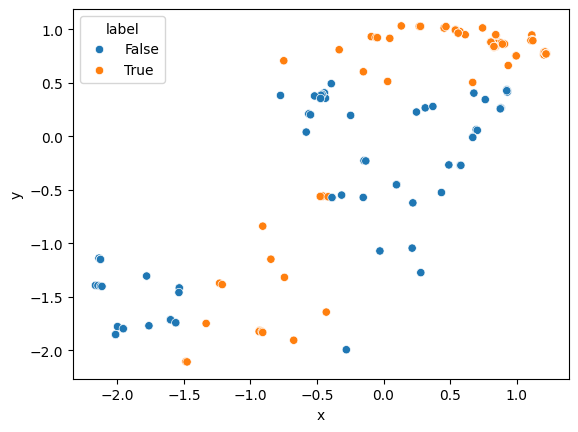

In [20]:
import seaborn as sns
df_po_xy['label'] = ((df_po_xy['x'] > -1.5) & (df_po_xy['x'] < -.4) & (df_po_xy ['y'] < -.4)) | (df_po_xy['y'] > .5)
sns.scatterplot(
    data=df_po_xy,
    x='x',
    y='y',
    hue='label',          
)

In [21]:
xy_grid = []

xy_range = np.arange(-2, 2, 0.05)
for i in xy_range:
    for j in xy_range:
        xy_grid.append([i, j])

df_xy_grid = pd.DataFrame(xy_grid, columns = ['x', 'y'])
xy_grid = torch.tensor(xy_grid, dtype = torch.float32)



In [22]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(128, 64), dropout=0.0):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x): 
        # A MANO CADA CAPA EN VEZ DE SEQUENTIAL
        return self.net(x)

w: [-0.08029461  0.01906991] b: 0.23253434896469116
w: [0.10964972 0.10205132] b: 0.37237173318862915
w: [-0.21991777  0.27568686] b: -0.3855912387371063
w: [0.21687275 0.571917  ] b: -0.17009353637695312
w: [0.18681407 0.6304979 ] b: 0.7049363255500793
w: [-0.29850835  0.16817331] b: -0.38658377528190613
w: [ 0.14568883 -0.2977315 ] b: -0.03487372398376465
w: [ 0.26962703 -0.24298206] b: 0.1402338743209839
w: [0.21323305 0.19353497] b: -0.03594106435775757
w: [ 0.34869534 -0.6762864 ] b: -0.5723731517791748
w: [-0.32612514  0.32831317] b: 0.5391106009483337
w: [0.22927672 0.5308973 ] b: -0.036398112773895264
w: [ 0.10003531 -0.4871685 ] b: -0.21887540817260742
w: [-0.34754947 -0.59883845] b: -0.05314117670059204
w: [0.35634404 0.5564758 ] b: 0.5814111828804016
w: [-0.4931762  0.5277539] b: -0.08624553680419922
w: [0.07593453 0.09662682] b: -0.37417492270469666
w: [-0.23158059 -0.5686541 ] b: 0.6582478880882263
w: [-0.07057995 -0.3745497 ] b: 0.15749794244766235
w: [-0.29275006 -0.5438

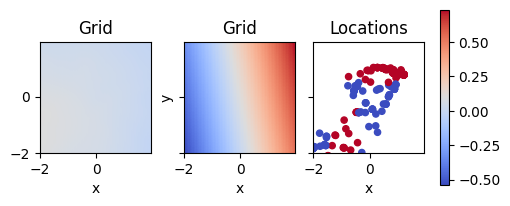

w: [-0.08700383  0.01223874] b: 0.2383708506822586
w: [0.11757491 0.11019444] b: 0.37994569540023804
w: [-0.21196687  0.26772612] b: -0.37761908769607544
w: [0.21848086 0.5746039 ] b: -0.1663566678762436
w: [0.1812531 0.6249752] b: 0.7026846408843994
w: [-0.29340363  0.17279156] b: -0.3908312916755676
w: [ 0.14039515 -0.30201447] b: -0.028480099514126778
w: [ 0.27605286 -0.23645268] b: 0.1464322954416275
w: [0.20725496 0.18934461] b: -0.04087931662797928
w: [ 0.3460513 -0.6779159] b: -0.5698220729827881
w: [-0.33196086  0.32155064] b: 0.5328250527381897
w: [0.23720461 0.5388273 ] b: -0.028786154463887215
w: [ 0.09451227 -0.4894882 ] b: -0.21634502708911896
w: [-0.34183747 -0.5940901 ] b: -0.05532298609614372
w: [0.35903034 0.5646256 ] b: 0.5748977661132812
w: [-0.50056875  0.52067715] b: -0.08441522717475891
w: [0.0680799  0.08874024] b: -0.3662037253379822
w: [-0.22565658 -0.56770086] b: 0.664828360080719
w: [-0.06541711 -0.37300512] b: 0.1506696194410324
w: [-0.29827964 -0.5443569 ] 

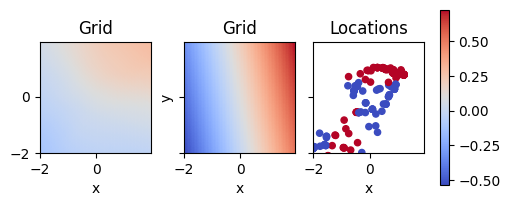

w: [-0.09092176  0.00771323] b: 0.2435019612312317
w: [0.12434269 0.11715011] b: 0.3866324722766876
w: [-0.20415437  0.25987518] b: -0.3697251081466675
w: [0.22869247 0.5862047 ] b: -0.15598130226135254
w: [0.18431701 0.6302696 ] b: 0.7094550132751465
w: [-0.29279295  0.17221099] b: -0.3890713155269623
w: [ 0.14029619 -0.30140805] b: -0.023318607360124588
w: [ 0.2809715  -0.23077266] b: 0.1522565484046936
w: [0.20927958 0.1977402 ] b: -0.03566689416766167
w: [ 0.3428008  -0.68416584] b: -0.5636494159698486
w: [-0.33390296  0.31830287] b: 0.5289921760559082
w: [0.24451429 0.5469482 ] b: -0.023328294977545738
w: [ 0.09162398 -0.4908164 ] b: -0.21457913517951965
w: [-0.33990544 -0.5922885 ] b: -0.04875696450471878
w: [0.36819226 0.5764324 ] b: 0.5718973278999329
w: [-0.5090257   0.51285636] b: -0.07797842472791672
w: [0.06064378 0.08117799] b: -0.35831302404403687
w: [-0.22280914 -0.5738651 ] b: 0.6749307513237
w: [-0.06374901 -0.376664  ] b: 0.14518091082572937
w: [-0.30484474 -0.5409416

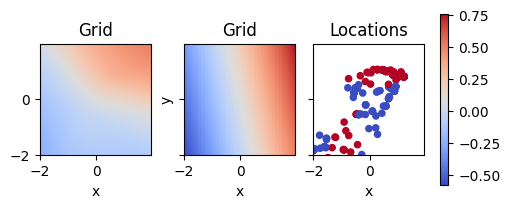

w: [-0.09342496  0.00463727] b: 0.24921327829360962
w: [0.12963443 0.12257507] b: 0.3909378945827484
w: [-0.19648564  0.2521379 ] b: -0.3619116246700287
w: [0.23732954 0.5974722 ] b: -0.1469920426607132
w: [0.19060163 0.6388984 ] b: 0.7156656980514526
w: [-0.29867318  0.16493498] b: -0.38048821687698364
w: [ 0.14469363 -0.29855195] b: -0.017933450639247894
w: [ 0.28341627 -0.22716698] b: 0.15869656205177307
w: [0.21507776 0.20945737] b: -0.028113555163145065
w: [ 0.34165713 -0.6898337 ] b: -0.5581800937652588
w: [-0.33413306  0.31729862] b: 0.5263094305992126
w: [0.25282946 0.55659974] b: -0.019255749881267548
w: [ 0.09077164 -0.4938466 ] b: -0.2099246233701706
w: [-0.33855072 -0.5883248 ] b: -0.044150423258543015
w: [0.37675777 0.5869343 ] b: 0.5679497122764587
w: [-0.5199767  0.5022204] b: -0.06860067695379257
w: [0.05365696 0.07396065] b: -0.35050538182258606
w: [-0.21705084 -0.5791273 ] b: 0.6850475072860718
w: [-0.06659585 -0.3824631 ] b: 0.14146114885807037
w: [-0.31000206 -0.535

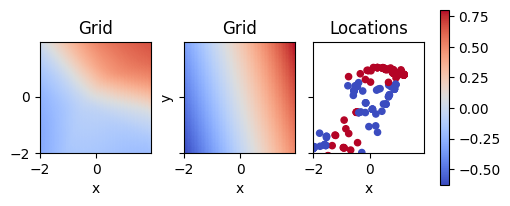

w: [-0.09679095  0.00123958] b: 0.25491422414779663
w: [0.13372605 0.1269479 ] b: 0.39321184158325195
w: [-0.18895996  0.24451324] b: -0.3541775047779083
w: [0.24353123 0.6084837 ] b: -0.13957765698432922
w: [0.19691142 0.6469428 ] b: 0.7201588749885559
w: [-0.30799264  0.1548156 ] b: -0.3697803318500519
w: [ 0.15108925 -0.29499817] b: -0.011712819337844849
w: [ 0.28267822 -0.22609827] b: 0.16414082050323486
w: [0.21887949 0.22112203] b: -0.022720441222190857
w: [ 0.34072572 -0.6960484 ] b: -0.5523676872253418
w: [-0.33459353  0.3182924 ] b: 0.5242176055908203
w: [0.26046166 0.56660146] b: -0.018411237746477127
w: [ 0.08836211 -0.499818  ] b: -0.20259998738765717
w: [-0.33610365 -0.58526987] b: -0.0419730581343174
w: [0.38372424 0.5960074 ] b: 0.5626012682914734
w: [-0.53167456  0.49071276] b: -0.05820950120687485
w: [0.04713005 0.06709379] b: -0.34277963638305664
w: [-0.21110117 -0.5857036 ] b: 0.6939347386360168
w: [-0.07110615 -0.3900783 ] b: 0.13708461821079254
w: [-0.31497025 -0.5

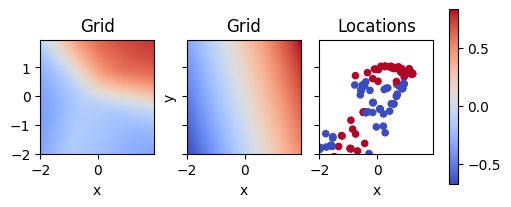

w: [-0.09905463 -0.00201422] b: 0.25992318987846375
w: [0.13699101 0.13066724] b: 0.3945498466491699
w: [-0.18157661  0.2370002 ] b: -0.3465215861797333
w: [0.24812408 0.6191658 ] b: -0.1341962218284607
w: [0.20177901 0.6534979 ] b: 0.724091649055481
w: [-0.32360014  0.1384019 ] b: -0.35382142663002014
w: [ 0.15992126 -0.290585  ] b: -0.003392392536625266
w: [ 0.28046316 -0.22768167] b: 0.16897226870059967
w: [0.22108169 0.23240732] b: -0.019938619807362556
w: [ 0.3385347  -0.70307654] b: -0.5454862713813782
w: [-0.33512342  0.32017037] b: 0.5227388739585876
w: [0.26694247 0.57671374] b: -0.019846180453896523
w: [ 0.08376312 -0.50817734] b: -0.19391971826553345
w: [-0.33565027 -0.5885105 ] b: -0.038021624088287354
w: [0.38897237 0.6044291 ] b: 0.5565682649612427
w: [-0.54326874  0.47940096] b: -0.04829370975494385
w: [0.04107227 0.06058279] b: -0.3351345360279083
w: [-0.20527609 -0.5919582 ] b: 0.7017786502838135
w: [-0.0760676  -0.39799592] b: 0.13258512318134308
w: [-0.3206463 -0.532

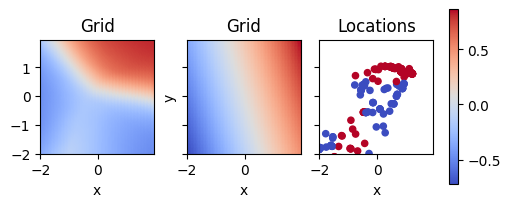

w: [-0.10019366 -0.00529872] b: 0.2642638087272644
w: [0.13969158 0.13371465] b: 0.3955448567867279
w: [-0.17433499  0.22959773] b: -0.3389427363872528
w: [0.25069267 0.6295455 ] b: -0.13056498765945435
w: [0.20509589 0.65885437] b: 0.7274021506309509
w: [-0.34388527  0.11709685] b: -0.3337188959121704
w: [ 0.16912036 -0.28658164] b: 0.005681248847395182
w: [ 0.2781184  -0.23090206] b: 0.17344601452350616
w: [0.22112557 0.24329506] b: -0.0191962867975235
w: [ 0.3349046 -0.7110208] b: -0.5372850894927979
w: [-0.3376925   0.32232666] b: 0.5219939351081848
w: [0.2722582  0.58652073] b: -0.023345474153757095
w: [ 0.07928672 -0.51665455] b: -0.18519894778728485
w: [-0.33591753 -0.59539866] b: -0.03427060693502426
w: [0.39248967 0.6118977 ] b: 0.550748884677887
w: [-0.55650336  0.46596038] b: -0.03667810559272766
w: [0.03549064 0.0544327 ] b: -0.32756900787353516
w: [-0.20053539 -0.5991959 ] b: 0.7084832787513733
w: [-0.08041618 -0.40583307] b: 0.12735751271247864
w: [-0.32725388 -0.5387095 

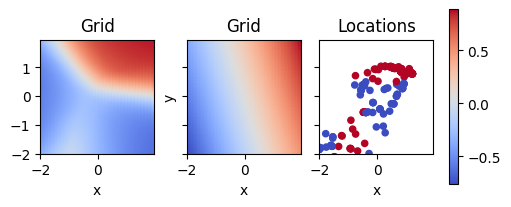

w: [-0.10062181 -0.00892315] b: 0.2680967450141907
w: [0.14221245 0.13655578] b: 0.39680245518684387
w: [-0.16723464  0.22230503] b: -0.3314399719238281
w: [0.2526624 0.6392855] b: -0.12940655648708344
w: [0.20870228 0.66376346] b: 0.7312361598014832
w: [-0.36389497  0.09648764] b: -0.31387093663215637
w: [ 0.1772151 -0.2842501] b: 0.01436509471386671
w: [ 0.27641752 -0.23519932] b: 0.17815160751342773
w: [0.21967682 0.25384045] b: -0.019181590527296066
w: [ 0.33204016 -0.7182361 ] b: -0.5294981598854065
w: [-0.34141284  0.32487962] b: 0.5210321545600891
w: [0.2762947 0.5960666] b: -0.02743879146873951
w: [ 0.07452837 -0.52427113] b: -0.17721498012542725
w: [-0.33684254 -0.60273004] b: -0.029497094452381134
w: [0.39446133 0.61859995] b: 0.5455610156059265
w: [-0.5688369   0.45352846] b: -0.02666648104786873
w: [0.03038923 0.04864795] b: -0.32008206844329834
w: [-0.19755007 -0.6066236 ] b: 0.7138060331344604
w: [-0.08414981 -0.41339254] b: 0.12315801531076431
w: [-0.33277655 -0.5466145 

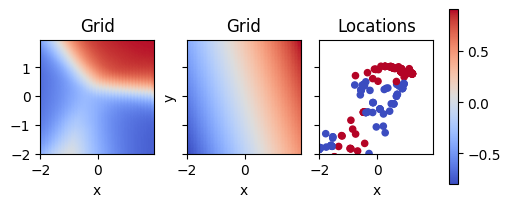

w: [-0.10081623 -0.01246672] b: 0.2715282738208771
w: [0.1448499  0.13923053] b: 0.39799976348876953
w: [-0.1602753   0.21512134] b: -0.32401224970817566
w: [0.2533016  0.64843386] b: -0.1292462795972824
w: [0.21237196 0.6685049 ] b: 0.7340100407600403
w: [-0.37584808  0.08667813] b: -0.3049094080924988
w: [ 0.18401238 -0.2843223 ] b: 0.023007258772850037
w: [ 0.27608156 -0.23987775] b: 0.18323175609111786
w: [0.21723194 0.26386324] b: -0.019034024327993393
w: [ 0.33099806 -0.7242096 ] b: -0.522843062877655
w: [-0.34556794  0.32706597] b: 0.5200576782226562
w: [0.27907023 0.6049466 ] b: -0.03162108734250069
w: [ 0.07072216 -0.53103095] b: -0.16945567727088928
w: [-0.33742455 -0.60987586] b: -0.024573680013418198
w: [0.39563024 0.62452406] b: 0.5410001277923584
w: [-0.5803008   0.44214228] b: -0.01903013326227665
w: [0.02576833 0.04323206] b: -0.3126727342605591
w: [-0.19467987 -0.6128976 ] b: 0.7184945344924927
w: [-0.08732341 -0.42021474] b: 0.12071098387241364
w: [-0.3370628 -0.55450

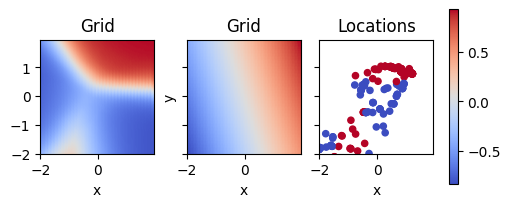

w: [-0.10090221 -0.01589997] b: 0.2747066915035248
w: [0.14752889 0.14147095] b: 0.399096816778183
w: [-0.1534568   0.20804599] b: -0.31665870547294617
w: [0.25338173 0.65715224] b: -0.12974607944488525
w: [0.216131 0.673211] b: 0.7359161972999573
w: [-0.38692224  0.0774894 ] b: -0.29715055227279663
w: [ 0.19114147 -0.28443024] b: 0.032117296010255814
w: [ 0.27705887 -0.2446051 ] b: 0.18818716704845428
w: [0.21347664 0.27377492] b: -0.01769527792930603
w: [ 0.33216834 -0.7280761 ] b: -0.5188981890678406
w: [-0.34976342  0.3284727 ] b: 0.5185092687606812
w: [0.2808948  0.61349535] b: -0.0356115959584713
w: [ 0.06797195 -0.5365761 ] b: -0.16226491332054138
w: [-0.33835068 -0.61639446] b: -0.01961337774991989
w: [0.39695817 0.6302768 ] b: 0.5362815260887146
w: [-0.5898568   0.43327624] b: -0.0176792461425066
w: [0.02162372 0.03818738] b: -0.3053399324417114
w: [-0.19236419 -0.6191068 ] b: 0.7223751544952393
w: [-0.08986286 -0.42610404] b: 0.11940325051546097
w: [-0.3399331  -0.56136584] b

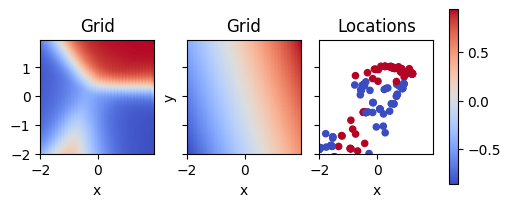

w: [-0.10053273 -0.01915064] b: 0.2770945131778717
w: [0.15018396 0.14363228] b: 0.40032899379730225
w: [-0.14677916  0.20107852] b: -0.30937841534614563
w: [0.25265718 0.66543424] b: -0.13034982979297638
w: [0.22017023 0.6783979 ] b: 0.7370341420173645
w: [-0.39647478  0.06948829] b: -0.2916276156902313
w: [ 0.19800586 -0.28548944] b: 0.04118165746331215
w: [ 0.27866018 -0.2495899 ] b: 0.19329221546649933
w: [0.209784  0.2827798] b: -0.01705252006649971
w: [ 0.3353174  -0.73002404] b: -0.5168907642364502
w: [-0.353373   0.3303258] b: 0.516104519367218
w: [0.28196707 0.6214796 ] b: -0.03948666527867317
w: [ 0.06559813 -0.54119384] b: -0.15511690080165863
w: [-0.3393893 -0.6216723] b: -0.01461814995855093
w: [0.3983543  0.63597775] b: 0.531775951385498
w: [-0.5982374   0.42603996] b: -0.018588989973068237
w: [0.01794604 0.03351471] b: -0.29808309674263
w: [-0.19058767 -0.62523824] b: 0.725415825843811
w: [-0.09172322 -0.43117404] b: 0.1193745955824852
w: [-0.3419444 -0.5669732] b: 0.172

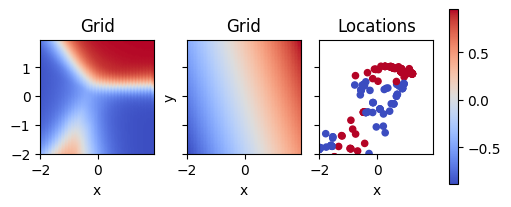

w: [-0.09976494 -0.02239372] b: 0.2791907489299774
w: [0.15277086 0.14579938] b: 0.40150195360183716
w: [-0.14024256  0.19421847] b: -0.30217060446739197
w: [0.25100395 0.67326057] b: -0.1309727132320404
w: [0.22418971 0.6836964 ] b: 0.7378808856010437
w: [-0.40452302  0.06251519] b: -0.2885338366031647
w: [ 0.20446132 -0.2871445 ] b: 0.049659933894872665
w: [ 0.28080246 -0.2545432 ] b: 0.1982274353504181
w: [0.20615013 0.2909738 ] b: -0.01715989224612713
w: [ 0.33889988 -0.7310833 ] b: -0.5155834555625916
w: [-0.35690385  0.33231223] b: 0.5133997201919556
w: [0.28214982 0.628911  ] b: -0.04326486587524414
w: [ 0.06373857 -0.5450769 ] b: -0.14856179058551788
w: [-0.3403174 -0.6260475] b: -0.010147676803171635
w: [0.39943954 0.6414817 ] b: 0.5276172161102295
w: [-0.60551804  0.42013937] b: -0.020930949598550797
w: [0.01472046 0.029213  ] b: -0.2909013330936432
w: [-0.18828984 -0.6306886 ] b: 0.7282205820083618
w: [-0.09292859 -0.43559554] b: 0.1196536123752594
w: [-0.34356418 -0.5716339

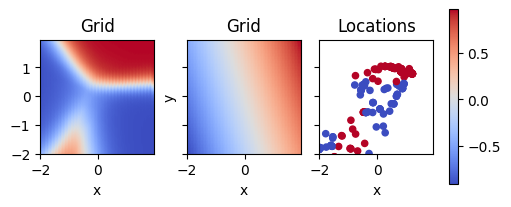

w: [-0.0991168  -0.02554918] b: 0.28093796968460083
w: [0.15514944 0.1476163 ] b: 0.4028279483318329
w: [-0.13384733  0.18746552] b: -0.29503464698791504
w: [0.24959558 0.6805845 ] b: -0.1318710595369339
w: [0.22837476 0.6894164 ] b: 0.7376699447631836
w: [-0.41212258  0.05578418] b: -0.285847932100296
w: [ 0.21068025 -0.28853178] b: 0.05779861658811569
w: [ 0.28332072 -0.2592381 ] b: 0.20333510637283325
w: [0.20354648 0.2984159 ] b: -0.018177151679992676
w: [ 0.34147993 -0.73232776] b: -0.5137521624565125
w: [-0.36036128  0.33393577] b: 0.5111651420593262
w: [0.28226507 0.635922  ] b: -0.04660164192318916
w: [ 0.06240046 -0.5483321 ] b: -0.14230290055274963
w: [-0.34109375 -0.6298698 ] b: -0.0059444960206747055
w: [0.40075588 0.646908  ] b: 0.5235438942909241
w: [-0.6115769  0.4159834] b: -0.024643581360578537
w: [0.01192652 0.02527906] b: -0.2837938964366913
w: [-0.18618548 -0.6358731 ] b: 0.7306870818138123
w: [-0.09353258 -0.43950874] b: 0.12010962516069412
w: [-0.34472576 -0.57570

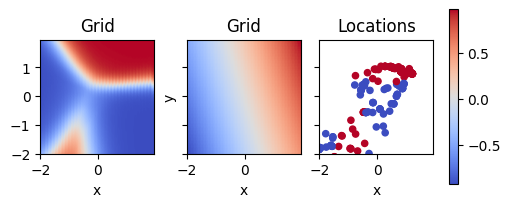

w: [-0.09848795 -0.02838936] b: 0.28242143988609314
w: [0.15746981 0.14902632] b: 0.4039733111858368
w: [-0.12759386  0.1808195 ] b: -0.2879697382450104
w: [0.24840808 0.68731207] b: -0.13292048871517181
w: [0.23268744 0.6951661 ] b: 0.7370472550392151
w: [-0.41739088  0.05220038] b: -0.28690335154533386
w: [ 0.2160544  -0.29066604] b: 0.06504755467176437
w: [ 0.28581643 -0.26370105] b: 0.2081698477268219
w: [0.20176099 0.30504075] b: -0.01973835565149784
w: [ 0.34389657 -0.73310244] b: -0.5122738480567932
w: [-0.36346394  0.3356231 ] b: 0.508975625038147
w: [0.28244466 0.6422873 ] b: -0.049818653613328934
w: [ 0.06099769 -0.55106276] b: -0.13638174533843994
w: [-0.34212685 -0.6330116 ] b: -0.0020418325439095497
w: [0.401732  0.6515085] b: 0.5203979015350342
w: [-0.6156592   0.41485664] b: -0.02975807711482048
w: [0.00953848 0.02170724] b: -0.27676016092300415
w: [-0.18426076 -0.6405027 ] b: 0.7329308986663818
w: [-0.09416433 -0.4428572 ] b: 0.12088025361299515
w: [-0.34604663 -0.57904

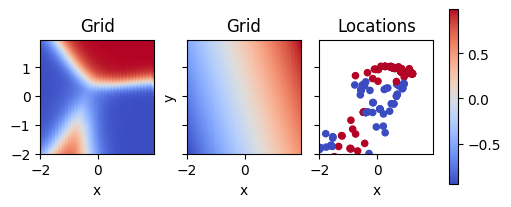

w: [-0.09771896 -0.03124408] b: 0.28338712453842163
w: [0.15950494 0.15018967] b: 0.40525922179222107
w: [-0.12148286  0.17428033] b: -0.280975341796875
w: [0.24692205 0.69386476] b: -0.13340844213962555
w: [0.23693478 0.70075905] b: 0.7360848784446716
w: [-0.4213975   0.05005263] b: -0.2898123860359192
w: [ 0.22007012 -0.29398802] b: 0.07071053236722946
w: [ 0.28837982 -0.26773226] b: 0.2127368152141571
w: [0.20001818 0.31141892] b: -0.02075558342039585
w: [ 0.34645507 -0.733427  ] b: -0.5111444592475891
w: [-0.36650783  0.3369132 ] b: 0.5068326592445374
w: [0.28236064 0.6484184 ] b: -0.05248609930276871
w: [ 0.05973445 -0.553421  ] b: -0.13068746030330658
w: [-0.34323254 -0.63570046] b: 0.0015727460850030184
w: [0.40242895 0.6557787 ] b: 0.5179113745689392
w: [-0.61919194  0.41409647] b: -0.03516145050525665
w: [0.00752587 0.01848926] b: -0.2697995603084564
w: [-0.18227349 -0.64488935] b: 0.7347010970115662
w: [-0.09457717 -0.4458452 ] b: 0.12186773121356964
w: [-0.34727666 -0.581888

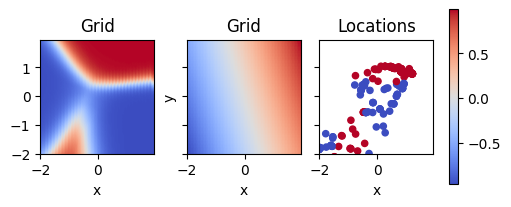

w: [-0.09699646 -0.03375679] b: 0.2844177782535553
w: [0.16140372 0.15099859] b: 0.40635308623313904
w: [-0.11551494  0.16784802] b: -0.27405092120170593
w: [0.24575229 0.6996518 ] b: -0.1344783753156662
w: [0.24107438 0.70626533] b: 0.7349438667297363
w: [-0.42475408  0.0486375 ] b: -0.29319891333580017
w: [ 0.22369741 -0.29725537] b: 0.0759047269821167
w: [ 0.2911882  -0.27139154] b: 0.2168290913105011
w: [0.19836138 0.3172382 ] b: -0.021840982139110565
w: [ 0.34914216 -0.7333263 ] b: -0.5103732347488403
w: [-0.36960053  0.3380298 ] b: 0.5048408508300781
w: [0.28223217 0.65386814] b: -0.05523940920829773
w: [ 0.05862191 -0.55540615] b: -0.1253722459077835
w: [-0.3442617 -0.6378857] b: 0.004760633688420057
w: [0.40292066 0.6595517 ] b: 0.5157102942466736
w: [-0.62249476  0.41361925] b: -0.040133193135261536
w: [0.00585457 0.01561406] b: -0.2629115879535675
w: [-0.18044299 -0.6487848 ] b: 0.7364938855171204
w: [-0.09478796 -0.44841078] b: 0.1228436529636383
w: [-0.34832916 -0.5842453 ]

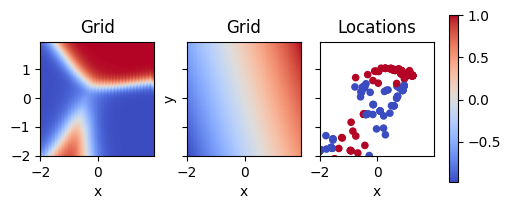

w: [-0.09616396 -0.03625218] b: 0.2851978540420532
w: [0.1633299  0.15174799] b: 0.4071098566055298
w: [-0.10969091  0.16152275] b: -0.2671959400177002
w: [0.2443796  0.70528275] b: -0.13528458774089813
w: [0.24513803 0.71162474] b: 0.733482301235199
w: [-0.42769656  0.04703617] b: -0.29658961296081543
w: [ 0.22715233 -0.30010226] b: 0.08081073313951492
w: [ 0.29393908 -0.27460834] b: 0.22062288224697113
w: [0.1965656  0.32293016] b: -0.0225688386708498
w: [ 0.35182577 -0.73284984] b: -0.5098883509635925
w: [-0.37252665  0.33890483] b: 0.502959132194519
w: [0.28188094 0.6591315 ] b: -0.05771731957793236
w: [ 0.05756822 -0.5569856 ] b: -0.12047022581100464
w: [-0.34529772 -0.6396301 ] b: 0.007671329192817211
w: [0.40313116 0.6630594 ] b: 0.513929545879364
w: [-0.6252013   0.41348454] b: -0.04525204747915268
w: [0.00448792 0.01306781] b: -0.2560957670211792
w: [-0.17858936 -0.6526113 ] b: 0.7379783987998962
w: [-0.09494773 -0.45052433] b: 0.12389391660690308
w: [-0.34941563 -0.58611214] 

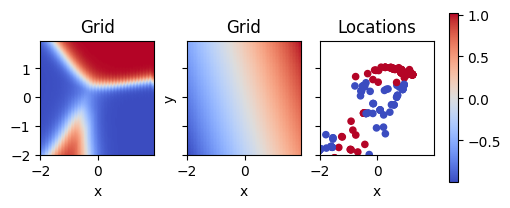

w: [-0.0956199  -0.03854937] b: 0.28606897592544556
w: [0.16533571 0.15247005] b: 0.40770572423934937
w: [-0.10401183  0.15530476] b: -0.2604101002216339
w: [0.243724   0.71042085] b: -0.1364041119813919
w: [0.24875839 0.71646225] b: 0.7327542901039124
w: [-0.4300355   0.04572835] b: -0.3002428710460663
w: [ 0.22988662 -0.30310005] b: 0.08507617563009262
w: [ 0.29631868 -0.27769712] b: 0.2239203006029129
w: [0.1955305  0.32815757] b: -0.023544088006019592
w: [ 0.35429657 -0.73229796] b: -0.5094645619392395
w: [-0.3752813   0.33978942] b: 0.501595675945282
w: [0.28193617 0.6640314 ] b: -0.060075659304857254
w: [ 0.05656553 -0.5582475 ] b: -0.11659982055425644
w: [-0.34638545 -0.6411175 ] b: 0.010140367783606052
w: [0.40349343 0.6662473 ] b: 0.5124751925468445
w: [-0.62748957  0.4137046 ] b: -0.049932029098272324
w: [0.00338815 0.01083401] b: -0.24935179948806763
w: [-0.17721769 -0.656265  ] b: 0.7393812537193298
w: [-0.09510992 -0.45238715] b: 0.12462909519672394
w: [-0.35054353 -0.5876

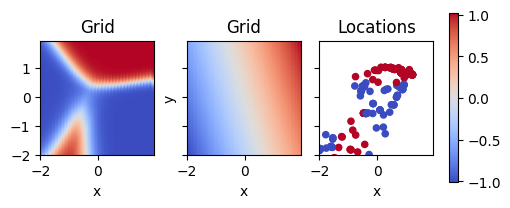

w: [-0.09490021 -0.0406844 ] b: 0.28664374351501465
w: [0.1672286  0.15309846] b: 0.40838998556137085
w: [-0.09847881  0.14919443] b: -0.25369301438331604
w: [0.24346194 0.7150956 ] b: -0.1379804164171219
w: [0.25231507 0.7212226 ] b: 0.7319983839988708
w: [-0.43207994  0.04450864] b: -0.30393415689468384
w: [ 0.2324119  -0.30602914] b: 0.08907473832368851
w: [ 0.29855552 -0.28070426] b: 0.22703079879283905
w: [0.19496061 0.332918  ] b: -0.02491725981235504
w: [ 0.35658544 -0.7317951 ] b: -0.508953869342804
w: [-0.37798482  0.3405626 ] b: 0.50049889087677
w: [0.2816829 0.6688634] b: -0.06172380596399307
w: [ 0.05554733 -0.5594246 ] b: -0.11324585974216461
w: [-0.3475897  -0.64254874] b: 0.012541815638542175
w: [0.403631   0.66925824] b: 0.5115174651145935
w: [-0.6293186   0.41424006] b: -0.05488896742463112
w: [0.00251769 0.00889371] b: -0.24267935752868652
w: [-0.17578915 -0.65982884] b: 0.7403977513313293
w: [-0.09537888 -0.4542166 ] b: 0.12546107172966003
w: [-0.3517911 -0.5892152] 

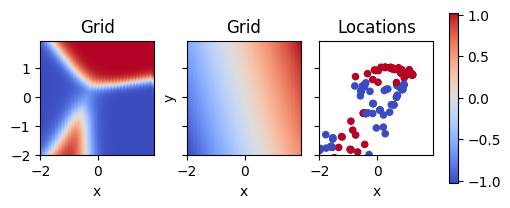

w: [-0.09427133 -0.04265573] b: 0.28741058707237244
w: [0.1690731  0.15362154] b: 0.40905869007110596
w: [-0.09309307  0.14319228] b: -0.2470444291830063
w: [0.24320342 0.71942896] b: -0.13967829942703247
w: [0.25570875 0.725804  ] b: 0.7314109802246094
w: [-0.4340046   0.04321789] b: -0.3073652684688568
w: [ 0.23494019 -0.30856982] b: 0.09270284324884415
w: [ 0.30093348 -0.2833281 ] b: 0.22955778241157532
w: [0.19438346 0.33736977] b: -0.026359347626566887
w: [ 0.3587471 -0.7312601] b: -0.5084874033927917
w: [-0.38081428  0.3410616 ] b: 0.4998544454574585
w: [0.28134054 0.67335415] b: -0.06337949633598328
w: [ 0.05473408 -0.5603305 ] b: -0.11024123430252075
w: [-0.34861732 -0.643691  ] b: 0.0146438367664814
w: [0.40371078 0.6719298 ] b: 0.5106680393218994
w: [-0.63160145  0.41415763] b: -0.05799560993909836
w: [0.00184041 0.00722591] b: -0.23607826232910156
w: [-0.17446502 -0.663132  ] b: 0.7414531111717224
w: [-0.09548439 -0.45575637] b: 0.1261371672153473
w: [-0.35278207 -0.5904719 

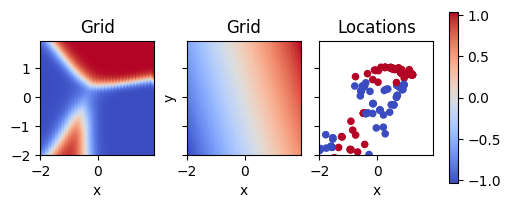

w: [-0.09363327 -0.04455253] b: 0.2880295217037201
w: [0.17078061 0.15403521] b: 0.4097030460834503
w: [-0.08785594  0.13729891] b: -0.24046416580677032
w: [0.24290977 0.7236835 ] b: -0.14108532667160034
w: [0.25898913 0.7301201 ] b: 0.730906069278717
w: [-0.4355866  0.0419224] b: -0.3107512593269348
w: [ 0.23718636 -0.3109719 ] b: 0.09601512551307678
w: [ 0.30310532 -0.28575933] b: 0.2317681908607483
w: [0.19404161 0.34161162] b: -0.02781817317008972
w: [ 0.36078164 -0.73069334] b: -0.5080428123474121
w: [-0.38345292  0.34143034] b: 0.4993914067745209
w: [0.2809837 0.6777424] b: -0.06477095931768417
w: [ 0.05393735 -0.5611363 ] b: -0.10750024020671844
w: [-0.3496316 -0.6447148] b: 0.016490405425429344
w: [0.40371028 0.67446804] b: 0.5101621150970459
w: [-0.6337654   0.41386303] b: -0.060390084981918335
w: [0.00132265 0.00580796] b: -0.2295483648777008
w: [-0.1732562  -0.66638106] b: 0.742353618144989
w: [-0.09560448 -0.4571307 ] b: 0.1267041712999344
w: [-0.3538076  -0.59159344] b: 0.

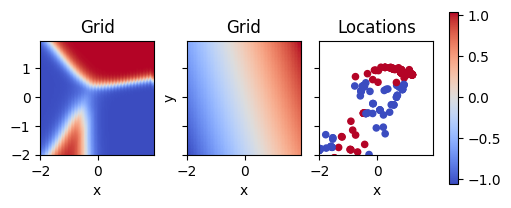

w: [-0.0930328  -0.04642348] b: 0.28866663575172424
w: [0.17230615 0.15437378] b: 0.410517156124115
w: [-0.08276885  0.13151504] b: -0.23395214974880219
w: [0.24246462 0.7278079 ] b: -0.1422552764415741
w: [0.2619137 0.7339807] b: 0.730929970741272
w: [-0.4369713   0.04059462] b: -0.31419646739959717
w: [ 0.2392985  -0.31305054] b: 0.09920137375593185
w: [ 0.3052099 -0.2879203] b: 0.2337833046913147
w: [0.19356588 0.34574768] b: -0.029007019475102425
w: [ 0.36281618 -0.7301168 ] b: -0.5075938701629639
w: [-0.38604307  0.34162778] b: 0.4990721344947815
w: [0.28049287 0.6819885 ] b: -0.06592680513858795
w: [ 0.05327536 -0.5618223 ] b: -0.10504911839962006
w: [-0.35045484 -0.6456205 ] b: 0.017960842698812485
w: [0.4034942  0.67686284] b: 0.510039746761322
w: [-0.63571626  0.41361278] b: -0.06281234323978424
w: [0.00093395 0.00461618] b: -0.2230895459651947
w: [-0.17208819 -0.6696148 ] b: 0.7431710362434387
w: [-0.09554687 -0.45835984] b: 0.12697060406208038
w: [-0.3546557  -0.59260964] b:

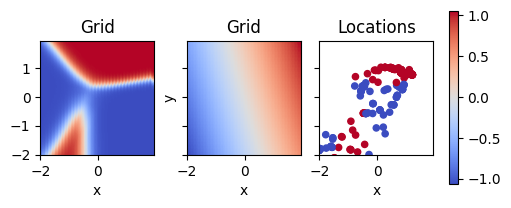

w: [-0.09246273 -0.04808465] b: 0.28923365473747253
w: [0.17371136 0.154424  ] b: 0.4112294912338257
w: [-0.07783329  0.1258415 ] b: -0.2275082916021347
w: [0.24220204 0.73172444] b: -0.14333876967430115
w: [0.2647428 0.7376065] b: 0.7309820652008057
w: [-0.4379004   0.03960601] b: -0.31777143478393555
w: [ 0.2410347  -0.31514922] b: 0.1021132618188858
w: [ 0.3068953 -0.2900568] b: 0.23565804958343506
w: [0.19326517 0.3496991 ] b: -0.030084755271673203
w: [ 0.3639443  -0.73016244] b: -0.5064539313316345
w: [-0.3884076   0.34185916] b: 0.4990294575691223
w: [0.2801831 0.6860091] b: -0.06699962913990021
w: [ 0.05239638 -0.56262183] b: -0.10263700783252716
w: [-0.35152608 -0.6466032 ] b: 0.019453566521406174
w: [0.4032913  0.67906386] b: 0.5100924372673035
w: [-0.6373861   0.41351572] b: -0.06506365537643433
w: [0.00064755 0.00362636] b: -0.21670186519622803
w: [-0.17103936 -0.6725608 ] b: 0.7438509464263916
w: [-0.09578421 -0.45968223] b: 0.12738534808158875
w: [-0.35573655 -0.59366554] 

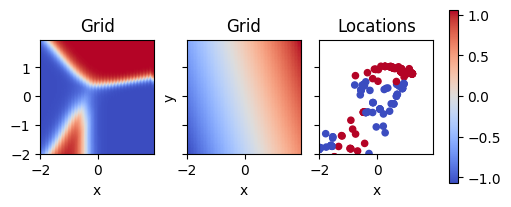

w: [-0.09188479 -0.04981585] b: 0.28975382447242737
w: [0.1748539  0.15431124] b: 0.4120866358280182
w: [-0.07305078  0.12027925] b: -0.2211325466632843
w: [0.24168731 0.7356285 ] b: -0.14419437944889069
w: [0.26755422 0.74116874] b: 0.7309450507164001
w: [-0.43887058  0.03829728] b: -0.32132095098495483
w: [ 0.24287535 -0.31688684] b: 0.10493765026330948
w: [ 0.30873752 -0.29188654] b: 0.23740708827972412
w: [0.1926982  0.35365242] b: -0.030914606526494026
w: [ 0.36524555 -0.73000747] b: -0.5055201649665833
w: [-0.390841    0.34187946] b: 0.49906861782073975
w: [0.27962303 0.6900032 ] b: -0.0678567886352539
w: [ 0.05176488 -0.56321263] b: -0.10037611424922943
w: [-0.3523322  -0.64738953] b: 0.020786141976714134
w: [0.40287575 0.6812109 ] b: 0.5104250311851501
w: [-0.63918287  0.413085  ] b: -0.06714688986539841
w: [0.00044055 0.00281441] b: -0.21038539707660675
w: [-0.16995838 -0.67556876] b: 0.7444389462471008
w: [-0.09574196 -0.46078596] b: 0.12766596674919128
w: [-0.356525  -0.5945

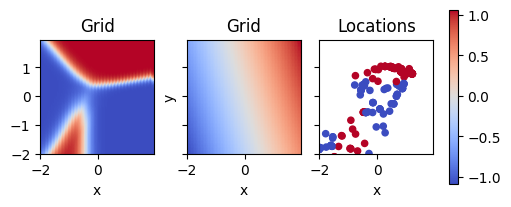

w: [-0.0912919  -0.05142267] b: 0.2903972268104553
w: [0.17600189 0.1543144 ] b: 0.41294151544570923
w: [-0.06842291  0.11482938] b: -0.21482513844966888
w: [0.24112111 0.73927534] b: -0.145049050450325
w: [0.2699488 0.7442898] b: 0.7313783764839172
w: [-0.43962902  0.03712125] b: -0.32491645216941833
w: [ 0.24461417 -0.3185191 ] b: 0.10762166976928711
w: [ 0.31049627 -0.29354793] b: 0.23909050226211548
w: [0.19208558 0.35733333] b: -0.031768955290317535
w: [ 0.3663682 -0.7299857] b: -0.5044757127761841
w: [-0.3932761   0.34169745] b: 0.49928146600723267
w: [0.27902636 0.6937217 ] b: -0.06870940327644348
w: [ 0.05114355 -0.5637631 ] b: -0.09837263077497482
w: [-0.3531126 -0.6480976] b: 0.02184598334133625
w: [0.4023112 0.6831255] b: 0.5108258128166199
w: [-0.6408816  0.412691 ] b: -0.06907374411821365
w: [0.00029389 0.00215687] b: -0.2041403204202652
w: [-0.1688843 -0.678319 ] b: 0.7451146841049194
w: [-0.09570426 -0.46181867] b: 0.12774845957756042
w: [-0.35728517 -0.59536844] b: 0.18

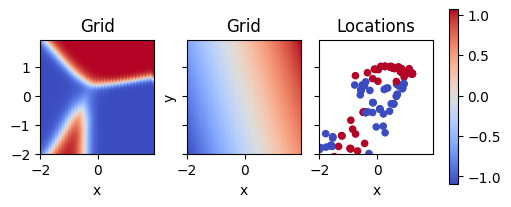

w: [-0.09086183 -0.05272939] b: 0.2910497188568115
w: [0.1771437  0.15434435] b: 0.41365543007850647
w: [-0.06395128  0.10949306] b: -0.20858615636825562
w: [0.24083282 0.74256885] b: -0.146006777882576
w: [0.2724135 0.7474926] b: 0.7316784858703613
w: [-0.44033867  0.03601287] b: -0.32841169834136963
w: [ 0.24617755 -0.32005078] b: 0.11022423952817917
w: [ 0.31206945 -0.29517576] b: 0.24083739519119263
w: [0.19174796 0.36067614] b: -0.03271268308162689
w: [ 0.3674764  -0.72997886] b: -0.5034152269363403
w: [-0.39556473  0.3414662 ] b: 0.49954313039779663
w: [0.27870297 0.6970685 ] b: -0.06966602802276611
w: [ 0.05046115 -0.56441313] b: -0.09626121073961258
w: [-0.35394692 -0.6489142 ] b: 0.023015258833765984
w: [0.40187076 0.6847896 ] b: 0.5112346410751343
w: [-0.64244926  0.41253182] b: -0.07106795161962509
w: [0.0001921  0.00163142] b: -0.19796685874462128
w: [-0.16804571 -0.6807064 ] b: 0.7457983493804932
w: [-0.09573197 -0.46295178] b: 0.12799571454524994
w: [-0.35805488 -0.596303

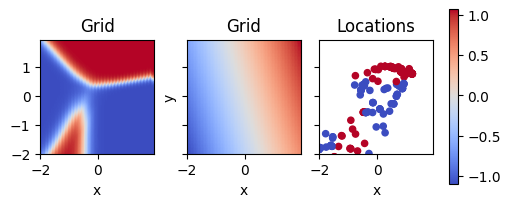

w: [-0.09047966 -0.05403635] b: 0.2916347086429596
w: [0.17821704 0.1543216 ] b: 0.41438570618629456
w: [-0.05963749  0.10427158] b: -0.20241589844226837
w: [0.24056645 0.7457419 ] b: -0.1468120813369751
w: [0.27473772 0.75051796] b: 0.7321292161941528
w: [-0.44108966  0.03478149] b: -0.33171677589416504
w: [ 0.24768968 -0.32140684] b: 0.11257647722959518
w: [ 0.3136399  -0.29658103] b: 0.24240900576114655
w: [0.19144312 0.36389956] b: -0.03350235894322395
w: [ 0.36863676 -0.72988224] b: -0.5024309754371643
w: [-0.39783466  0.3410773 ] b: 0.49998852610588074
w: [0.27840245 0.70028514] b: -0.0704752653837204
w: [ 0.04991902 -0.56492645] b: -0.09432736784219742
w: [-0.35465145 -0.64960515] b: 0.02404223196208477
w: [0.4013444  0.68632907] b: 0.5118758678436279
w: [-0.64400685  0.41232005] b: -0.07291508466005325
w: [0.00012293 0.00121729] b: -0.19186538457870483
w: [-0.16728012 -0.6830511 ] b: 0.7463808059692383
w: [-0.09563283 -0.46392655] b: 0.1281275600194931
w: [-0.35866952 -0.597119

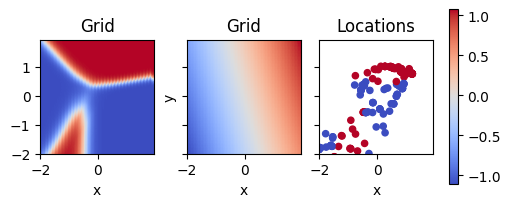

w: [-0.09001902 -0.0554585 ] b: 0.29215162992477417
w: [0.1792563  0.15438886] b: 0.4151206910610199
w: [-0.05548309  0.09916632] b: -0.19631469249725342
w: [0.24007978 0.7489809 ] b: -0.14736852049827576
w: [0.2769853 0.7532004] b: 0.732718288898468
w: [-0.44172543  0.03342783] b: -0.3350507616996765
w: [ 0.24919006 -0.32255167] b: 0.11475826054811478
w: [ 0.3152047  -0.29771116] b: 0.24385914206504822
w: [0.19090389 0.36719608] b: -0.034036438912153244
w: [ 0.36980712 -0.729706  ] b: -0.5015158653259277
w: [-0.40012926  0.34059048] b: 0.5004546642303467
w: [0.2778869  0.70356345] b: -0.07104562968015671
w: [ 0.04949278 -0.56527746] b: -0.09259071946144104
w: [-0.35523552 -0.6501097 ] b: 0.024876810610294342
w: [0.40060973 0.6878327 ] b: 0.5127445459365845
w: [-0.645334   0.4120876] b: -0.07498177886009216
w: [7.694541e-05 8.955194e-04] b: -0.18583625555038452
w: [-0.16641776 -0.68548787] b: 0.7468572854995728
w: [-0.09544605 -0.46470416] b: 0.12813343107700348
w: [-0.35915494 -0.5977

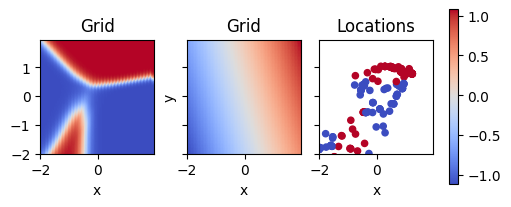

w: [-0.08954509 -0.05679172] b: 0.2927689254283905
w: [0.18030876 0.1543842 ] b: 0.4158931374549866
w: [-0.05148956  0.09417877] b: -0.190282940864563
w: [0.23960596 0.75211406] b: -0.1479056179523468
w: [0.27882522 0.7553641 ] b: 0.7337038516998291
w: [-0.44221434  0.03218241] b: -0.3381795585155487
w: [ 0.25044307 -0.3238578 ] b: 0.11673292517662048
w: [ 0.31647626 -0.29899794] b: 0.24516336619853973
w: [0.19039682 0.37038428] b: -0.034552134573459625
w: [ 0.37058342 -0.72987705] b: -0.5003259778022766
w: [-0.40234712  0.34001997] b: 0.5010505318641663
w: [0.27738756 0.706725  ] b: -0.07160289585590363
w: [ 0.04892544 -0.5657627 ] b: -0.09100882709026337
w: [-0.35595214 -0.6507219 ] b: 0.0255962535738945
w: [0.39986575 0.6892383 ] b: 0.513699471950531
w: [-0.6467683   0.41172114] b: -0.07598982006311417
w: [4.7070775e-05 6.4918224e-04] b: -0.17987999320030212
w: [-0.16558431 -0.68779266] b: 0.7473339438438416
w: [-0.09544126 -0.4656028 ] b: 0.12807615101337433
w: [-0.35975507 -0.5985

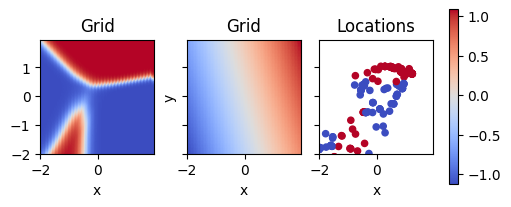

w: [-0.08915178 -0.05800791] b: 0.29330140352249146
w: [0.18130709 0.15439273] b: 0.41662126779556274
w: [-0.04765828  0.08931046] b: -0.18432117998600006
w: [0.23925889 0.7551221 ] b: -0.14843231439590454
w: [0.28093117 0.75769454] b: 0.7343353629112244
w: [-0.44296488  0.03059112] b: -0.34102457761764526
w: [ 0.25160363 -0.3250668 ] b: 0.1187804639339447
w: [ 0.31769302 -0.30017442] b: 0.24668747186660767
w: [0.1900162  0.37345555] b: -0.03505074605345726
w: [ 0.37155536 -0.72984976] b: -0.49928227066993713
w: [-0.4044055  0.3394659] b: 0.5015317797660828
w: [0.27701616 0.70975393] b: -0.07215294241905212
w: [ 0.04840659 -0.56621903] b: -0.08932876586914062
w: [-0.35661277 -0.6513047 ] b: 0.026404039934277534
w: [0.39917237 0.69053197] b: 0.5147320032119751
w: [-0.6482203   0.41131845] b: -0.07710667699575424
w: [2.8114684e-05 4.6346342e-04] b: -0.1739971935749054
w: [-0.16490354 -0.68999296] b: 0.7477928996086121
w: [-0.09539025 -0.46644935] b: 0.12815436720848083
w: [-0.36028877 -0

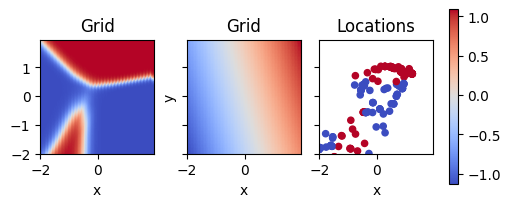

w: [-0.08861507 -0.05930668] b: 0.2938571274280548
w: [0.18235894 0.154461  ] b: 0.4173588156700134
w: [-0.04399046  0.08456305] b: -0.17842990159988403
w: [0.23867399 0.7581677 ] b: -0.14883552491664886
w: [0.2824313 0.7592466] b: 0.73565274477005
w: [-0.44339722  0.02919928] b: -0.34413886070251465
w: [ 0.25270504 -0.3262379 ] b: 0.12065435200929642
w: [ 0.31885985 -0.30127013] b: 0.248015359044075
w: [0.18941033 0.3765562 ] b: -0.03543214127421379
w: [ 0.37237316 -0.7299821 ] b: -0.49811625480651855
w: [-0.40653476  0.33874035] b: 0.5021485090255737
w: [0.2764112  0.71281767] b: -0.07257963716983795
w: [ 0.04792181 -0.5666497 ] b: -0.0879477933049202
w: [-0.3572089 -0.6518365] b: 0.026908274739980698
w: [0.39828733 0.6917951 ] b: 0.5159066915512085
w: [-0.64944595  0.41105556] b: -0.07813175022602081
w: [1.6379025e-05 3.2565231e-04] b: -0.16818849742412567
w: [-0.16406667 -0.6922464 ] b: 0.7482260465621948
w: [-0.09530296 -0.46725672] b: 0.1279565691947937
w: [-0.36076182 -0.5999585

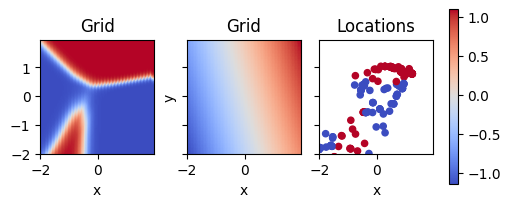

w: [-0.08839042 -0.06054464] b: 0.2945733368396759
w: [0.18341163 0.15439382] b: 0.4181188941001892
w: [-0.04048715  0.07993827] b: -0.17260980606079102
w: [0.23846498 0.76091856] b: -0.14937762916088104
w: [0.28391597 0.7606782 ] b: 0.7370280027389526
w: [-0.44393197  0.027789  ] b: -0.34703439474105835
w: [ 0.25375256 -0.32726565] b: 0.12229137867689133
w: [ 0.32003254 -0.30214137] b: 0.24920867383480072
w: [0.18918768 0.37936303] b: -0.035952236503362656
w: [ 0.37329698 -0.72993577] b: -0.49711403250694275
w: [-0.40849796  0.3378969 ] b: 0.5027559399604797
w: [0.27618292 0.7155791 ] b: -0.07314172387123108
w: [ 0.04757283 -0.5668932 ] b: -0.0867128074169159
w: [-0.3576899 -0.6521936] b: 0.027306770905852318
w: [0.3976238  0.69282264] b: 0.5170987844467163
w: [-0.6507782   0.41078305] b: -0.0787605494260788
w: [9.2971459e-06 2.2506197e-04] b: -0.16245464980602264
w: [-0.16360334 -0.69432956] b: 0.7487999796867371
w: [-0.09511381 -0.46785557] b: 0.1276855170726776
w: [-0.36117277 -0.6

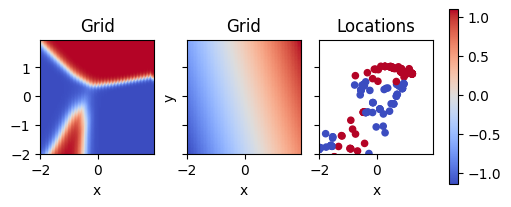

w: [-0.08799133 -0.06163554] b: 0.29514947533607483
w: [0.18452089 0.15443239] b: 0.41879037022590637
w: [-0.03714916  0.07543789] b: -0.1668616533279419
w: [0.2380954 0.7635798] b: -0.14989179372787476
w: [0.28546837 0.7620127 ] b: 0.7382115125656128
w: [-0.4444349   0.02638475] b: -0.349872350692749
w: [ 0.2548101 -0.328149 ] b: 0.12395389378070831
w: [ 0.32116342 -0.30293182] b: 0.25050291419029236
w: [0.18880826 0.3820766 ] b: -0.0364498533308506
w: [ 0.3741088  -0.73001486] b: -0.4960017502307892
w: [-0.41043758  0.33695033] b: 0.5032474398612976
w: [0.27579525 0.71825   ] b: -0.07367250323295593
w: [ 0.04721228 -0.567245  ] b: -0.0854339599609375
w: [-0.35818323 -0.65267533] b: 0.02777186967432499
w: [0.3967956  0.69375056] b: 0.5183257460594177
w: [-0.6520176  0.4105319] b: -0.07939887046813965
w: [5.1359839e-06 1.5288459e-04] b: -0.15679651498794556
w: [-0.16297689 -0.6962567 ] b: 0.7492873668670654
w: [-0.09498292 -0.46855998] b: 0.12756498157978058
w: [-0.36157542 -0.6010513 

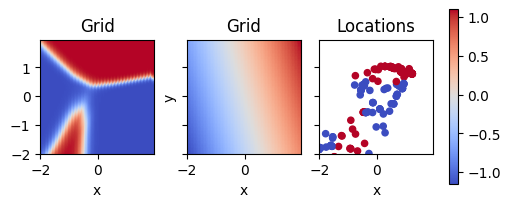

w: [-0.08761932 -0.06280783] b: 0.2955957353115082
w: [0.18545373 0.15440258] b: 0.41956955194473267
w: [-0.03397702  0.07106375] b: -0.16118624806404114
w: [0.23772268 0.76635194] b: -0.1500842124223709
w: [0.28678247 0.763148  ] b: 0.7396436333656311
w: [-0.44509485  0.02540413] b: -0.3522581458091736
w: [ 0.25564846 -0.32910272] b: 0.12550774216651917
w: [ 0.32210025 -0.3037992 ] b: 0.2517282962799072
w: [0.18841746 0.38491777] b: -0.036605846136808395
w: [ 0.37487593 -0.7301259 ] b: -0.4948781430721283
w: [-0.41225085  0.3361947 ] b: 0.5039238333702087
w: [0.27540314 0.7210318 ] b: -0.07388389110565186
w: [ 0.04679492 -0.56763154] b: -0.08420607447624207
w: [-0.3587237  -0.65318257] b: 0.028201943263411522
w: [0.39591163 0.69476736] b: 0.5198631286621094
w: [-0.6531258  0.4102932] b: -0.08000707626342773
w: [2.75794559e-06 1.02006554e-04] b: -0.15121497213840485
w: [-0.16236265 -0.69829345] b: 0.7495216131210327
w: [-0.09495901 -0.46926817] b: 0.12748458981513977
w: [-0.3619198 -0.

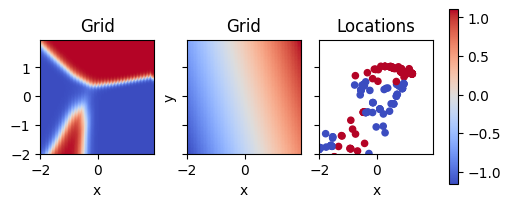

w: [-0.0872217  -0.06391436] b: 0.296060174703598
w: [0.18656622 0.15461649] b: 0.4201621413230896
w: [-0.03097096  0.06681768] b: -0.15558449923992157
w: [0.23728798 0.7690157 ] b: -0.15033218264579773
w: [0.28806037 0.7641026 ] b: 0.7410112619400024
w: [-0.44658318  0.02495673] b: -0.353319376707077
w: [ 0.2566174 -0.329879 ] b: 0.12690164148807526
w: [ 0.323164   -0.30447668] b: 0.2528296113014221
w: [0.1879667  0.38764966] b: -0.03681862726807594
w: [ 0.37573025 -0.7301572 ] b: -0.49386441707611084
w: [-0.41411224  0.33521643] b: 0.5046259760856628
w: [0.27495342 0.7237014 ] b: -0.07415077090263367
w: [ 0.04648714 -0.5679439 ] b: -0.08307851105928421
w: [-0.35916242 -0.65362424] b: 0.028565119951963425
w: [0.39497843 0.69570565] b: 0.5213361978530884
w: [-0.6542394   0.41002464] b: -0.08065309375524521
w: [1.4377362e-06 6.6798486e-05] b: -0.1457110494375229
w: [-0.16172864 -0.7002282 ] b: 0.7498105764389038
w: [-0.09486839 -0.46987882] b: 0.12740372121334076
w: [-0.36218926 -0.6023

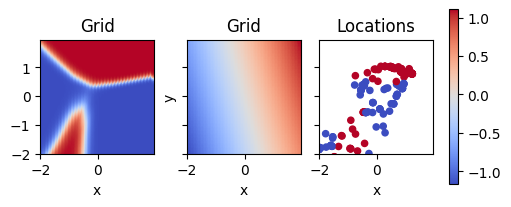

w: [-0.08669965 -0.06501493] b: 0.2966006398200989
w: [0.18756874 0.15447165] b: 0.42092254757881165
w: [-0.02813079  0.06270159] b: -0.15005740523338318
w: [0.23673175 0.77156   ] b: -0.15065349638462067
w: [0.2891323 0.7647464] b: 0.742491602897644
w: [-0.44784793  0.02469215] b: -0.35454922914505005
w: [ 0.2574549  -0.33074155] b: 0.12842945754528046
w: [ 0.32405508 -0.30523947] b: 0.25405609607696533
w: [0.18739735 0.39026085] b: -0.037103071808815
w: [ 0.37641397 -0.7302747 ] b: -0.49274876713752747
w: [-0.41597465  0.33424476] b: 0.5051983594894409
w: [0.27438337 0.7262496 ] b: -0.07448884099721909
w: [ 0.04608808 -0.56823385] b: -0.08203589171171188
w: [-0.35966775 -0.65398365] b: 0.028828401118516922
w: [0.3938964 0.6965035] b: 0.5228331685066223
w: [-0.6552116  0.4098351] b: -0.08122624456882477
w: [7.2663028e-07 4.2897682e-05] b: -0.14028586447238922
w: [-0.16099393 -0.70213467] b: 0.7502037882804871
w: [-0.09486987 -0.47042245] b: 0.12726229429244995
w: [-0.36249816 -0.60287

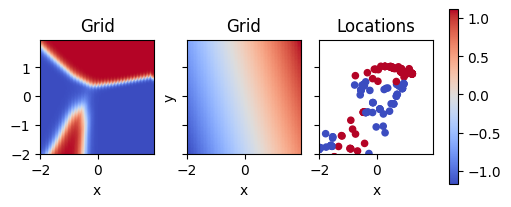

w: [-0.08624832 -0.06604204] b: 0.29711881279945374
w: [0.18854932 0.15447465] b: 0.4215835630893707
w: [-0.02545595  0.05871732] b: -0.14460600912570953
w: [0.23625597 0.77401   ] b: -0.15097676217556
w: [0.2903071  0.76547605] b: 0.7438142895698547
w: [-0.44905892  0.02441983] b: -0.35585808753967285
w: [ 0.25820032 -0.33156583] b: 0.12982764840126038
w: [ 0.3248701  -0.30595818] b: 0.25535500049591064
w: [0.18690784 0.3927786 ] b: -0.03738905489444733
w: [ 0.37720436 -0.7302962 ] b: -0.49175724387168884
w: [-0.41762936  0.33332843] b: 0.5056936144828796
w: [0.2739004 0.7286957] b: -0.07484567910432816
w: [ 0.04566352 -0.56858605] b: -0.08089412748813629
w: [-0.3602044 -0.6544294] b: 0.02920966036617756
w: [0.39283782 0.69723374] b: 0.5243496298789978
w: [-0.6561392   0.40964866] b: -0.08181910961866379
w: [3.5551787e-07 2.6993886e-05] b: -0.13494062423706055
w: [-0.16031963 -0.70389754] b: 0.750537097454071
w: [-0.09492374 -0.4710444 ] b: 0.12728351354599
w: [-0.36278307 -0.6034815 

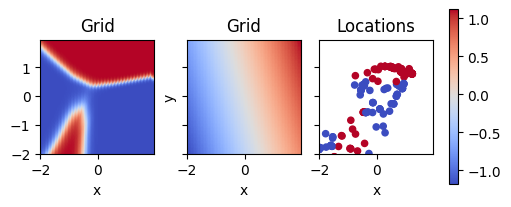

w: [-0.08594088 -0.06693929] b: 0.2977067828178406
w: [0.18978174 0.15450698] b: 0.422063946723938
w: [-0.02294539  0.05486673] b: -0.13923151791095734
w: [0.2360275  0.77616245] b: -0.15150661766529083
w: [0.2913908 0.765983 ] b: 0.7451850771903992
w: [-0.45043832  0.02395596] b: -0.35701224207878113
w: [ 0.25909197 -0.33213967] b: 0.13114407658576965
w: [ 0.32587358 -0.3064196 ] b: 0.2565004825592041
w: [0.18668538 0.39497778] b: -0.037901874631643295
w: [ 0.3781196  -0.73019195] b: -0.4908493161201477
w: [-0.41934863  0.3319948 ] b: 0.5062881708145142
w: [0.27367276 0.73083055] b: -0.07542833685874939
w: [ 0.0454164 -0.5687896] b: -0.07989326119422913
w: [-0.36057252 -0.65475255] b: 0.029478786513209343
w: [0.39195436 0.6976761 ] b: 0.5257247090339661
w: [-0.6571807   0.40946203] b: -0.08245833218097687
w: [1.6813418e-07 1.6629398e-05] b: -0.12967653572559357
w: [-0.15989318 -0.70545685] b: 0.7510718107223511
w: [-0.09478813 -0.47150508] b: 0.1271725296974182
w: [-0.36306575 -0.6039

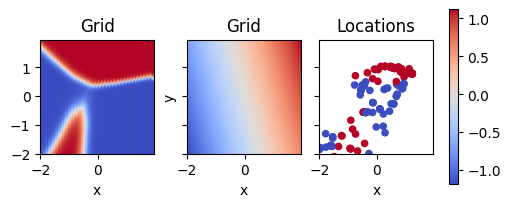

w: [-0.08576863 -0.06776598] b: 0.2981753945350647
w: [0.1908992 0.1544951] b: 0.4225478768348694
w: [-0.02059755  0.05115158] b: -0.13393519818782806
w: [0.23604424 0.77827704] b: -0.15186353027820587
w: [0.29250386 0.766537  ] b: 0.7464684247970581
w: [-0.45162916  0.02365209] b: -0.3582322895526886
w: [ 0.2597218  -0.33289003] b: 0.13236470520496368
w: [ 0.32662764 -0.30705282] b: 0.25770077109336853
w: [0.18671319 0.3971424 ] b: -0.038240671157836914
w: [ 0.37886864 -0.73023957] b: -0.48983946442604065
w: [-0.4207621  0.3308991] b: 0.5069218873977661
w: [0.27368137 0.73293215] b: -0.07581350207328796
w: [ 0.04503413 -0.5691291 ] b: -0.07884122431278229
w: [-0.36106795 -0.6551795 ] b: 0.029811041429638863
w: [0.39123452 0.698118  ] b: 0.527267336845398
w: [-0.6580884   0.40943766] b: -0.08313000947237015
w: [7.6734040e-08 1.0019866e-05] b: -0.1244950219988823
w: [-0.15959631 -0.706924  ] b: 0.7514139413833618
w: [-0.09482919 -0.4720875 ] b: 0.12719368934631348
w: [-0.3633981 -0.6044

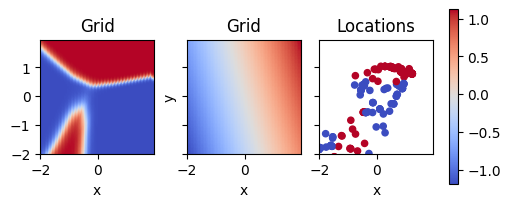

w: [-0.0855246  -0.06869565] b: 0.29874497652053833
w: [0.19190869 0.15442708] b: 0.4231657087802887
w: [-0.01841036  0.04757359] b: -0.12871834635734558
w: [0.23585847 0.7803927 ] b: -0.15221384167671204
w: [0.2932111 0.766605 ] b: 0.7480493187904358
w: [-0.45275941  0.02336703] b: -0.3595186471939087
w: [ 0.2603918  -0.33354503] b: 0.13351361453533173
w: [ 0.32744104 -0.3075357 ] b: 0.2588215172290802
w: [0.18653558 0.39930603] b: -0.038575947284698486
w: [ 0.3796412  -0.73024493] b: -0.4888438284397125
w: [-0.42220438  0.3298412 ] b: 0.5073893070220947
w: [0.27351344 0.7350182 ] b: -0.07625856250524521
w: [ 0.04475801 -0.56933546] b: -0.07802947610616684
w: [-0.36144885 -0.655478  ] b: 0.02993869036436081
w: [0.39031473 0.6984604 ] b: 0.5288112163543701
w: [-0.6590659   0.40922838] b: -0.0834892988204956
w: [3.373663e-08 5.899208e-06] b: -0.11939754337072372
w: [-0.15913443 -0.70840853] b: 0.7518512606620789
w: [-0.09476908 -0.4725333 ] b: 0.12702809274196625
w: [-0.363565  -0.60492

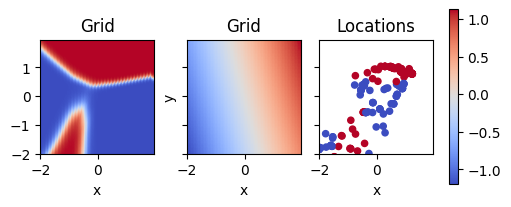

w: [-0.08506476 -0.06963058] b: 0.29906484484672546
w: [0.19310205 0.15452522] b: 0.4235730767250061
w: [-0.01638113  0.04413437] b: -0.1235823780298233
w: [0.23548812 0.7826448 ] b: -0.1523246169090271
w: [0.29387605 0.76647645] b: 0.7495821118354797
w: [-0.4536804  0.0232817] b: -0.3610343635082245
w: [ 0.26098537 -0.3342361 ] b: 0.13457107543945312
w: [ 0.3281535  -0.30808565] b: 0.2599256634712219
w: [0.18618028 0.401601  ] b: -0.03867663815617561
w: [ 0.38023078 -0.73044825] b: -0.48765549063682556
w: [-0.42372295  0.32871813] b: 0.5080656409263611
w: [0.27318403 0.73722255] b: -0.07652612775564194
w: [ 0.04436785 -0.56968534] b: -0.07715427130460739
w: [-0.36198184 -0.6559335 ] b: 0.030194351449608803
w: [0.3892948  0.69889915] b: 0.5304619073867798
w: [-0.65988946  0.40906915] b: -0.08393993973731995
w: [1.4262346e-08 3.3901615e-06] b: -0.11438559740781784
w: [-0.15847553 -0.7099193 ] b: 0.7520208954811096
w: [-0.09489019 -0.47309774] b: 0.12704911828041077
w: [-0.3638292 -0.605

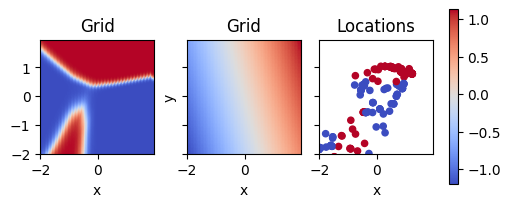

w: [-0.08471178 -0.07054413] b: 0.29952335357666016
w: [0.19421713 0.15448706] b: 0.42407068610191345
w: [-0.01450661  0.04083538] b: -0.11852885782718658
w: [0.23515265 0.7846877 ] b: -0.15258760750293732
w: [0.29465622 0.7664725 ] b: 0.7508822083473206
w: [-0.45480245  0.02296394] b: -0.36234813928604126
w: [ 0.2617169  -0.33480987] b: 0.13573136925697327
w: [ 0.3290103 -0.3084681] b: 0.2610839605331421
w: [0.18584755 0.4036963 ] b: -0.03892052173614502
w: [ 0.38101414 -0.73040855] b: -0.48670682311058044
w: [-0.42510298  0.327722  ] b: 0.5084278583526611
w: [0.2729262 0.7391878] b: -0.07704030722379684
w: [ 0.04415569 -0.56981784] b: -0.07637695968151093
w: [-0.3623079  -0.65614533] b: 0.03033442795276642
w: [0.38826138 0.6992288 ] b: 0.5319746732711792
w: [-0.66073054  0.40892485] b: -0.08464276045560837
w: [5.7862231e-09 1.8996096e-06] b: -0.10946083813905716
w: [-0.15793848 -0.7113794 ] b: 0.7523927092552185
w: [-0.09483833 -0.47340468] b: 0.12700791656970978
w: [-0.36392975 -0.6

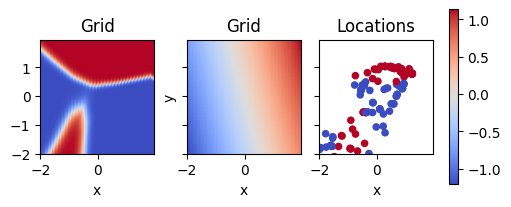

w: [-0.08451747 -0.07141907] b: 0.29997408390045166
w: [0.19535984 0.15438175] b: 0.4245016574859619
w: [-0.01278292  0.0376779 ] b: -0.11355932801961899
w: [0.23513806 0.7866166 ] b: -0.15284916758537292
w: [0.2952786 0.7663363] b: 0.7523584961891174
w: [-0.45569086  0.02286849] b: -0.36381086707115173
w: [ 0.26222727 -0.33552966] b: 0.136663019657135
w: [ 0.3296749 -0.3089727] b: 0.26211610436439514
w: [0.18585566 0.40566573] b: -0.03917449340224266
w: [ 0.3816235  -0.73050934] b: -0.4856494665145874
w: [-0.42635107  0.32673335] b: 0.5090286731719971
w: [0.272946  0.7410726] b: -0.0774344652891159
w: [ 0.04382627 -0.570023  ] b: -0.07561644166707993
w: [-0.36275545 -0.656408  ] b: 0.030487898737192154
w: [0.3874724 0.6994684] b: 0.5335544943809509
w: [-0.6615969   0.40883908] b: -0.0849446952342987
w: [2.2479887e-09 1.0366244e-06] b: -0.10462497919797897
w: [-0.1575956 -0.7127462] b: 0.7526916265487671
w: [-0.09492563 -0.47377756] b: 0.1269942820072174
w: [-0.36416167 -0.6063106 ] b:

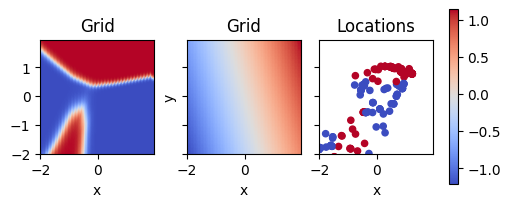

w: [-0.08413921 -0.0721892 ] b: 0.3003700375556946
w: [0.19662967 0.15448567] b: 0.42487502098083496
w: [-0.0112056  0.0346631] b: -0.10867549479007721
w: [0.23491508 0.78851444] b: -0.15309572219848633
w: [0.29588038 0.7661209 ] b: 0.7537922263145447
w: [-0.45646125  0.02282677] b: -0.36537691950798035
w: [ 0.26277354 -0.33614513] b: 0.1376689225435257
w: [ 0.33028427 -0.30944592] b: 0.26326984167099
w: [0.18563476 0.40762016] b: -0.03939894959330559
w: [ 0.38219094 -0.73064125] b: -0.48454222083091736
w: [-0.4277765  0.3256174] b: 0.5096434950828552
w: [0.27275532 0.74293184] b: -0.07780513167381287
w: [ 0.04339939 -0.5703244 ] b: -0.07476865500211716
w: [-0.3633212  -0.65677875] b: 0.030746610835194588
w: [0.3864712 0.6996508] b: 0.5351486206054688
w: [-0.66231185  0.40877068] b: -0.0854451060295105
w: [8.344539e-10 5.502485e-07] b: -0.09987980127334595
w: [-0.1569836 -0.7139848] b: 0.752956211566925
w: [-0.09514298 -0.474254  ] b: 0.1271113157272339
w: [-0.3644469 -0.6068279] b: 0.

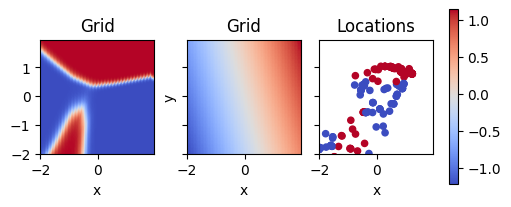

w: [-0.08390972 -0.07286452] b: 0.3008589446544647
w: [0.1979183 0.1546203] b: 0.42520883679389954
w: [-0.00976958  0.03179162] b: -0.10387910902500153
w: [0.23487228 0.79020184] b: -0.15352530777454376
w: [0.29655677 0.7659969 ] b: 0.7550789713859558
w: [-0.4575141   0.02250933] b: -0.36664652824401855
w: [ 0.26349732 -0.33654496] b: 0.13855664432048798
w: [ 0.33111495 -0.3096725 ] b: 0.26432907581329346
w: [0.18560457 0.4093559 ] b: -0.03981340676546097
w: [ 0.382921  -0.7306249] b: -0.48357075452804565
w: [-0.42911783  0.3243513 ] b: 0.5101749300956726
w: [0.2727337 0.7445919] b: -0.0783168226480484
w: [ 0.0431825 -0.5704795] b: -0.07401831448078156
w: [-0.36369395 -0.65704155] b: 0.03094647452235222
w: [0.38557544 0.69961286] b: 0.5366212129592896
w: [-0.66327125  0.40855017] b: -0.08575846999883652
w: [2.9523045e-10 2.8373418e-07] b: -0.09522716701030731
w: [-0.15657754 -0.7150858 ] b: 0.7533621788024902
w: [-0.09514505 -0.47458416] b: 0.12715278565883636
w: [-0.36461294 -0.607207

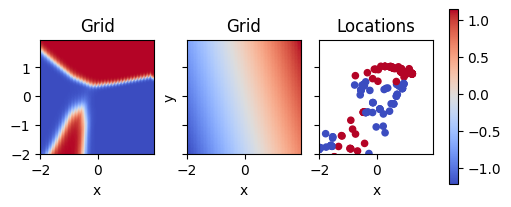

w: [-0.08359843 -0.07371292] b: 0.30127963423728943
w: [0.19913924 0.15459555] b: 0.4256930351257324
w: [-0.00846923  0.02906413] b: -0.09917200356721878
w: [0.23471956 0.7920298 ] b: -0.15371648967266083
w: [0.29685175 0.765349  ] b: 0.7567737102508545
w: [-0.45823866  0.02247252] b: -0.3682238459587097
w: [ 0.2639486  -0.33716083] b: 0.1395319253206253
w: [ 0.3316918 -0.3100629] b: 0.2654586732387543
w: [0.18547855 0.41122022] b: -0.04000141844153404
w: [ 0.38352802 -0.73070645] b: -0.48253801465034485
w: [-0.43032297  0.32330188] b: 0.510595977306366
w: [0.2725906 0.7464029] b: -0.07856060564517975
w: [ 0.04287336 -0.5706513 ] b: -0.0734010860323906
w: [-0.36410183 -0.65725356] b: 0.03098137676715851
w: [0.38460585 0.69963706] b: 0.5382694005966187
w: [-0.6639324   0.40851846] b: -0.08633743226528168
w: [9.929625e-11 1.419326e-07] b: -0.09066919982433319
w: [-0.1561085 -0.7163808] b: 0.7536410093307495
w: [-0.09523701 -0.47490025] b: 0.12707464396953583
w: [-0.36476296 -0.60755724] 

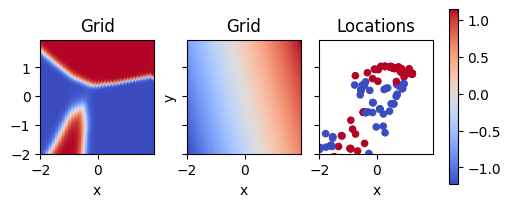

w: [-0.08351365 -0.07446098] b: 0.3016732931137085
w: [0.2003389 0.1547074] b: 0.42609265446662903
w: [-0.00729839  0.0264808 ] b: -0.09455610811710358
w: [0.23486225 0.7937695 ] b: -0.15392446517944336
w: [0.29736108 0.7648969 ] b: 0.7582095861434937
w: [-0.4591531   0.02225092] b: -0.3695926070213318
w: [ 0.26447174 -0.33764428] b: 0.14024768769741058
w: [ 0.332386  -0.3103051] b: 0.26649290323257446
w: [0.18564251 0.41300675] b: -0.04019448533654213
w: [ 0.38422483 -0.73071873] b: -0.48156097531318665
w: [-0.43131846  0.32222536] b: 0.5110704898834229
w: [0.27275598 0.7481136 ] b: -0.07885550707578659
w: [ 0.04264968 -0.57080996] b: -0.07273674756288528
w: [-0.36444983 -0.65749127] b: 0.03109307959675789
w: [0.3838915 0.6996729] b: 0.5399086475372314
w: [-0.6648265   0.40830994] b: -0.0866340771317482
w: [3.165843e-11 6.877599e-08] b: -0.08620751649141312
w: [-0.15590775 -0.7175436 ] b: 0.7538829445838928
w: [-0.09525001 -0.47520617] b: 0.12706071138381958
w: [-0.36489806 -0.6078895

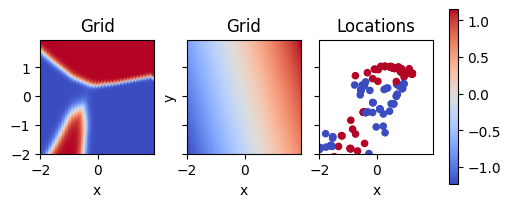

w: [-0.08321027 -0.07495628] b: 0.3021138906478882
w: [0.20178743 0.1550525 ] b: 0.4263683259487152
w: [-0.0062504   0.02404149] b: -0.09003337472677231
w: [0.23483413 0.79529095] b: -0.15434539318084717
w: [0.29800722 0.7645573 ] b: 0.7594258785247803
w: [-0.45992196  0.02217251] b: -0.3710508644580841
w: [ 0.26495025 -0.33818248] b: 0.14125773310661316
w: [ 0.33293703 -0.3106966 ] b: 0.2678249180316925
w: [0.18563205 0.41457137] b: -0.04060562700033188
w: [ 0.38473684 -0.73092216] b: -0.48039382696151733
w: [-0.43250802  0.3209099 ] b: 0.511428713798523
w: [0.27274388 0.7496106 ] b: -0.07934357970952988
w: [ 0.04225263 -0.57115823] b: -0.07192575186491013
w: [-0.36497754 -0.6579144 ] b: 0.03135110065340996
w: [0.38298187 0.699488  ] b: 0.5414215326309204
w: [-0.66554695  0.40829146] b: -0.08710714429616928
w: [9.539036e-12 3.223319e-08] b: -0.08184441179037094
w: [-0.15549985 -0.7184436 ] b: 0.7542467713356018
w: [-0.09546637 -0.4757138 ] b: 0.1272367388010025
w: [-0.3651999 -0.60839

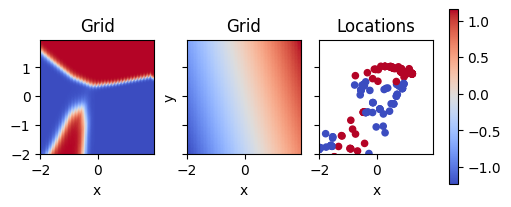

w: [-0.08309274 -0.07573161] b: 0.3026449680328369
w: [0.2029091  0.15501957] b: 0.42690470814704895
w: [-0.00531822  0.02174565] b: -0.08560584485530853
w: [0.23489477 0.79689765] b: -0.15463756024837494
w: [0.29821664 0.76378536] b: 0.7610316276550293
w: [-0.46069947  0.02203239] b: -0.37250053882598877
w: [ 0.26543507 -0.33865952] b: 0.14204084873199463
w: [ 0.33360302 -0.3109161 ] b: 0.2687787413597107
w: [0.18571015 0.41622773] b: -0.040880944579839706
w: [ 0.3853301  -0.73095846] b: -0.47934475541114807
w: [-0.43349138  0.3198836 ] b: 0.5117435455322266
w: [0.27279702 0.7512112 ] b: -0.0796419158577919
w: [ 0.04206737 -0.57118887] b: -0.07145939022302628
w: [-0.36527163 -0.657987  ] b: 0.031301796436309814
w: [0.38216612 0.69937783] b: 0.543049693107605
w: [-0.66624933  0.40822703] b: -0.08764711022377014
w: [2.7073122e-12 1.4587034e-08] b: -0.0775819718837738
w: [-0.15527055 -0.7196166 ] b: 0.7546178698539734
w: [-0.09546451 -0.47586948] b: 0.12709659337997437
w: [-0.36526257 -0

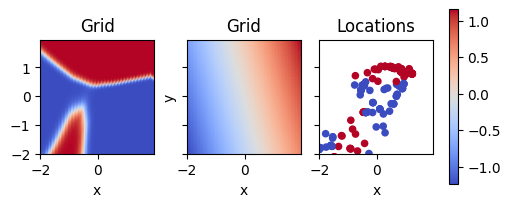

w: [-0.08282603 -0.07631948] b: 0.30307385325431824
w: [0.20427163 0.1552224 ] b: 0.42722654342651367
w: [-0.00449446  0.01959229] b: -0.08127565681934357
w: [0.23490019 0.7983944 ] b: -0.15495996177196503
w: [0.29850906 0.7630925 ] b: 0.7624632120132446
w: [-0.46129873  0.02208479] b: -0.3740800619125366
w: [ 0.26584527 -0.33920175] b: 0.14287886023521423
w: [ 0.334127   -0.31129444] b: 0.26985594630241394
w: [0.18574454 0.41776013] b: -0.041200414299964905
w: [ 0.3857495  -0.73120016] b: -0.4781353771686554
w: [-0.43460158  0.31867522] b: 0.5121456980705261
w: [0.27279824 0.75269645] b: -0.07998025417327881
w: [ 0.04170008 -0.5714548 ] b: -0.07081273198127747
w: [-0.36575794 -0.65830326] b: 0.03144824877381325
w: [0.3812733  0.69910735] b: 0.5446694493293762
w: [-0.6668543   0.40828958] b: -0.08817287534475327
w: [7.2114781e-13 6.3630976e-09] b: -0.073422372341156
w: [-0.1549143  -0.72056305] b: 0.7549040913581848
w: [-0.09566028 -0.47626618] b: 0.12716399133205414
w: [-0.36552516 -0

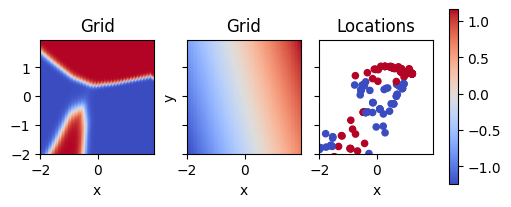

w: [-0.08268639 -0.07692302] b: 0.30347785353660583
w: [0.20553546 0.1554239 ] b: 0.4275178611278534
w: [-0.00377149  0.01757995] b: -0.07704494893550873
w: [0.23501888 0.7999143 ] b: -0.1552411913871765
w: [0.29896447 0.7625324 ] b: 0.7636845111846924
w: [-0.46210462  0.02190217] b: -0.37545186281204224
w: [ 0.2663274  -0.33960238] b: 0.14364027976989746
w: [ 0.33476257 -0.3114935 ] b: 0.2709404230117798
w: [0.18587965 0.41933057] b: -0.041462771594524384
w: [ 0.38638052 -0.73122776] b: -0.4771271049976349
w: [-0.43542358  0.31810063] b: 0.5123125314712524
w: [0.2729235  0.75419784] b: -0.08030319958925247
w: [ 0.04147508 -0.5715967 ] b: -0.07020099461078644
w: [-0.3661158 -0.6585169] b: 0.03157820925116539
w: [0.38049138 0.69890594] b: 0.5462642312049866
w: [-0.6676416   0.40812114] b: -0.08855272084474564
w: [1.7957706e-13 2.6705385e-09] b: -0.06936780363321304
w: [-0.15471293 -0.72154945] b: 0.7551831603050232
w: [-0.09573132 -0.47654113] b: 0.12723450362682343
w: [-0.3656658 -0.60

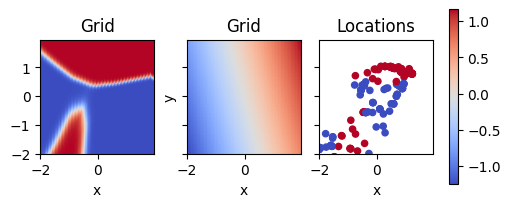

w: [-0.08250169 -0.07760757] b: 0.3038738965988159
w: [0.20673104 0.15547422] b: 0.42790237069129944
w: [-0.00314151  0.01570667] b: -0.07291591912508011
w: [0.23511414 0.80144024] b: -0.15542444586753845
w: [0.29919177 0.761753  ] b: 0.7651150822639465
w: [-0.46266037  0.02195925] b: -0.3769468069076538
w: [ 0.26662898 -0.34016782] b: 0.14439253509044647
w: [ 0.3352261  -0.31184384] b: 0.2719452381134033
w: [0.18600267 0.42089626] b: -0.04163758456707001
w: [ 0.38678652 -0.7314323 ] b: -0.47598695755004883
w: [-0.43615925  0.31812602] b: 0.5123381018638611
w: [0.2730114 0.7557173] b: -0.08049052953720093
w: [ 0.04114385 -0.5717657 ] b: -0.06969816237688065
w: [-0.36655223 -0.6587041 ] b: 0.0316043458878994
w: [0.3777895 0.6958043] b: 0.5510349869728088
w: [-0.6681983   0.40817586] b: -0.08907219767570496
w: [4.1623497e-14 1.0762056e-09] b: -0.0654204711318016
w: [-0.15446243 -0.72260433] b: 0.7553846836090088
w: [-0.09590421 -0.47682   ] b: 0.12720945477485657
w: [-0.3658459 -0.609548

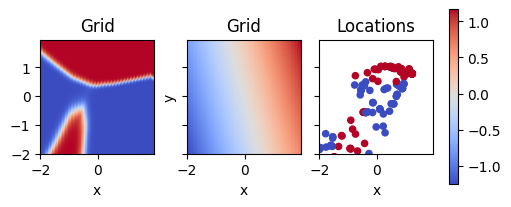

w: [-0.08226728 -0.0781239 ] b: 0.3043058216571808
w: [0.20805459 0.15569675] b: 0.4282190501689911
w: [-0.00259665  0.01396999] b: -0.06889080256223679
w: [0.23517162 0.8028069 ] b: -0.15575352311134338
w: [0.29953036 0.7609967 ] b: 0.7663993239402771
w: [-0.4633216  0.0219149] b: -0.37835460901260376
w: [ 0.26710832 -0.34055087] b: 0.14514775574207306
w: [ 0.33579937 -0.3120705 ] b: 0.27297523617744446
w: [0.1860773  0.42230937] b: -0.04194972664117813
w: [ 0.38723826 -0.73163277] b: -0.47482478618621826
w: [-0.43697596  0.31805512] b: 0.5122849345207214
w: [0.27306065 0.7570788 ] b: -0.08082089573144913
w: [ 0.04086048 -0.57196134] b: -0.06915060430765152
w: [-0.36697817 -0.65895647] b: 0.03170774132013321
w: [0.37492856 0.69222087] b: 0.555931031703949
w: [-0.66884696  0.40813872] b: -0.08956258744001389
w: [8.9374478e-15 4.1556164e-10] b: -0.06158260628581047
w: [-0.15417066 -0.7234465 ] b: 0.7556874752044678
w: [-0.09605375 -0.47713318] b: 0.12726131081581116
w: [-0.36608416 -0.6

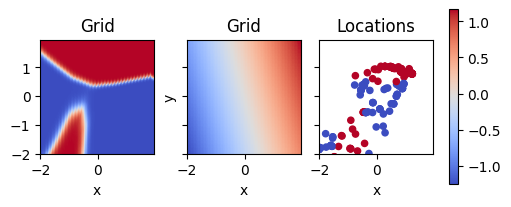

w: [-0.08213346 -0.07870295] b: 0.3046746551990509
w: [0.20929718 0.15581284] b: 0.42851826548576355
w: [-0.00212909  0.01236691] b: -0.06497184187173843
w: [0.2353778  0.80417204] b: -0.1560051143169403
w: [0.29993346 0.7604034 ] b: 0.7675759792327881
w: [-0.4639255   0.02190598] b: -0.3798447251319885
w: [ 0.26745248 -0.3410371 ] b: 0.14595165848731995
w: [ 0.33627436 -0.31236067] b: 0.27412617206573486
w: [0.18630052 0.42372572] b: -0.04218222573399544
w: [ 0.3876969  -0.73175853] b: -0.4737005829811096
w: [-0.4376197  0.3182944] b: 0.5122469067573547
w: [0.2732561 0.7584409] b: -0.08107171952724457
w: [ 0.04053398 -0.57211196] b: -0.06855211406946182
w: [-0.36743507 -0.6591284 ] b: 0.03184635564684868
w: [0.37317437 0.69000936] b: 0.5594429969787598
w: [-0.6694645   0.40814245] b: -0.09010342508554459
w: [1.7683707e-15 1.5340273e-10] b: -0.057856425642967224
w: [-0.15399179 -0.724377  ] b: 0.7558791637420654
w: [-0.09624839 -0.4773888 ] b: 0.12736977636814117
w: [-0.36630532 -0.610

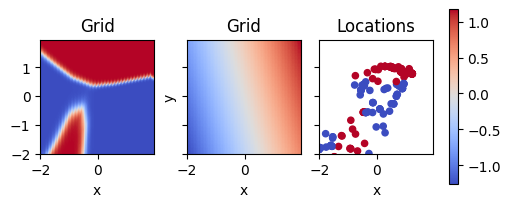

w: [-0.0818788  -0.07928691] b: 0.3051716685295105
w: [0.21061513 0.15603484] b: 0.4288989007472992
w: [-0.00173113  0.01089391] b: -0.06116127595305443
w: [0.23534729 0.8055365 ] b: -0.15632213652133942
w: [0.3000739  0.75940037] b: 0.7690305113792419
w: [-0.46460804  0.02180689] b: -0.38121622800827026
w: [ 0.2679706  -0.34132168] b: 0.14667938649654388
w: [ 0.33690533 -0.3124718 ] b: 0.27506259083747864
w: [0.1862858  0.42513853] b: -0.042480118572711945
w: [ 0.3881727  -0.73192704] b: -0.47254979610443115
w: [-0.4383832   0.31827524] b: 0.5121219158172607
w: [0.2732168  0.75980043] b: -0.08138923346996307
w: [ 0.04034225 -0.5722069 ] b: -0.06815551221370697
w: [-0.3677652 -0.6592797] b: 0.03181767091155052
w: [0.3714968 0.6879371] b: 0.5625662803649902
w: [-0.67011356  0.4080415 ] b: -0.09060100466012955
w: [3.2051076e-16 5.4004547e-11] b: -0.05424412339925766
w: [-0.1536634 -0.7252745] b: 0.7562180757522583
w: [-0.09631719 -0.4775959 ] b: 0.12730851769447327
w: [-0.36641362 -0.610

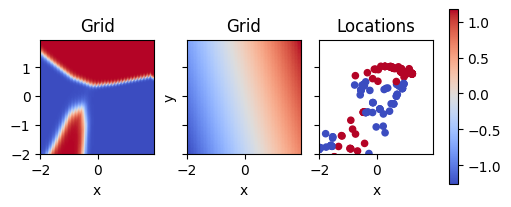

w: [-0.08171371 -0.07989538] b: 0.30548882484436035
w: [0.21190043 0.15620662] b: 0.42917048931121826
w: [-0.00139529  0.00954697] b: -0.057461343705654144
w: [0.235514   0.80695015] b: -0.15647028386592865
w: [0.3004333  0.75863636] b: 0.770240306854248
w: [-0.4652263   0.02176768] b: -0.38260966539382935
w: [ 0.26831204 -0.34175184] b: 0.14741940796375275
w: [ 0.3373914  -0.31270283] b: 0.2761400640010834
w: [0.18647324 0.42660144] b: -0.042609672993421555
w: [ 0.38860726 -0.7320974 ] b: -0.4714054763317108
w: [-0.43894428  0.31838563] b: 0.5121014714241028
w: [0.27337417 0.76121014] b: -0.08153770864009857
w: [ 0.04005568 -0.5723526 ] b: -0.06764400750398636
w: [-0.3681775  -0.65944934] b: 0.031884077936410904
w: [0.37164807 0.6878822 ] b: 0.5637264847755432
w: [-0.67071813  0.40800315] b: -0.09113126993179321
w: [5.2858826e-17 1.8083833e-11] b: -0.0507478304207325
w: [-0.15347712 -0.7262323 ] b: 0.7563490271568298
w: [-0.09648605 -0.4778406 ] b: 0.12736950814723969
w: [-0.3665782 -

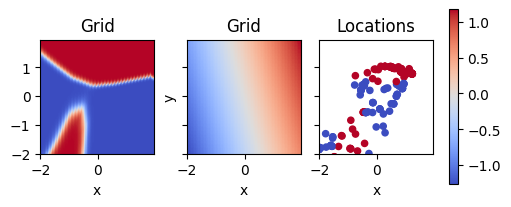

w: [-0.08153374 -0.08042651] b: 0.30586084723472595
w: [0.21327427 0.15646102] b: 0.42938321828842163
w: [-0.00111438  0.00832153] b: -0.05387426167726517
w: [0.23569022 0.8082298 ] b: -0.15675601363182068
w: [0.30072215 0.75778484] b: 0.7714968919754028
w: [-0.46589643  0.02165605] b: -0.38396161794662476
w: [ 0.26877043 -0.3420341 ] b: 0.14806799590587616
w: [ 0.33797905 -0.3128062 ] b: 0.2770894169807434
w: [0.18667683 0.42792225] b: -0.042883485555648804
w: [ 0.38912496 -0.7321984 ] b: -0.4703146517276764
w: [-0.43957904  0.318403  ] b: 0.5121074914932251
w: [0.2735423 0.7624846] b: -0.08182366192340851
w: [ 0.0398336 -0.572458 ] b: -0.06717661768198013
w: [-0.36855653 -0.6596177 ] b: 0.03195442259311676
w: [0.37204617 0.6879566 ] b: 0.5645177960395813
w: [-0.67137593  0.40792122] b: -0.09160712361335754
w: [7.8720769e-18 5.7436543e-12] b: -0.04736962541937828
w: [-0.15330364 -0.7270677 ] b: 0.7565810680389404
w: [-0.09660407 -0.47805402] b: 0.12741729617118835
w: [-0.36677685 -0.6

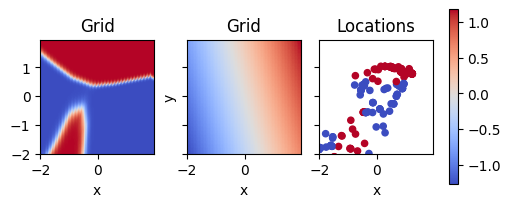

w: [-0.08147734 -0.08104181] b: 0.30635908246040344
w: [0.21429972 0.15649395] b: 0.4298853278160095
w: [-0.00088159  0.00721257] b: -0.0504022054374218
w: [0.2359071 0.8095128] b: -0.15699179470539093
w: [0.30079544 0.7567516 ] b: 0.7729277014732361
w: [-0.46641892  0.02167674] b: -0.38539451360702515
w: [ 0.26901707 -0.34251255] b: 0.14890716969966888
w: [ 0.33842584 -0.3130916 ] b: 0.2780778110027313
w: [0.18690804 0.4292608 ] b: -0.04309334605932236
w: [ 0.38963512 -0.7323126 ] b: -0.46923816204071045
w: [-0.4399645  0.3184146] b: 0.5119339823722839
w: [0.27374992 0.76376367] b: -0.08205893635749817
w: [ 0.03959484 -0.5725443 ] b: -0.06684433668851852
w: [-0.3688745 -0.6596964] b: 0.031834471970796585
w: [0.37231645 0.6878336 ] b: 0.5655572414398193
w: [-0.67189234  0.40795696] b: -0.09217404574155807
w: [1.0494053e-18 1.7250433e-12] b: -0.04411150515079498
w: [-0.15322408 -0.7280024 ] b: 0.7568747997283936
w: [-0.09671731 -0.47822046] b: 0.12731830775737762
w: [-0.36685866 -0.6108

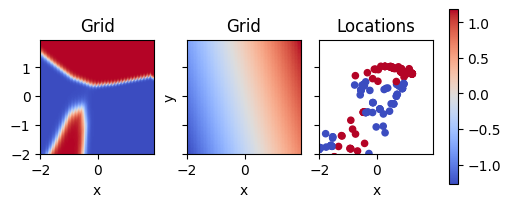

w: [-0.08120851 -0.08153807] b: 0.3066752254962921
w: [0.21570931 0.15679272] b: 0.43003809452056885
w: [-0.00069054  0.00621465] b: -0.04704724997282028
w: [0.2360146  0.81077975] b: -0.15723414719104767
w: [0.3011257 0.7558882] b: 0.7740935683250427
w: [-0.466991   0.0216554] b: -0.3867660164833069
w: [ 0.26942226 -0.34281647] b: 0.14954714477062225
w: [ 0.338976   -0.31327698] b: 0.2789281904697418
w: [0.18704244 0.43056864] b: -0.04332241415977478
w: [ 0.3902807  -0.73232555] b: -0.4682769477367401
w: [-0.44057685  0.3186371 ] b: 0.5118854641914368
w: [0.2738503 0.7650243] b: -0.0823017805814743
w: [ 0.03929658 -0.572715  ] b: -0.06636608392000198
w: [-0.3693312 -0.6599222] b: 0.03193353861570358
w: [0.3726805 0.6878077] b: 0.5663736462593079
w: [-0.6724435  0.4079397] b: -0.0927112028002739
w: [1.2394019e-19 4.8830547e-13] b: -0.04097532108426094
w: [-0.15297143 -0.7287975 ] b: 0.7570497989654541
w: [-0.09692828 -0.47849116] b: 0.12741462886333466
w: [-0.3671135 -0.611116 ] b: 0.1

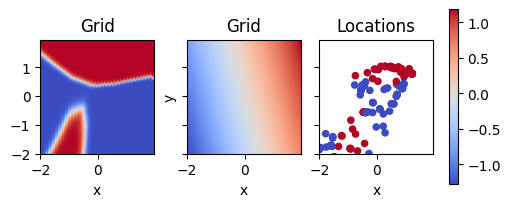

w: [-0.08107267 -0.08195269] b: 0.30702096223831177
w: [0.21699835 0.1570719 ] b: 0.43022990226745605
w: [-0.00053532  0.00532191] b: -0.04381141811609268
w: [0.23631057 0.81195325] b: -0.157539963722229
w: [0.30147943 0.75513685] b: 0.7751843929290771
w: [-0.46756575  0.021625  ] b: -0.38811194896698
w: [ 0.26976192 -0.34318417] b: 0.1502627432346344
w: [ 0.33948493 -0.31352356] b: 0.2798597514629364
w: [0.18735325 0.4317971 ] b: -0.04360223188996315
w: [ 0.3909037 -0.7323444] b: -0.4672999680042267
w: [-0.4411351   0.31842843] b: 0.5119544267654419
w: [0.27413687 0.7661938 ] b: -0.08260566741228104
w: [ 0.03899282 -0.5728872 ] b: -0.06586474925279617
w: [-0.369786  -0.6601347] b: 0.03204640746116638
w: [0.37321165 0.6878122 ] b: 0.5671049356460571
w: [-0.6730177   0.40793923] b: -0.09321155399084091
w: [1.28105445e-20 1.29808490e-13] b: -0.03796279430389404
w: [-0.1528795  -0.72954303] b: 0.7572682499885559
w: [-0.09714085 -0.47875255] b: 0.12753020226955414
w: [-0.3673802  -0.611330

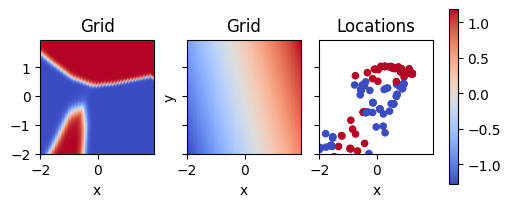

w: [-0.0808527  -0.08256405] b: 0.3073420226573944
w: [0.21823551 0.15721656] b: 0.4305058717727661
w: [-0.00041053  0.0045282 ] b: -0.040696579962968826
w: [0.2363634 0.8132634] b: -0.1576637476682663
w: [0.30189922 0.75436246] b: 0.7762151956558228
w: [-0.4683315   0.02139888] b: -0.3891991674900055
w: [ 0.2702953  -0.34336597] b: 0.150896355509758
w: [ 0.34021324 -0.31357944] b: 0.28052201867103577
w: [0.18741457 0.43316552] b: -0.043698374181985855
w: [ 0.39163768 -0.7322178 ] b: -0.4664919078350067
w: [-0.44164827  0.318688  ] b: 0.5118159651756287
w: [0.27418044 0.7675005 ] b: -0.0827280730009079
w: [ 0.03886444 -0.57285756] b: -0.0655306950211525
w: [-0.3700697 -0.6601427] b: 0.032012153416872025
w: [0.3735988 0.6878297] b: 0.5679135918617249
w: [-0.6737308  0.407711 ] b: -0.093597412109375
w: [1.1415546e-21 3.2279816e-14] b: -0.035075459629297256
w: [-0.15261337 -0.73047274] b: 0.7573882341384888
w: [-0.09719493 -0.4788126 ] b: 0.1275157779455185
w: [-0.36739764 -0.6114079 ] b:

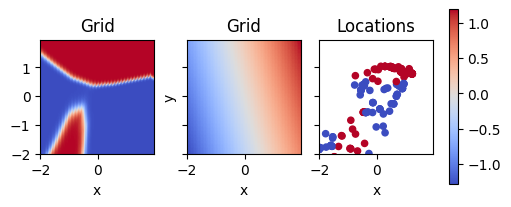

w: [-0.08048145 -0.08295861] b: 0.30770689249038696
w: [0.21964873 0.15752855] b: 0.4307157099246979
w: [-0.0003113   0.00382708] b: -0.037704478949308395
w: [0.23638496 0.81438386] b: -0.1579776555299759
w: [0.30212575 0.75338775] b: 0.7773829102516174
w: [-0.46871868  0.02152169] b: -0.39068275690078735
w: [ 0.27058014 -0.34375378] b: 0.15177887678146362
w: [ 0.340654   -0.31390226] b: 0.28141066431999207
w: [0.18745954 0.43432504] b: -0.04399961233139038
w: [ 0.39209494 -0.73238885] b: -0.46538183093070984
w: [-0.44229484  0.3186519 ] b: 0.5116886496543884
w: [0.27419418 0.76861495] b: -0.08304107934236526
w: [ 0.03850051 -0.5730759 ] b: -0.06509819626808167
w: [-0.37057325 -0.6603866 ] b: 0.032069988548755646
w: [0.37381577 0.68750745] b: 0.5687548518180847
w: [-0.6741018   0.40783373] b: -0.09431613236665726
w: [8.6055700e-23 7.4766455e-15] b: -0.032314639538526535
w: [-0.15228    -0.73114085] b: 0.7576483488082886
w: [-0.09748702 -0.47911683] b: 0.12760348618030548
w: [-0.3677188

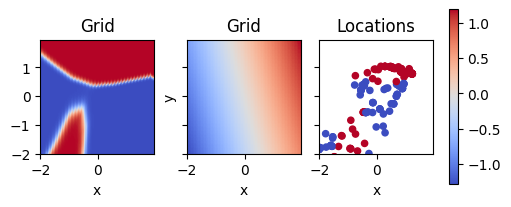

w: [-0.08030897 -0.08345231] b: 0.3080271780490875
w: [0.22094712 0.15767828] b: 0.43090590834617615
w: [-0.0002333   0.00321192] b: -0.034836653620004654
w: [0.23667681 0.815546  ] b: -0.15820737183094025
w: [0.30239385 0.75249904] b: 0.7784898281097412
w: [-0.46919674  0.0215499 ] b: -0.3920499384403229
w: [ 0.27087158 -0.34411213] b: 0.15245309472084045
w: [ 0.34115955 -0.31412855] b: 0.2821556031703949
w: [0.18776973 0.43553793] b: -0.04420439526438713
w: [ 0.39266923 -0.7323865 ] b: -0.46443432569503784
w: [-0.44279     0.31877106] b: 0.5116720199584961
w: [0.27447838 0.76977164] b: -0.08326949924230576
w: [ 0.03821918 -0.573142  ] b: -0.0647338256239891
w: [-0.37101346 -0.6604763 ] b: 0.03209412097930908
w: [0.3742954 0.6872872] b: 0.569599986076355
w: [-0.6745721   0.40787387] b: -0.09490524232387543
w: [5.352747e-24 1.605351e-15] b: -0.029681438580155373
w: [-0.15218753 -0.7319286 ] b: 0.7578363418579102
w: [-0.09770527 -0.4792595 ] b: 0.12764494121074677
w: [-0.36798787 -0.611

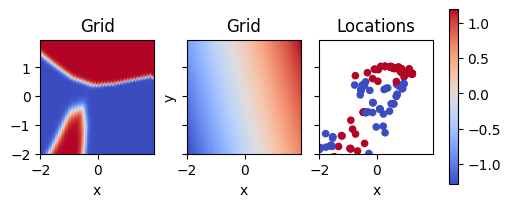

w: [-0.08002524 -0.08381175] b: 0.3083602488040924
w: [0.22240053 0.15798664] b: 0.431036114692688
w: [-0.00017271  0.00267599] b: -0.03209444135427475
w: [0.23687007 0.8165634 ] b: -0.15853364765644073
w: [0.30275202 0.7516745 ] b: 0.779489278793335
w: [-0.46974456  0.021515  ] b: -0.39330923557281494
w: [ 0.2713123 -0.3443294] b: 0.15314938127994537
w: [ 0.34175956 -0.31426594] b: 0.2828713059425354
w: [0.18798317 0.43659732] b: -0.044513020664453506
w: [ 0.3932284  -0.73242736] b: -0.4634473919868469
w: [-0.44339293  0.31869197] b: 0.5116007328033447
w: [0.274663   0.77078366] b: -0.08359304070472717
w: [ 0.03794238 -0.57325715] b: -0.06432873010635376
w: [-0.37147543 -0.66064507] b: 0.03217567503452301
w: [0.3746906 0.6869675] b: 0.5703628659248352
w: [-0.6751258   0.40785477] b: -0.09542268514633179
w: [2.6525007e-25 3.1785888e-16] b: -0.02717665582895279
w: [-0.15196851 -0.7325185 ] b: 0.7580595016479492
w: [-0.09792344 -0.47945988] b: 0.12773486971855164
w: [-0.36832207 -0.61193

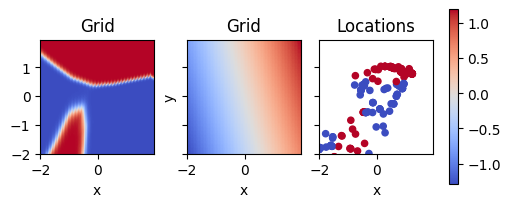

w: [-0.07985684 -0.08428048] b: 0.308592289686203
w: [0.22367758 0.15818645] b: 0.43117615580558777
w: [-0.00012623  0.00221254] b: -0.02947894111275673
w: [0.23719878 0.8177639 ] b: -0.15866334736347198
w: [0.30307737 0.7508472 ] b: 0.7804968953132629
w: [-0.47027087  0.02150241] b: -0.3945445120334625
w: [ 0.27164507 -0.34462994] b: 0.15371979773044586
w: [ 0.3423049 -0.3144369] b: 0.28353723883628845
w: [0.18832207 0.43785766] b: -0.044608768075704575
w: [ 0.39376062 -0.7324634 ] b: -0.46248748898506165
w: [-0.44383872  0.31883726] b: 0.5116270184516907
w: [0.27498373 0.7719795 ] b: -0.08372022956609726
w: [ 0.0376765 -0.5733234] b: -0.06397636979818344
w: [-0.37191746 -0.6607428 ] b: 0.032216865569353104
w: [0.3752432 0.686793 ] b: 0.5711902379989624
w: [-0.6756339  0.4078436] b: -0.09594661742448807
w: [9.917159e-27 5.769594e-17] b: -0.024800792336463928
w: [-0.15189356 -0.7333186 ] b: 0.7581468224525452
w: [-0.09813268 -0.47959578] b: 0.1277882158756256
w: [-0.36856228 -0.61206  

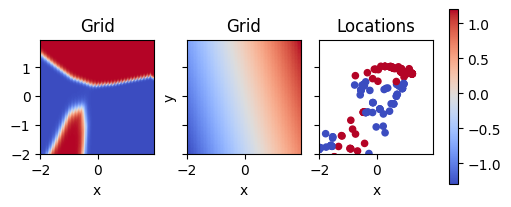

w: [-0.07960813 -0.08469761] b: 0.3088842034339905
w: [0.22497892 0.15846214] b: 0.4313623607158661
w: [-9.1032518e-05  1.8148385e-03] b: -0.02699097990989685
w: [0.23741816 0.818898  ] b: -0.158842533826828
w: [0.3032898  0.74984604] b: 0.7816076278686523
w: [-0.4707008   0.02155946] b: -0.39582234621047974
w: [ 0.27193874 -0.34493342] b: 0.1543872058391571
w: [ 0.3427882  -0.31464297] b: 0.2842289209365845
w: [0.18856321 0.43903658] b: -0.04476739466190338
w: [ 0.39419168 -0.73263794] b: -0.46140292286872864
w: [-0.4442846   0.31877413] b: 0.5115503668785095
w: [0.27519575 0.7731085 ] b: -0.08389723300933838
w: [ 0.03738116 -0.57347554] b: -0.0636649802327156
w: [-0.37236622 -0.66092914] b: 0.03221379965543747
w: [0.37556744 0.68634   ] b: 0.5721442103385925
w: [-0.6760526   0.40789354] b: -0.09652498364448547
w: [2.5307244e-28 9.5372899e-18] b: -0.022554004564881325
w: [-0.15173136 -0.7339999 ] b: 0.7582984566688538
w: [-0.09837186 -0.47982028] b: 0.1278107464313507
w: [-0.36885086 

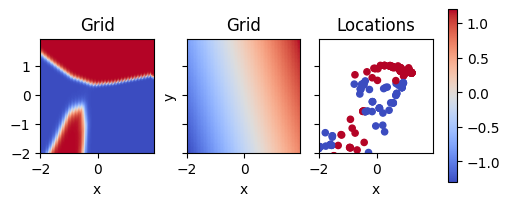

w: [-0.07954556 -0.08498934] b: 0.30929985642433167
w: [0.22625162 0.15875164] b: 0.43154287338256836
w: [-6.4740336e-05  1.4763130e-03] b: -0.024631060659885406
w: [0.23790058 0.8197514 ] b: -0.15924383699893951
w: [0.3035729  0.74901533] b: 0.7826288342475891
w: [-0.47127047  0.02146719] b: -0.39699670672416687
w: [ 0.27235222 -0.3451122 ] b: 0.1549987494945526
w: [ 0.34338376 -0.3147097 ] b: 0.2848946750164032
w: [0.18905717 0.43994433] b: -0.045139580965042114
w: [ 0.39474255 -0.7326589 ] b: -0.46042394638061523
w: [-0.44468206  0.31873366] b: 0.5114556550979614
w: [0.2756704  0.77395713] b: -0.08429571241140366
w: [ 0.0371538 -0.573517 ] b: -0.06335277855396271
w: [-0.3727743 -0.6610176] b: 0.03222706541419029
w: [0.37612337 0.68590796] b: 0.5729033946990967
w: [-0.67664146  0.40784132] b: -0.0969351977109909
w: [3.371536e-30 1.424947e-18] b: -0.02043606899678707
w: [-0.15177326 -0.734513  ] b: 0.7585985064506531
w: [-0.09855706 -0.47993767] b: 0.1278516948223114
w: [-0.3691589  -

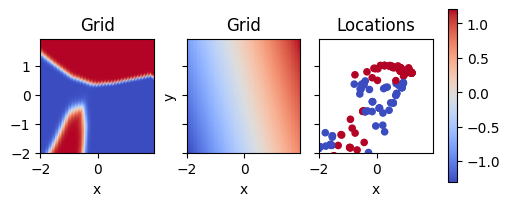

w: [-0.07923806 -0.08549871] b: 0.30956241488456726
w: [0.22750473 0.15887384] b: 0.4317535161972046
w: [-4.5376102e-05  1.1905723e-03] b: -0.02239934913814068
w: [0.23800442 0.8208543 ] b: -0.15937036275863647
w: [0.3038834 0.7481185] b: 0.7835901379585266
w: [-0.4717473  0.0214747] b: -0.3982039988040924
w: [ 0.2727063  -0.34537265] b: 0.15571855008602142
w: [ 0.34389096 -0.31485355] b: 0.2856413424015045
w: [0.18917753 0.44109342] b: -0.04524518549442291
w: [ 0.39521828 -0.73272103] b: -0.45944586396217346
w: [-0.44514635  0.31885257] b: 0.5113263726234436
w: [0.27576703 0.77505434] b: -0.08442014455795288
w: [ 0.03690265 -0.57354957] b: -0.0630694255232811
w: [-0.37317285 -0.6610562 ] b: 0.032203420996665955
w: [0.37644768 0.6855179 ] b: 0.5737436413764954
w: [-0.67709297  0.40782836] b: -0.0975172221660614
w: [-8.7604605e-33  1.9076267e-19] b: -0.018446356058120728
w: [-0.15152235 -0.7352588 ] b: 0.7587162852287292
w: [-0.09875903 -0.4800309 ] b: 0.12786680459976196
w: [-0.3693673

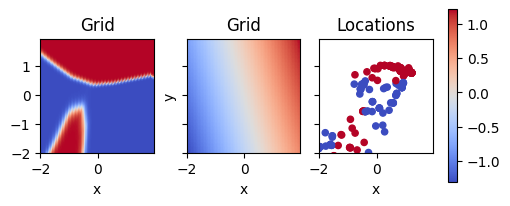

w: [-0.07911855 -0.08593202] b: 0.30984702706336975
w: [0.22873387 0.15903291] b: 0.4319179058074951
w: [-3.1323711e-05  9.5149904e-04] b: -0.02029564045369625
w: [0.23841508 0.821869  ] b: -0.15955042839050293
w: [0.30409306 0.74721694] b: 0.7846118807792664
w: [-0.47222415  0.02147562] b: -0.3993920683860779
w: [ 0.27304736 -0.34561738] b: 0.1562669426202774
w: [ 0.34443077 -0.31495202] b: 0.28624266386032104
w: [0.18960263 0.44216233] b: -0.04539737477898598
w: [ 0.39566877 -0.7327895 ] b: -0.4584497809410095
w: [-0.4455173  0.3189484] b: 0.5112978219985962
w: [0.27617025 0.7760652 ] b: -0.08459712564945221
w: [ 0.03667008 -0.5735555 ] b: -0.06281068176031113
w: [-0.37357938 -0.6610873 ] b: 0.03218323737382889
w: [0.3768967  0.68507147] b: 0.5746297240257263
w: [-0.67757463  0.40783778] b: -0.09802334755659103
w: [-6.9804335e-34  2.2651575e-20] b: -0.01658380776643753
w: [-0.15152086 -0.7359436 ] b: 0.7588564157485962
w: [-0.0989442 -0.4801011] b: 0.12786361575126648
w: [-0.36963633

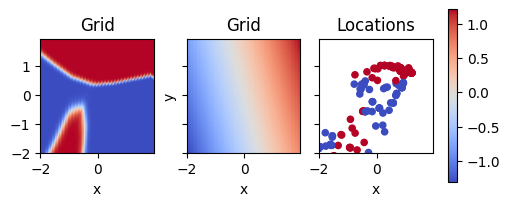

w: [-0.07872321 -0.08614586] b: 0.31015098094940186
w: [0.2301439  0.15944095] b: 0.43205180764198303
w: [-2.1282342e-05  7.5329741e-04] b: -0.01831931248307228
w: [0.23855317 0.8227587 ] b: -0.15987281501293182
w: [0.3043523 0.746257 ] b: 0.7856268882751465
w: [-0.47255045  0.02161382] b: -0.4006933271884918
w: [ 0.2733343 -0.3458983] b: 0.15705053508281708
w: [ 0.34481832 -0.31519127] b: 0.28705835342407227
w: [0.1897597 0.4430936] b: -0.04570294916629791
w: [ 0.3959801 -0.7330811] b: -0.4572722613811493
w: [-0.44611165  0.31884962] b: 0.5111698508262634
w: [0.27630174 0.77694815] b: -0.08491764962673187
w: [ 0.0362863  -0.57379645] b: -0.06245673447847366
w: [-0.37412667 -0.66136605] b: 0.03224821388721466
w: [0.37720054 0.6844928 ] b: 0.5754299163818359
w: [-0.67790556  0.40796822] b: -0.09867362678050995
w: [3.5950078e-36 2.3570098e-21] b: -0.014846901409327984
w: [-0.15123464 -0.73637474] b: 0.7590858936309814
w: [-0.09928288 -0.48041466] b: 0.12795625627040863
w: [-0.37005156 -0

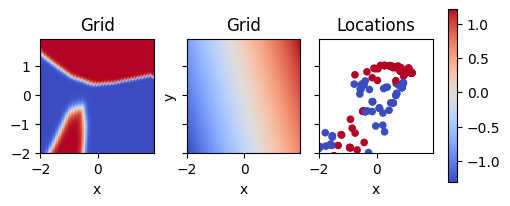

w: [-0.07856358 -0.08648275] b: 0.31047937273979187
w: [0.2313477  0.15968868] b: 0.4322362542152405
w: [-1.4221892e-05  5.9054606e-04] b: -0.0164693184196949
w: [0.23889764 0.82366574] b: -0.16014647483825684
w: [0.30472285 0.74551046] b: 0.7864645719528198
w: [-0.47310382  0.02152658] b: -0.4017863869667053
w: [ 0.27371725 -0.34607807] b: 0.15778306126594543
w: [ 0.34535283 -0.31526446] b: 0.28786155581474304
w: [0.19011216 0.4440564 ] b: -0.04594772309064865
w: [ 0.39648998 -0.7331217 ] b: -0.45630839467048645
w: [-0.4464244   0.31898355] b: 0.5109745860099792
w: [0.27663875 0.77785045] b: -0.08518869429826736
w: [ 0.03605524 -0.5738459 ] b: -0.06214342266321182
w: [-0.37451452 -0.6614371 ] b: 0.03226105496287346
w: [0.37770572 0.6840935 ] b: 0.5761243104934692
w: [-0.6784612   0.40788758] b: -0.09912412613630295
w: [1.0406291e-37 2.1177598e-22] b: -0.013233662582933903
w: [-0.15115465 -0.7369309 ] b: 0.7592781782150269
w: [-0.09946688 -0.48052996] b: 0.12801025807857513
w: [-0.3702

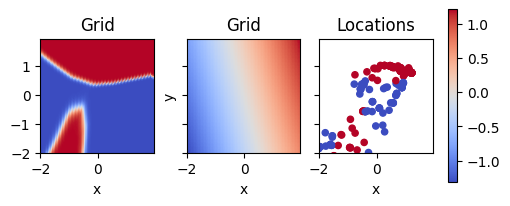

w: [-0.07834111 -0.08676039] b: 0.3107101023197174
w: [0.23261069 0.16006112] b: 0.4323183000087738
w: [-9.3403632e-06  4.5823204e-04] b: -0.014744146727025509
w: [0.23922852 0.8246164 ] b: -0.1603584587574005
w: [0.30501387 0.74468035] b: 0.7873486876487732
w: [-0.4736589   0.02142619] b: -0.4028394818305969
w: [ 0.2741614  -0.34616196] b: 0.1583126187324524
w: [ 0.34593493 -0.3152775 ] b: 0.2884887456893921
w: [0.19045989 0.44505513] b: -0.04613680765032768
w: [ 0.39696735 -0.733228  ] b: -0.45529696345329285
w: [-0.44688597  0.31878698] b: 0.5109816789627075
w: [0.27696505 0.77879393] b: -0.08540037274360657
w: [ 0.03583705 -0.573933  ] b: -0.06185460090637207
w: [-0.37492418 -0.661594  ] b: 0.03230397030711174
w: [0.37815922 0.68364716] b: 0.5768811702728271
w: [-0.67901635  0.40779513] b: -0.0995497852563858
w: [7.6253408e-39 1.6128103e-23] b: -0.01174161396920681
w: [-0.15104394 -0.73743576] b: 0.7593910694122314
w: [-0.09965032 -0.48069945] b: 0.12806355953216553
w: [-0.3705648 

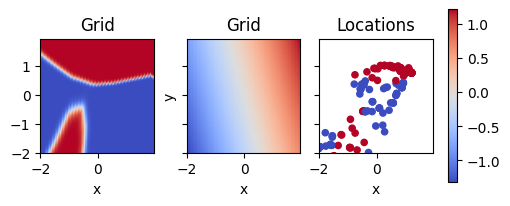

w: [-0.07799294 -0.08717305] b: 0.31095048785209656
w: [0.23383507 0.16022865] b: 0.43249639868736267
w: [-6.0241900e-06  3.5177832e-04] b: -0.013141829520463943
w: [0.23936819 0.8256275 ] b: -0.16049465537071228
w: [0.3052855  0.74377704] b: 0.7882655262947083
w: [-0.4740385   0.02150647] b: -0.40406936407089233
w: [ 0.2744678 -0.3464129] b: 0.15902148187160492
w: [ 0.34636903 -0.31542674] b: 0.2892425060272217
w: [0.19061263 0.44611663] b: -0.04624791443347931
w: [ 0.3972987 -0.733421 ] b: -0.4541776180267334
w: [-0.4473715  0.3188353] b: 0.5108878016471863
w: [0.2770993  0.77979875] b: -0.08553577214479446
w: [ 0.0355301 -0.5740069] b: -0.06160014867782593
w: [-0.37538666 -0.66167605] b: 0.032291900366544724
w: [0.37846893 0.6831287 ] b: 0.5777208805084229
w: [-0.67937666  0.4078506 ] b: -0.1001918762922287
w: [7.6253408e-39 1.0159985e-24] b: -0.01036780420690775
w: [-0.1507788 -0.7380786] b: 0.759493887424469
w: [-0.0999153  -0.48083162] b: 0.12808343768119812
w: [-0.37085226 -0.61

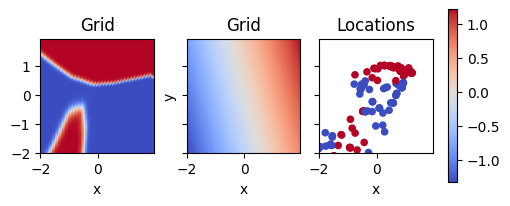

w: [-0.07782637 -0.08744799] b: 0.3112207353115082
w: [0.23496582 0.16051233] b: 0.4326477348804474
w: [-3.8124595e-06  2.6705640e-04] b: -0.011659915558993816
w: [0.2397709  0.82651013] b: -0.1607232391834259
w: [0.30555132 0.7429526 ] b: 0.789129912853241
w: [-0.4744696   0.02151702] b: -0.4052322804927826
w: [ 0.27476525 -0.34662697] b: 0.15970478951931
w: [ 0.3468124  -0.31554955] b: 0.29002904891967773
w: [0.19102852 0.44705147] b: -0.04644997790455818
w: [ 0.39766544 -0.7336162 ] b: -0.45306411385536194
w: [-0.447657    0.31888345] b: 0.5107471942901611
w: [0.27749747 0.7806748 ] b: -0.08576374500989914
w: [ 0.03523912 -0.5741283 ] b: -0.06131822615861893
w: [-0.37582287 -0.66182035] b: 0.03230176120996475
w: [0.37891826 0.68260354] b: 0.5784861445426941
w: [-0.6798173  0.4078683] b: -0.100709930062294
w: [7.6253408e-39 5.1169583e-26] b: -0.009108804166316986
w: [-0.15074316 -0.7385667 ] b: 0.7596462965011597
w: [-0.10015921 -0.48101065] b: 0.12812884151935577
w: [-0.37116358 -0.

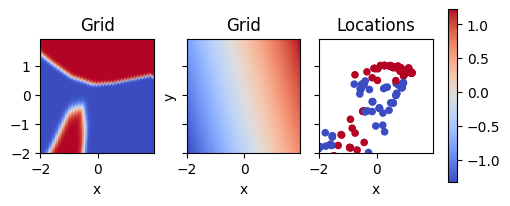

w: [-0.07759608 -0.08785612] b: 0.31150364875793457
w: [0.23610458 0.16064137] b: 0.4328436851501465
w: [-2.3654184e-06  2.0039013e-04] b: -0.010295464657247066
w: [0.24006307 0.8274322 ] b: -0.16090688109397888
w: [0.30577618 0.7420311 ] b: 0.7900428175926208
w: [-0.47493556  0.02149702] b: -0.4063292145729065
w: [ 0.27515137 -0.34678245] b: 0.1602950543165207
w: [ 0.34733605 -0.31558186] b: 0.29065272212028503
w: [0.1913388 0.4480202] b: -0.04661201685667038
w: [ 0.3980551  -0.73374265] b: -0.45203232765197754
w: [-0.44803387  0.3188524 ] b: 0.5106399655342102
w: [0.27778545 0.7815901 ] b: -0.0859469398856163
w: [ 0.03502404 -0.57410973] b: -0.061159055680036545
w: [-0.37619916 -0.6618211 ] b: 0.032223641872406006
w: [0.37926605 0.68200505] b: 0.5793219804763794
w: [-0.680279    0.40784296] b: -0.10120908915996552
w: [7.625341e-39 1.955259e-27] b: -0.007960706949234009
w: [-0.1506361 -0.7391677] b: 0.7598094344139099
w: [-0.1003395  -0.48105016] b: 0.1280774474143982
w: [-0.3714335  

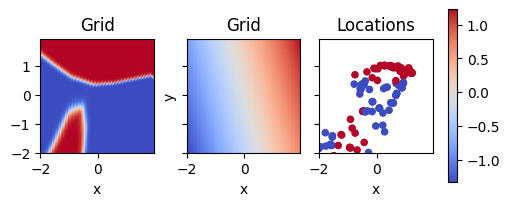

w: [-0.07733195 -0.08800935] b: 0.3117266297340393
w: [0.23740071 0.16098712] b: 0.43282783031463623
w: [-1.4375162e-06  1.4854851e-04] b: -0.009045068174600601
w: [0.24047743 0.82816607] b: -0.1612742394208908
w: [0.30636558 0.741539  ] b: 0.7905738353729248
w: [-0.47537205  0.02149562] b: -0.407482773065567
w: [ 0.27546662 -0.34699267] b: 0.16104929149150848
w: [ 0.34773445 -0.31572038] b: 0.2916094958782196
w: [0.1917614  0.44880873] b: -0.046951085329055786
w: [ 0.39841542 -0.7338754 ] b: -0.4509425163269043
w: [-0.4484554   0.31892437] b: 0.5105644464492798
w: [0.27819544 0.7823167 ] b: -0.08631434291601181
w: [ 0.03461542 -0.5742734 ] b: -0.06070429086685181
w: [-0.37677842 -0.6620053 ] b: 0.032411739230155945
w: [0.3800054  0.68174744] b: 0.579695999622345
w: [-0.6807366   0.40785915] b: -0.1017044335603714
w: [7.625341e-39 5.155908e-29] b: -0.006919181905686855
w: [-0.15051177 -0.7395077 ] b: 0.7599537372589111
w: [-0.10072759 -0.48127633] b: 0.12832245230674744
w: [-0.3718956 

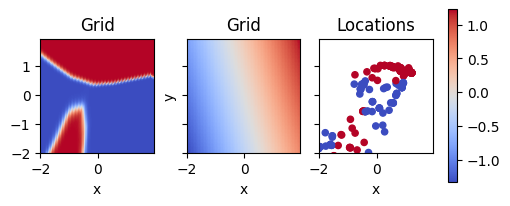

w: [-0.07704366 -0.08841999] b: 0.31198254227638245
w: [0.2384889  0.16111028] b: 0.4330257773399353
w: [-8.54877612e-07  1.08729626e-04] b: -0.00790484994649887
w: [0.24065514 0.829124  ] b: -0.16139262914657593
w: [0.3066308 0.7406871] b: 0.7914113998413086
w: [-0.47583997  0.02147845] b: -0.4085437059402466
w: [ 0.27585107 -0.3471505 ] b: 0.16167093813419342
w: [ 0.34825936 -0.3157914 ] b: 0.29219481348991394
w: [0.19194527 0.44982412] b: -0.04703887179493904
w: [ 0.39879164 -0.73401505] b: -0.44991832971572876
w: [-0.4488811  0.3189045] b: 0.5104747414588928
w: [0.278368  0.7832693] b: -0.08643140643835068
w: [ 0.03439127 -0.5742648 ] b: -0.06054244190454483
w: [-0.37714982 -0.6620069 ] b: 0.032340068370103836
w: [0.3803238 0.6811921] b: 0.5804812908172607
w: [-0.6811818  0.4078197] b: -0.10221469402313232
w: [7.6253408e-39 7.3599037e-31] b: -0.0059794834814965725
w: [-0.1502917 -0.7401283] b: 0.7600552439689636
w: [-0.10091858 -0.48132175] b: 0.12828515470027924
w: [-0.3721021 -0.

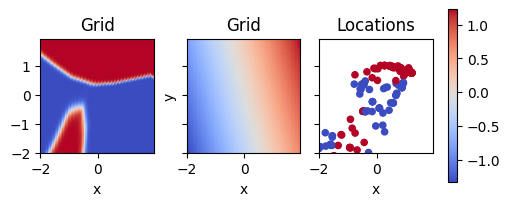

w: [-0.07664767 -0.08870047] b: 0.3121817111968994
w: [0.23969592 0.16138357] b: 0.4331478178501129
w: [-4.9698627e-07  7.8536825e-05] b: -0.006870493292808533
w: [0.24081254 0.8300359 ] b: -0.16153278946876526
w: [0.3069081  0.73981553] b: 0.7922309041023254
w: [-0.47624215  0.02152261] b: -0.40968945622444153
w: [ 0.2762249  -0.34729925] b: 0.1623261421918869
w: [ 0.34885097 -0.31600088] b: 0.29249733686447144
w: [0.19211732 0.45078292] b: -0.04715786129236221
w: [ 0.39907312 -0.7342859 ] b: -0.44872429966926575
w: [-0.4493493   0.31889895] b: 0.5103606581687927
w: [0.27852103 0.78417367] b: -0.08657144010066986
w: [ 0.03408749 -0.5743658 ] b: -0.06031886860728264
w: [-0.37762108 -0.66213936] b: 0.03234005719423294
w: [0.38063055 0.6805853 ] b: 0.5812482833862305
w: [-0.6815705  0.4078361] b: -0.10281587392091751
w: [ 7.6253408e-39 -7.0487215e-34] b: -0.005136498250067234
w: [-0.15000865 -0.740614  ] b: 0.7601392269134521
w: [-0.10119524 -0.4814813 ] b: 0.12831535935401917
w: [-0.372

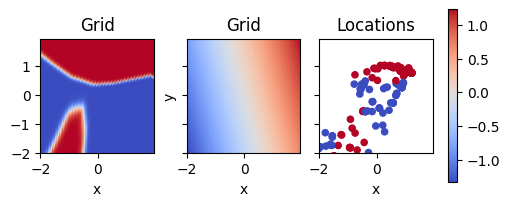

w: [-0.07642177 -0.08894518] b: 0.3124154210090637
w: [0.24079032 0.16164841] b: 0.4332759976387024
w: [-2.8214586e-07  5.5948873e-05] b: -0.005937287583947182
w: [0.24118419 0.8308737 ] b: -0.16173748672008514
w: [0.3072169  0.73903775] b: 0.7929854989051819
w: [-0.47673783  0.02146015] b: -0.4107162058353424
w: [ 0.27662638 -0.34739122] b: 0.16292092204093933
w: [ 0.34947202 -0.31613687] b: 0.29283684492111206
w: [0.19249794 0.45167565] b: -0.04733344539999962
w: [ 0.3994219 -0.7344851] b: -0.44760170578956604
w: [-0.4496977   0.31887007] b: 0.5102565884590149
w: [0.2788883  0.78500503] b: -0.08677463978528976
w: [ 0.0338349  -0.57442784] b: -0.06009805575013161
w: [-0.37804413 -0.6622428 ] b: 0.032341357320547104
w: [0.38108468 0.68004966] b: 0.581932008266449
w: [-0.6820667  0.4077712] b: -0.10327094048261642
w: [ 7.6253408e-39 -1.4781054e-34] b: -0.004384803120046854
w: [-0.14991397 -0.74105626] b: 0.760260283946991
w: [-0.1014238  -0.48160365] b: 0.12834900617599487
w: [-0.372755

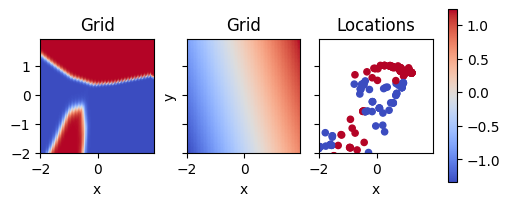

w: [-0.07615526 -0.0891675 ] b: 0.31266382336616516
w: [0.24190743 0.16192566] b: 0.4333924353122711
w: [-1.5624504e-07  3.9285867e-05] b: -0.0051001496613025665
w: [0.2414887 0.8316273] b: -0.16198493540287018
w: [0.3075307  0.73826283] b: 0.7937150001525879
w: [-0.47727528  0.02135308] b: -0.4117198586463928
w: [ 0.27709886 -0.34741336] b: 0.16352708637714386
w: [ 0.35016915 -0.31624985] b: 0.2930663526058197
w: [0.19281276 0.45247966] b: -0.0475567989051342
w: [ 0.399811   -0.73464143] b: -0.446503221988678
w: [-0.45008233  0.31884181] b: 0.5101237297058105
w: [0.27918777 0.7857515 ] b: -0.08702109009027481
w: [ 0.03361345 -0.57445776] b: -0.0598817802965641
w: [-0.3784345 -0.6623154] b: 0.03233741968870163
w: [0.38149562 0.67947453] b: 0.5825802683830261
w: [-0.68260396  0.40766317] b: -0.10372600704431534
w: [7.6253408e-39 4.5413716e-37] b: -0.0037187125999480486
w: [-0.14976457 -0.7414346 ] b: 0.7604089975357056
w: [-0.10162598 -0.48169562] b: 0.1283860206604004
w: [-0.37305525 -

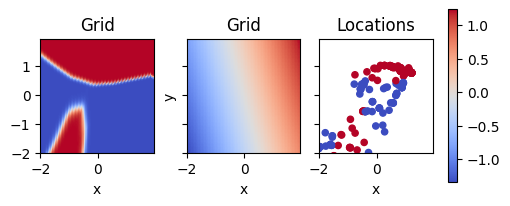

w: [-0.0760589  -0.08955227] b: 0.3129693567752838
w: [0.24279252 0.16194049] b: 0.43365904688835144
w: [-8.430034e-08  2.717253e-05] b: -0.004353687167167664
w: [0.24192984 0.832417  ] b: -0.16214878857135773
w: [0.3077691  0.73743445] b: 0.7944990396499634
w: [-0.477708    0.02134496] b: -0.41275718808174133
w: [ 0.2774135 -0.3475999] b: 0.16421177983283997
w: [ 0.35071573 -0.3164229 ] b: 0.2934584319591522
w: [0.1932587  0.45332754] b: -0.047690607607364655
w: [ 0.40011585 -0.73481375] b: -0.445416122674942
w: [-0.45027882  0.31897414] b: 0.5099088549613953
w: [0.2796241  0.78653586] b: -0.0871831402182579
w: [ 0.03339506 -0.57440376] b: -0.05976835638284683
w: [-0.37877455 -0.662247  ] b: 0.03221559524536133
w: [0.38190547 0.67886347] b: 0.5833171606063843
w: [-0.68304825  0.40765193] b: -0.10422437638044357
w: [7.625341e-39 2.416909e-38] b: -0.0031323516741394997
w: [-0.14978337 -0.74198174] b: 0.7605738639831543
w: [-0.10181092 -0.48168355] b: 0.12831708788871765
w: [-0.37329584 

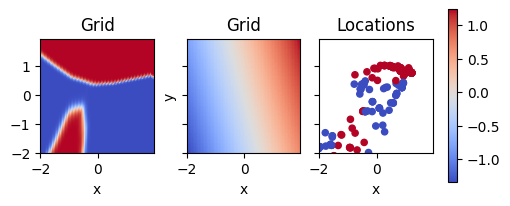

w: [-0.07568809 -0.089754  ] b: 0.31319400668144226
w: [0.24393529 0.16219379] b: 0.43375375866889954
w: [-4.4259075e-08  1.8500383e-05] b: -0.003692253492772579
w: [0.24222438 0.83316964] b: -0.16243292391300201
w: [0.30811536 0.7366672 ] b: 0.7951952815055847
w: [-0.47799507  0.02148814] b: -0.4139164984226227
w: [ 0.27767083 -0.3478365 ] b: 0.1648942530155182
w: [ 0.3511909  -0.31674892] b: 0.293795645236969
w: [0.1935725  0.45412424] b: -0.04795520380139351
w: [ 0.40025887 -0.735194  ] b: -0.4441415071487427
w: [-0.45069554  0.31891465] b: 0.5097938179969788
w: [0.27991554 0.78728086] b: -0.0874672457575798
w: [ 0.03298938 -0.574576  ] b: -0.059506602585315704
w: [-0.37932613 -0.6624258 ] b: 0.03225840628147125
w: [0.38233098 0.6782782 ] b: 0.5839429497718811
w: [-0.6833421  0.4077833] b: -0.10480678081512451
w: [7.625341e-39 2.416909e-38] b: -0.0026197179686278105
w: [-0.14957608 -0.74232984] b: 0.760726809501648
w: [-0.10219478 -0.48190442] b: 0.12840668857097626
w: [-0.37375915 

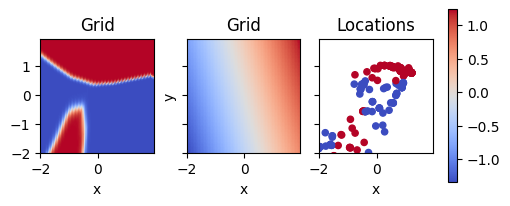

w: [-0.07551777 -0.08998209] b: 0.31340235471725464
w: [0.24493295 0.1624263 ] b: 0.4338854253292084
w: [-2.2581515e-08  1.2390309e-05] b: -0.003110006684437394
w: [0.2427046 0.8339691] b: -0.16257993876934052
w: [0.30838704 0.7358889 ] b: 0.7959190607070923
w: [-0.4784189   0.02148856] b: -0.41497448086738586
w: [ 0.27800453 -0.34797525] b: 0.16550491750240326
w: [ 0.3517584  -0.31692705] b: 0.294139564037323
w: [0.19405869 0.45498267] b: -0.04807088151574135
w: [ 0.40050352 -0.73548746] b: -0.4429154694080353
w: [-0.45098883  0.3188089 ] b: 0.5097153782844543
w: [0.28039166 0.7880752 ] b: -0.08761203289031982
w: [ 0.03270448 -0.5746495 ] b: -0.05931226536631584
w: [-0.37975857 -0.6625218 ] b: 0.03223678469657898
w: [0.3827697 0.6777057] b: 0.5846421718597412
w: [-0.6837782   0.40777808] b: -0.10531385242938995
w: [7.625341e-39 2.416909e-38] b: -0.002174754859879613
w: [-0.1495568  -0.74274445] b: 0.7608097195625305
w: [-0.10245713 -0.48203012] b: 0.12843261659145355
w: [-0.3740976 -0

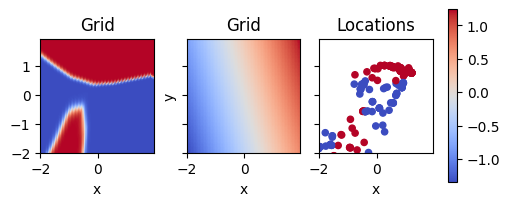

w: [-0.07527933 -0.09014482] b: 0.31367620825767517
w: [0.24597698 0.16267642] b: 0.4340122938156128
w: [-1.1180894e-08  8.1566723e-06] b: -0.002600983250886202
w: [0.24313354 0.83460194] b: -0.16291400790214539
w: [0.3086935 0.7351403] b: 0.7966058254241943
w: [-0.47887188  0.02145165] b: -0.41599810123443604
w: [ 0.2784038  -0.34805048] b: 0.1661418229341507
w: [ 0.35236916 -0.31707898] b: 0.29444053769111633
w: [0.19450031 0.45566514] b: -0.04838140681385994
w: [ 0.40077367 -0.73574567] b: -0.4417107105255127
w: [-0.451301   0.3187699] b: 0.5095546245574951
w: [0.28081635 0.7887014 ] b: -0.08794476836919785
w: [ 0.03243537 -0.57470745] b: -0.05910607427358627
w: [-0.38018423 -0.6626085 ] b: 0.03223460912704468
w: [0.38321024 0.6771053 ] b: 0.5852412581443787
w: [-0.68425     0.40774876] b: -0.10577686131000519
w: [7.625341e-39 2.416909e-38] b: -0.0017914222553372383
w: [-0.14948818 -0.74302745] b: 0.761018693447113
w: [-0.10270984 -0.48214075] b: 0.12847845256328583
w: [-0.37447184 

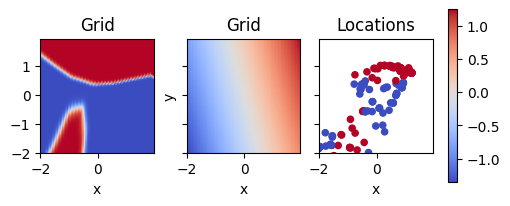

w: [-0.07496546 -0.09050554] b: 0.3138548731803894
w: [0.24695146 0.16278335] b: 0.4341834783554077
w: [-5.364538e-09  5.273949e-06] b: -0.002159164287149906
w: [0.24335526 0.8354877 ] b: -0.162960484623909
w: [0.30899653 0.734321  ] b: 0.797296941280365
w: [-0.47931463  0.02142707] b: -0.41701698303222656
w: [ 0.2787766  -0.34815544] b: 0.1668056845664978
w: [ 0.35297608 -0.31725195] b: 0.29470497369766235
w: [0.1947334 0.4566016] b: -0.04840489476919174
w: [ 0.40105972 -0.7359731 ] b: -0.44055286049842834
w: [-0.4516185  0.3188328] b: 0.5093975067138672
w: [0.28103402 0.789581  ] b: -0.08799003809690475
w: [ 0.03219919 -0.574699  ] b: -0.05896490812301636
w: [-0.38055784 -0.662609  ] b: 0.03216607868671417
w: [0.38356793 0.6764975 ] b: 0.58592689037323
w: [-0.68467146  0.40769258] b: -0.10634403675794601
w: [7.625341e-39 2.416909e-38] b: -0.001463766791857779
w: [-0.14928365 -0.7435508 ] b: 0.7610676288604736
w: [-0.10292704 -0.4821789 ] b: 0.12846288084983826
w: [-0.3747295 -0.61352

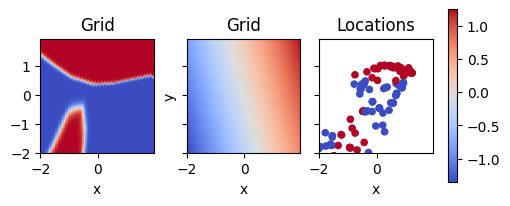

w: [-0.07466368 -0.09069804] b: 0.31405380368232727
w: [0.24799307 0.16301852] b: 0.4342854917049408
w: [-2.4902413e-09  3.3465417e-06] b: -0.0017785498639568686
w: [0.24372537 0.8362334 ] b: -0.16316212713718414
w: [0.30933705 0.7335721 ] b: 0.7979468703269958
w: [-0.47984105  0.02133845] b: -0.41783231496810913
w: [ 0.27905577 -0.34832975] b: 0.16748523712158203
w: [ 0.35346583 -0.31750068] b: 0.29508471488952637
w: [0.19511352 0.457401  ] b: -0.048579953610897064
w: [ 0.4012266  -0.73632866] b: -0.4392782151699066
w: [-0.45198092  0.31870162] b: 0.5093080401420593
w: [0.28139994 0.79032123] b: -0.08818971365690231
w: [ 0.03183069 -0.574823  ] b: -0.05873844027519226
w: [-0.38106355 -0.6627424 ] b: 0.03218185156583786
w: [0.38400877 0.67592025] b: 0.5865363478660583
w: [-0.6850093   0.40774807] b: -0.1069062203168869
w: [7.625341e-39 2.416909e-38] b: -0.0011859878432005644
w: [-0.14913966 -0.7438961 ] b: 0.7611733078956604
w: [-0.1032756  -0.48235014] b: 0.12853245437145233
w: [-0.37

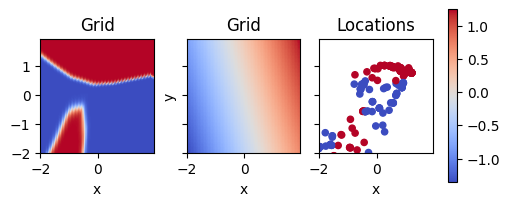

w: [-0.07443397 -0.09104081] b: 0.31430405378341675
w: [0.24883385 0.1631201 ] b: 0.43453168869018555
w: [-1.1165627e-09  2.0821969e-06] b: -0.0014532249188050628
w: [0.2439692 0.8370834] b: -0.16322629153728485
w: [0.3095456 0.7327028] b: 0.7986903786659241
w: [-0.48053902  0.02108254] b: -0.41848433017730713
w: [ 0.27949205 -0.3483538 ] b: 0.16811425983905792
w: [ 0.354135  -0.3175733] b: 0.2953077554702759
w: [0.1953621 0.4583086] b: -0.048615697771310806
w: [ 0.4015454 -0.7365643] b: -0.43813273310661316
w: [-0.45216343  0.31883654] b: 0.5090482234954834
w: [0.281639   0.79116577] b: -0.088251993060112
w: [ 0.03169052 -0.57476467] b: -0.05869158357381821
w: [-0.38133046 -0.6627025 ] b: 0.032030194997787476
w: [0.38427505 0.67524254] b: 0.5872758626937866
w: [-0.6855192   0.40759963] b: -0.10734596848487854
w: [7.625341e-39 2.416909e-38] b: -0.0009524997440166771
w: [-0.14898925 -0.74439746] b: 0.7612734436988831
w: [-0.10339073 -0.48234242] b: 0.12842914462089539
w: [-0.3752917  -0

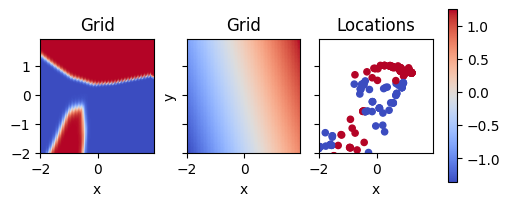

w: [-0.07415586 -0.09102058] b: 0.3144599199295044
w: [0.24994043 0.16351108] b: 0.4345017969608307
w: [-4.8271581e-10  1.2691723e-06] b: -0.0011774281738325953
w: [0.2445261  0.83762956] b: -0.163561150431633
w: [0.30999288 0.7321488 ] b: 0.799177885055542
w: [-0.48113027  0.020944  ] b: -0.4191873073577881
w: [ 0.2798415 -0.3484606] b: 0.1686926931142807
w: [ 0.35464615 -0.31779486] b: 0.29567673802375793
w: [0.1959225  0.45891204] b: -0.048921339213848114
w: [ 0.40169346 -0.7369483 ] b: -0.43683961033821106
w: [-0.45262125  0.3185549 ] b: 0.5090746879577637
w: [0.2821907  0.79170585] b: -0.08858449012041092
w: [ 0.03126313 -0.5749673 ] b: -0.058367326855659485
w: [-0.38191974 -0.662939  ] b: 0.032168738543987274
w: [0.38488644 0.6747976 ] b: 0.587679922580719
w: [-0.6859248   0.40765327] b: -0.10780742019414902
w: [7.625341e-39 2.416909e-38] b: -0.0007579848752357066
w: [-0.14891063 -0.744501  ] b: 0.7613781094551086
w: [-0.10380628 -0.4825995 ] b: 0.12860791385173798
w: [-0.3758438

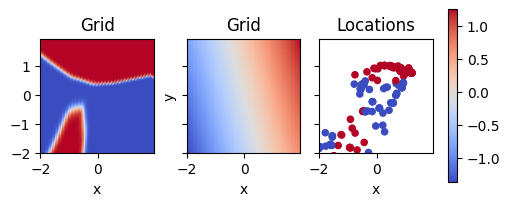

w: [-0.07390054 -0.09138238] b: 0.31464883685112
w: [0.25080356 0.16356397] b: 0.4346785247325897
w: [-2.0084055e-10  7.5714831e-07] b: -0.0009456112748011947
w: [0.24484755 0.83850193] b: -0.16360822319984436
w: [0.31030962 0.7313923 ] b: 0.799794614315033
w: [-0.4816703   0.02083416] b: -0.4199560582637787
w: [ 0.2801145 -0.3486433] b: 0.1693970412015915
w: [ 0.35516658 -0.31803876] b: 0.2959739863872528
w: [0.19625695 0.45983556] b: -0.048943955451250076
w: [ 0.4018793  -0.73724854] b: -0.435627281665802
w: [-0.45284292  0.3186483 ] b: 0.5089008808135986
w: [0.28250894 0.7925726 ] b: -0.08862929791212082
w: [ 0.03097511 -0.5749763 ] b: -0.058244820684194565
w: [-0.3823158 -0.6629363] b: 0.03209267556667328
w: [0.38528192 0.67421514] b: 0.5883018374443054
w: [-0.6862744  0.4076518] b: -0.10836215317249298
w: [7.625341e-39 2.416909e-38] b: -0.0005974415107630193
w: [-0.1487809 -0.7450071] b: 0.7614338994026184
w: [-0.10407311 -0.48265043] b: 0.12859085202217102
w: [-0.37613627 -0.6137

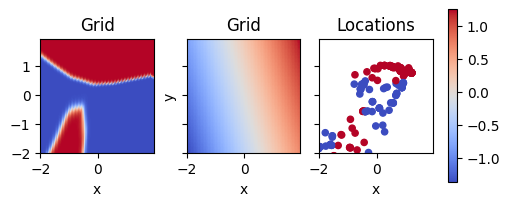

w: [-0.07355281 -0.09151945] b: 0.31489574909210205
w: [0.25178096 0.16376527] b: 0.4348192512989044
w: [-8.025907e-11  4.416404e-07] b: -0.0007524929824285209
w: [0.24513277 0.83910716] b: -0.1638866513967514
w: [0.31062248 0.7306564 ] b: 0.8004218339920044
w: [-0.48228568  0.02065566] b: -0.4206644296646118
w: [ 0.28054008 -0.3486851 ] b: 0.17004279792308807
w: [ 0.35573882 -0.3181529 ] b: 0.2962999641895294
w: [0.19654341 0.46049917] b: -0.04919358342885971
w: [ 0.40206698 -0.7375813 ] b: -0.434352308511734
w: [-0.4532152   0.31866378] b: 0.5087205767631531
w: [0.2827877 0.7931724] b: -0.08890561014413834
w: [ 0.03067714 -0.5750201 ] b: -0.05808620899915695
w: [-0.38275123 -0.6629966 ] b: 0.03206782042980194
w: [0.38565376 0.67358744] b: 0.5888607501983643
w: [-0.686699    0.40762126] b: -0.10886238515377045
w: [7.625341e-39 2.416909e-38] b: -0.0004662182182073593
w: [-0.14855218 -0.7452517 ] b: 0.7615969777107239
w: [-0.10435224 -0.4827379 ] b: 0.12861035764217377
w: [-0.3764962 -0

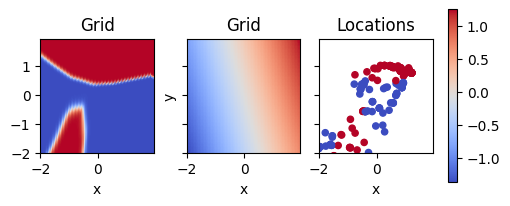

w: [-0.07326575 -0.09172358] b: 0.3150496482849121
w: [0.25270337 0.16394038] b: 0.4349268674850464
w: [-3.0739182e-11  2.5160941e-07] b: -0.0005931050982326269
w: [0.24554981 0.83986974] b: -0.16399796307086945
w: [0.3109202 0.7299025] b: 0.8010393977165222
w: [-0.48292616  0.02046548] b: -0.4212875962257385
w: [ 0.28091887 -0.3487561 ] b: 0.17058250308036804
w: [ 0.35629192 -0.31826857] b: 0.2965998649597168
w: [0.19697171 0.4613147 ] b: -0.04927966743707657
w: [ 0.40222073 -0.7379592 ] b: -0.4330562651157379
w: [-0.45353517  0.3185743 ] b: 0.5086398720741272
w: [0.28320125 0.79392964] b: -0.08901426196098328
w: [ 0.03037995 -0.5750723 ] b: -0.0579492561519146
w: [-0.38319224 -0.6630724 ] b: 0.03204057738184929
w: [0.38605204 0.6729649 ] b: 0.5894686579704285
w: [-0.6870965   0.40760797] b: -0.10936464369297028
w: [7.625341e-39 2.416909e-38] b: -0.0003600425261538476
w: [-0.14843321 -0.7455845 ] b: 0.7616465091705322
w: [-0.10463621 -0.48283714] b: 0.12862014770507812
w: [-0.37687314

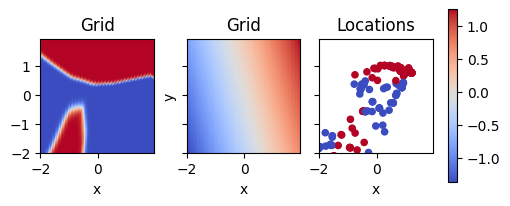

w: [-0.07299455 -0.09189627] b: 0.3153078854084015
w: [0.2536086  0.16405308] b: 0.43504807353019714
w: [-1.1257811e-11  1.3985367e-07] b: -0.0004628281749319285
w: [0.2459375  0.84041995] b: -0.16431987285614014
w: [0.3113652  0.72935814] b: 0.8014834523200989
w: [-0.48358855  0.02022808] b: -0.42190924286842346
w: [ 0.28132036 -0.34881943] b: 0.17131194472312927
w: [ 0.35692796 -0.31846336] b: 0.29678183794021606
w: [0.19735879 0.46192464] b: -0.04957158863544464
w: [ 0.40247893 -0.73814076] b: -0.43192994594573975
w: [-0.4537907   0.31868747] b: 0.5084268450737
w: [0.28358302 0.7944737 ] b: -0.08933445066213608
w: [ 0.03009475 -0.5750534 ] b: -0.057759154587984085
w: [-0.3836026  -0.66305333] b: 0.032042015343904495
w: [0.38657406 0.67249525] b: 0.5898433327674866
w: [-0.6875784   0.40752566] b: -0.1097794845700264
w: [7.625341e-39 2.416909e-38] b: -0.00027503803721629083
w: [-0.1482882 -0.7458397] b: 0.7618253827095032
w: [-0.10490638 -0.48285812] b: 0.12868022918701172
w: [-0.3772

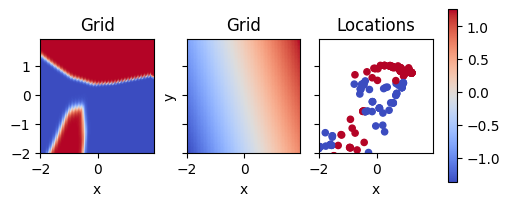

w: [-0.07269055 -0.09203999] b: 0.31537628173828125
w: [0.2545655  0.16427775] b: 0.4350528419017792
w: [-3.9329243e-12  7.5753256e-08] b: -0.0003574201837182045
w: [0.24640612 0.8411668 ] b: -0.16441020369529724
w: [0.31184855 0.7288233 ] b: 0.801877498626709
w: [-0.4841972   0.02004835] b: -0.42257988452911377
w: [ 0.28167567 -0.34890506] b: 0.17197440564632416
w: [ 0.3574401  -0.31861246] b: 0.29725852608680725
w: [0.19783509 0.46272656] b: -0.04963607341051102
w: [ 0.40266666 -0.7384522 ] b: -0.4306878447532654
w: [-0.45413253  0.3184136 ] b: 0.5084376931190491
w: [0.28404817 0.7952151 ] b: -0.08942233771085739
w: [ 0.02974729 -0.57514507] b: -0.05751357600092888
w: [-0.38408637 -0.66316104] b: 0.03210962563753128
w: [0.38719526 0.6721097 ] b: 0.5902013182640076
w: [-0.6880169   0.40746737] b: -0.11025796830654144
w: [7.625341e-39 2.416909e-38] b: -0.00020773061260115355
w: [-0.14816776 -0.74612   ] b: 0.7618011236190796
w: [-0.10524841 -0.48299816] b: 0.12880612909793854
w: [-0.37

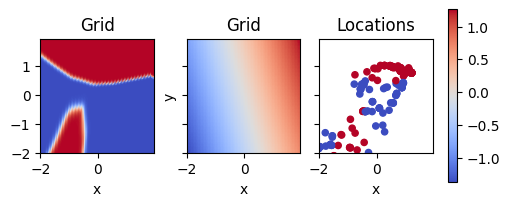

w: [-0.07248652 -0.09231838] b: 0.3156687319278717
w: [0.25527164 0.16428176] b: 0.435334175825119
w: [-1.3071777e-12  3.9936758e-08] b: -0.0002730318228714168
w: [0.24679944 0.84184134] b: -0.16456162929534912
w: [0.31201014 0.7279663 ] b: 0.8025875687599182
w: [-0.48461506  0.02005186] b: -0.4234115183353424
w: [ 0.281893   -0.34912875] b: 0.17278696596622467
w: [ 0.35790813 -0.3189367 ] b: 0.29749301075935364
w: [0.19823849 0.46345222] b: -0.04976512864232063
w: [ 0.40269583 -0.7389495 ] b: -0.42930102348327637
w: [-0.45428252  0.318521  ] b: 0.5081342458724976
w: [0.2844367 0.795884 ] b: -0.08957129716873169
w: [ 0.02946533 -0.57516724] b: -0.057488106191158295
w: [-0.3844352 -0.6631504] b: 0.03194620460271835
w: [0.38743505 0.67134804] b: 0.590890109539032
w: [-0.6882973   0.40757424] b: -0.11085176467895508
w: [7.625341e-39 2.416909e-38] b: -0.00015504653856623918
w: [-0.14810461 -0.7464708 ] b: 0.7619900703430176
w: [-0.10550113 -0.48305002] b: 0.12870566546916962
w: [-0.3779152

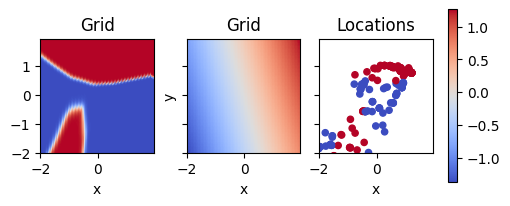

w: [-0.0721529  -0.09252103] b: 0.315812885761261
w: [0.25615367 0.1644076 ] b: 0.4354386627674103
w: [-4.1217426e-13  2.0465448e-08] b: -0.00020621319708880037
w: [0.24714828 0.8425717 ] b: -0.16466231644153595
w: [0.31233743 0.7272727 ] b: 0.8031310439109802
w: [-0.4853234   0.01978191] b: -0.42390763759613037
w: [ 0.2823361 -0.3491221] b: 0.1733040064573288
w: [ 0.35850868 -0.31898645] b: 0.2977166175842285
w: [0.19859368 0.4642391 ] b: -0.049839481711387634
w: [ 0.4029153 -0.7392317] b: -0.4280930757522583
w: [-0.45461097  0.31850943] b: 0.5080374479293823
w: [0.2847813 0.7966087] b: -0.08966954797506332
w: [ 0.0291979  -0.57515746] b: -0.057375818490982056
w: [-0.38484848 -0.66316855] b: 0.03191429004073143
w: [0.3878233  0.67075586] b: 0.5914239287376404
w: [-0.6887292   0.40749717] b: -0.11130765080451965
w: [7.625341e-39 2.416909e-38] b: -0.00011430151062086225
w: [-0.14791723 -0.7467893 ] b: 0.7620280385017395
w: [-0.10576034 -0.48308486] b: 0.12870705127716064
w: [-0.3782607 

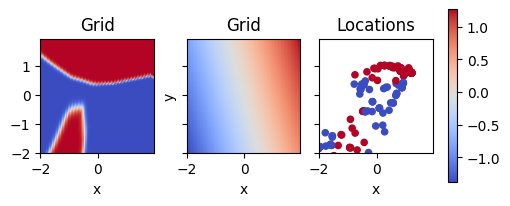

w: [-0.07178326 -0.09260314] b: 0.31595632433891296
w: [0.25710034 0.16463774] b: 0.43548789620399475
w: [-1.2292082e-13  1.0179988e-08] b: -0.00015391240594908595
w: [0.24749966 0.84317833] b: -0.16486826539039612
w: [0.3127437  0.72667426] b: 0.8035863637924194
w: [-0.4858852  0.0196313] b: -0.4245874285697937
w: [ 0.28276816 -0.3491183 ] b: 0.17388580739498138
w: [ 0.3590698 -0.3190909] b: 0.29800325632095337
w: [0.1989465 0.4649038] b: -0.05001836270093918
w: [ 0.40327203 -0.73942584] b: -0.42700719833374023
w: [-0.454992    0.31845242] b: 0.5079426765441895
w: [0.28512627 0.79721034] b: -0.08987288177013397
w: [ 0.02886334 -0.57522947] b: -0.05718650668859482
w: [-0.38532442 -0.66326755] b: 0.031953077763319016
w: [0.38828233 0.67022717] b: 0.5918462872505188
w: [-0.68914986  0.40744394] b: -0.11176680773496628
w: [7.625341e-39 2.416909e-38] b: -8.318304753629491e-05
w: [-0.14768346 -0.7469625 ] b: 0.7620849609375
w: [-0.10608736 -0.4832007 ] b: 0.12878471612930298
w: [-0.37867925

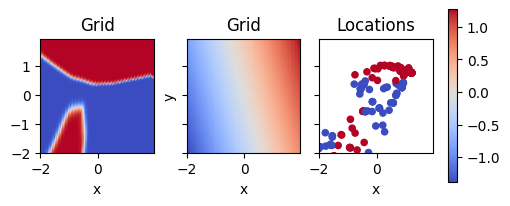

w: [-0.07155352 -0.09285796] b: 0.3161769509315491
w: [0.25786617 0.16466552] b: 0.4356841742992401
w: [-3.4556407e-14  4.9081263e-09] b: -0.00011346438259351999
w: [0.24796332 0.84385705] b: -0.1650036871433258
w: [0.31299162 0.72590107] b: 0.8041987419128418
w: [-0.48639354  0.01953692] b: -0.4253064692020416
w: [ 0.28307796 -0.34923527] b: 0.17456865310668945
w: [ 0.35956967 -0.31925777] b: 0.298299103975296
w: [0.19941857 0.46563676] b: -0.0501285158097744
w: [ 0.40356034 -0.7396682 ] b: -0.42586833238601685
w: [-0.4551964   0.31851026] b: 0.5077410340309143
w: [0.2855863  0.79788345] b: -0.09000541269779205
w: [ 0.02858773 -0.5752098 ] b: -0.057133857160806656
w: [-0.3857011 -0.6632398] b: 0.03184375539422035
w: [0.38862726 0.6695458 ] b: 0.5924423336982727
w: [-0.6894967   0.40746903] b: -0.11228122562170029
w: [7.625341e-39 2.416909e-38] b: -5.972606231807731e-05
w: [-0.14762637 -0.7472976 ] b: 0.7622114419937134
w: [-0.10634773 -0.48321706] b: 0.1287277191877365
w: [-0.37901083

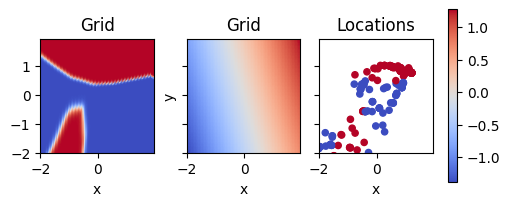

w: [-0.07120904 -0.09302847] b: 0.31635671854019165
w: [0.25871003 0.16477773] b: 0.4358174502849579
w: [-9.124832e-15  2.290098e-09] b: -8.257311856141314e-05
w: [0.24832985 0.8445374 ] b: -0.16516432166099548
w: [0.3133189 0.7251936] b: 0.8047425150871277
w: [-0.4868694   0.01948134] b: -0.4260339140892029
w: [ 0.28335047 -0.34938386] b: 0.17527401447296143
w: [ 0.36000857 -0.31949943] b: 0.2986409366130829
w: [0.19979203 0.4663726 ] b: -0.050262700766325
w: [ 0.40374884 -0.7400201 ] b: -0.4246046543121338
w: [-0.45554477  0.31838086] b: 0.5076360106468201
w: [0.2859486 0.7985579] b: -0.0901634618639946
w: [ 0.02820672 -0.5752923 ] b: -0.056997496634721756
w: [-0.3861886  -0.66331524] b: 0.03182043880224228
w: [0.38900542 0.66891885] b: 0.5929739475250244
w: [-0.68975353  0.4075593 ] b: -0.11288705468177795
w: [7.625341e-39 2.416909e-38] b: -4.228446414344944e-05
w: [-0.14742525 -0.74755627] b: 0.7622939348220825
w: [-0.10671545 -0.48333344] b: 0.1287553608417511
w: [-0.37943628 -0.6

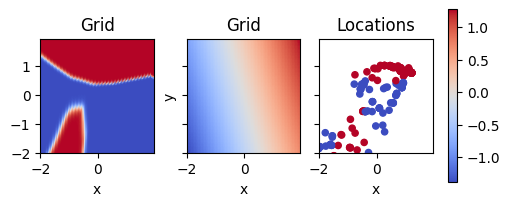

w: [-0.07081957 -0.09310264] b: 0.31642967462539673
w: [0.25966236 0.1650118 ] b: 0.4357726275920868
w: [-2.2542660e-15  1.0324005e-09] b: -5.928763857809827e-05
w: [0.24867086 0.8451592 ] b: -0.16534936428070068
w: [0.31392512 0.72483915] b: 0.8049545288085938
w: [-0.48757982  0.01917488] b: -0.4265483617782593
w: [ 0.2839056 -0.3492632] b: 0.1758212000131607
w: [ 0.36068347 -0.31948653] b: 0.2989397644996643
w: [0.2001283 0.467059 ] b: -0.05041539669036865
w: [ 0.4042697 -0.7399964] b: -0.42373237013816833
w: [-0.45587564  0.3183983 ] b: 0.5075677633285522
w: [0.2862827  0.79917514] b: -0.09034526348114014
w: [ 0.02792309 -0.57530046] b: -0.05674692243337631
w: [-0.38662657 -0.6633615 ] b: 0.03192038834095001
w: [0.3896795 0.6686566] b: 0.5931400060653687
w: [-0.69036335  0.40730977] b: -0.1131376400589943
w: [7.625341e-39 2.416909e-38] b: -2.9499484298867173e-05
w: [-0.1471555  -0.74773765] b: 0.7622758746147156
w: [-0.10700184 -0.4833913 ] b: 0.12890514731407166
w: [-0.37978894 -0.

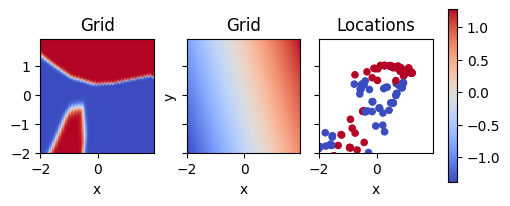

w: [-0.07058604 -0.09332192] b: 0.31662872433662415
w: [0.26037323 0.16505796] b: 0.4359511435031891
w: [-5.1879392e-16  4.4888981e-10] b: -4.197376983938739e-05
w: [0.24911387 0.8458281 ] b: -0.16545911133289337
w: [0.31424445 0.7241827 ] b: 0.8054446578025818
w: [-0.48814648  0.01902082] b: -0.42716893553733826
w: [ 0.2842129  -0.34937486] b: 0.17660774290561676
w: [ 0.36123022 -0.3197195 ] b: 0.29916834831237793
w: [0.20057699 0.46778357] b: -0.05050013214349747
w: [ 0.4045708  -0.74023855] b: -0.4225994646549225
w: [-0.45602533  0.31834492] b: 0.5073599219322205
w: [0.2867212  0.79983884] b: -0.09045183658599854
w: [ 0.02765477 -0.57529676] b: -0.05666583031415939
w: [-0.38697794 -0.6633428 ] b: 0.03182826191186905
w: [0.3900932 0.6680912] b: 0.5936052203178406
w: [-0.69076324  0.4072725 ] b: -0.11359796673059464
w: [7.625341e-39 2.416909e-38] b: -2.026660877163522e-05
w: [-0.14707898 -0.74804145] b: 0.7623791694641113
w: [-0.1072528  -0.48342034] b: 0.1288791000843048
w: [-0.38007

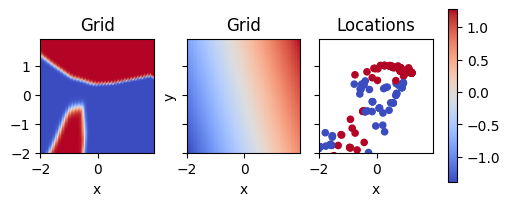

w: [-0.07028749 -0.09341628] b: 0.31679102778434753
w: [0.26119676 0.16517873] b: 0.43601787090301514
w: [-1.1069472e-16  1.8789779e-10] b: -2.928254434664268e-05
w: [0.24962847 0.84632325] b: -0.16572996973991394
w: [0.3146194  0.72363037] b: 0.8058604001998901
w: [-0.48862198  0.01894443] b: -0.42786651849746704
w: [ 0.28457007 -0.34943378] b: 0.1771758794784546
w: [ 0.36170614 -0.31986248] b: 0.29947933554649353
w: [0.20109138 0.4683399 ] b: -0.05074124410748482
w: [ 0.40481746 -0.7404694 ] b: -0.42147067189216614
w: [-0.4563697   0.31831506] b: 0.5072802305221558
w: [0.2872307 0.8003282] b: -0.09071999788284302
w: [ 0.02729019 -0.5753365 ] b: -0.05650383234024048
w: [-0.38745943 -0.6633884 ] b: 0.03185315430164337
w: [0.3905478  0.66758215] b: 0.5939886569976807
w: [-0.6911095   0.40731633] b: -0.11406031996011734
w: [7.625341e-39 2.416909e-38] b: -1.3701956959266681e-05
w: [-0.14694884 -0.74818414] b: 0.762474775314331
w: [-0.10760912 -0.48349792] b: 0.12894392013549805
w: [-0.380

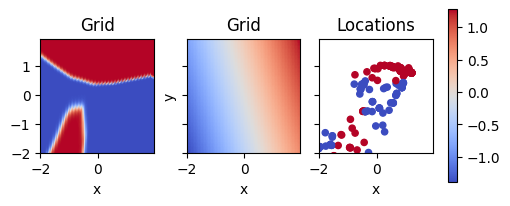

w: [-0.07003802 -0.0936242 ] b: 0.3169729709625244
w: [0.26191425 0.16521709] b: 0.4361739158630371
w: [-2.1782533e-17  7.5567316e-11] b: -2.011744254559744e-05
w: [0.25006983 0.84696245] b: -0.1658400297164917
w: [0.31492692 0.7229839 ] b: 0.8063371777534485
w: [-0.48917732  0.01879214] b: -0.4284849762916565
w: [ 0.28495428 -0.34946474] b: 0.1778191179037094
w: [ 0.3622484  -0.31996265] b: 0.2997678220272064
w: [0.2015332  0.46903816] b: -0.05082480236887932
w: [ 0.40511015 -0.7406911 ] b: -0.4203471839427948
w: [-0.45658138  0.3183856 ] b: 0.5070907473564148
w: [0.28766653 0.80096257] b: -0.09082683175802231
w: [ 0.02702474 -0.57530314] b: -0.05643153190612793
w: [-0.38782483 -0.6633535 ] b: 0.031776368618011475
w: [0.39091837 0.6669988 ] b: 0.5944598317146301
w: [-0.6915196   0.40726468] b: -0.11451304703950882
w: [7.625341e-39 2.416909e-38] b: -9.109748134505935e-06
w: [-0.1468322  -0.74845856] b: 0.7625453472137451
w: [-0.10786291 -0.48350012] b: 0.12891878187656403
w: [-0.380844

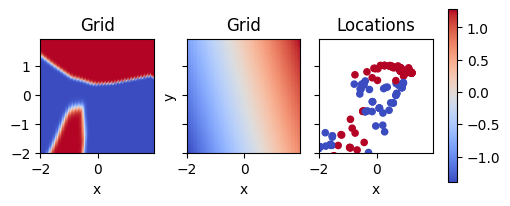

w: [-0.06966494 -0.09373236] b: 0.3170664608478546
w: [0.26274824 0.16537642] b: 0.4362179934978485
w: [-3.9298635e-18  2.9137946e-11] b: -1.3601028513221536e-05
w: [0.25047734 0.8476251 ] b: -0.16597728431224823
w: [0.31530058 0.722401  ] b: 0.8067476749420166
w: [-0.4897441  0.0186377] b: -0.42906424403190613
w: [ 0.285365   -0.34945732] b: 0.17834702134132385
w: [ 0.36280754 -0.3200809 ] b: 0.2999618351459503
w: [0.20194565 0.46975803] b: -0.050935305655002594
w: [ 0.405371  -0.7409698] b: -0.41917696595191956
w: [-0.45693254  0.31825805] b: 0.507046639919281
w: [0.28806943 0.80162024] b: -0.09096081554889679
w: [ 0.02668932 -0.57535917] b: -0.05628105252981186
w: [-0.38828632 -0.6634322 ] b: 0.0317990817129612
w: [0.391345   0.66648006] b: 0.5948618650436401
w: [-0.69189936  0.40723708] b: -0.11495786160230637
w: [7.625341e-39 2.416909e-38] b: -5.951473667664686e-06
w: [-0.14661914 -0.7486523 ] b: 0.762554943561554
w: [-0.10819243 -0.4835963 ] b: 0.12897711992263794
w: [-0.38125893

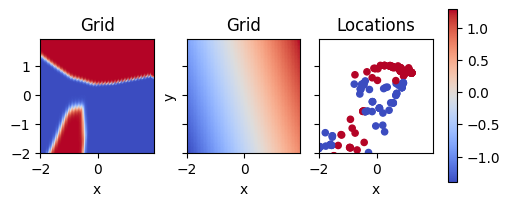

w: [-0.06943292 -0.09395356] b: 0.3172440528869629
w: [0.2634391  0.16536327] b: 0.43636664748191833
w: [-6.4572500e-19  1.0747684e-11] b: -9.042602869158145e-06
w: [0.25098234 0.84822947] b: -0.16611461341381073
w: [0.3156478 0.7218201] b: 0.807163417339325
w: [-0.49026603  0.01851325] b: -0.4296947419643402
w: [ 0.28569984 -0.3495409 ] b: 0.17904633283615112
w: [ 0.36333176 -0.32024658] b: 0.30022600293159485
w: [0.2024516  0.47042242] b: -0.05104508623480797
w: [ 0.4056553 -0.741146 ] b: -0.4180995523929596
w: [-0.45710096  0.31836697] b: 0.5068511366844177
w: [0.2885699 0.8022197] b: -0.09109469503164291
w: [ 0.02640835 -0.57530606] b: -0.056197479367256165
w: [-0.3886561  -0.66336536] b: 0.031732071191072464
w: [0.39177623 0.66596633] b: 0.5952577590942383
w: [-0.69229114  0.4072086 ] b: -0.11538992822170258
w: [7.625341e-39 2.416909e-38] b: -3.8176190173544455e-06
w: [-0.14655095 -0.74894017] b: 0.7626431584358215
w: [-0.10846087 -0.48357418] b: 0.12896613776683807
w: [-0.3815799

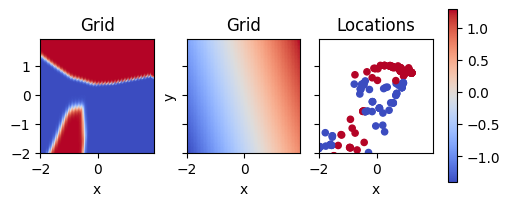

w: [-0.06908698 -0.09406002] b: 0.3174029588699341
w: [0.26423654 0.16545652] b: 0.43645304441452026
w: [-9.5903288e-20  3.7831227e-12] b: -5.907580543862423e-06
w: [0.25140312 0.84875345] b: -0.16634219884872437
w: [0.3160946 0.7213161] b: 0.8075052499771118
w: [-0.4908875   0.01829879] b: -0.43020471930503845
w: [ 0.28611246 -0.3495474 ] b: 0.17971496284008026
w: [ 0.36388692 -0.3203614 ] b: 0.30051517486572266
w: [0.20287038 0.4710083 ] b: -0.051243945956230164
w: [ 0.40596542 -0.741327  ] b: -0.4170142114162445
w: [-0.45739403  0.31829125] b: 0.5067199468612671
w: [0.28898382 0.80273825] b: -0.09131936728954315
w: [ 0.02608628 -0.57529885] b: -0.05605904385447502
w: [-0.38908714 -0.66336364] b: 0.031726233661174774
w: [0.392283  0.6655098] b: 0.5955625772476196
w: [-0.692736   0.4071297] b: -0.11576535552740097
w: [7.625341e-39 2.416909e-38] b: -2.4024166123126633e-06
w: [-0.14635758 -0.74911225] b: 0.7627333402633667
w: [-0.10877679 -0.48360315] b: 0.1290130317211151
w: [-0.381959

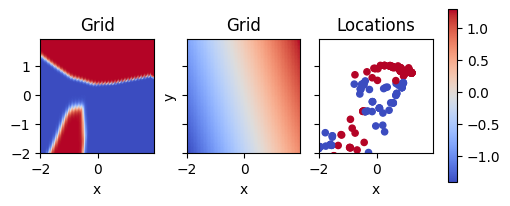

w: [-0.0687584  -0.09416947] b: 0.317510724067688
w: [0.2649898  0.16557233] b: 0.4365309178829193
w: [-1.2762924e-20  1.2674657e-12] b: -3.789447418967029e-06
w: [0.25185847 0.84938365] b: -0.16645783185958862
w: [0.31643826 0.7207314 ] b: 0.8079142570495605
w: [-0.49136367  0.01822297] b: -0.4308469593524933
w: [ 0.28644782 -0.3496048 ] b: 0.18029867112636566
w: [ 0.36434534 -0.32051402] b: 0.3008352220058441
w: [0.20332645 0.4716999 ] b: -0.05133078247308731
w: [ 0.40613675 -0.7416885 ] b: -0.4157693386077881
w: [-0.45771515  0.31813258] b: 0.5066612958908081
w: [0.28943396 0.80336404] b: -0.09143082797527313
w: [ 0.02572348 -0.5753602 ] b: -0.05593401566147804
w: [-0.38954768 -0.6634286 ] b: 0.031721342355012894
w: [0.39267862 0.66498065] b: 0.5959718823432922
w: [-0.6930453  0.4071637] b: -0.11625740677118301
w: [7.625341e-39 2.416909e-38] b: -1.4818741647104616e-06
w: [-0.1461827 -0.7492931] b: 0.7627483606338501
w: [-0.10913055 -0.48370016] b: 0.1290510892868042
w: [-0.38237655 

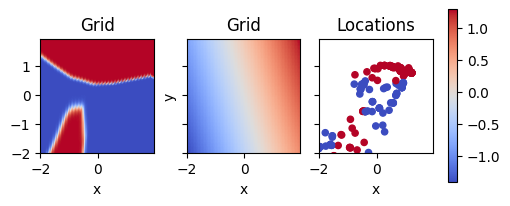

w: [-0.06842054 -0.09427042] b: 0.31765204668045044
w: [0.26576585 0.16566001] b: 0.4365977942943573
w: [-1.5065096e-21  4.0304793e-13] b: -2.3846814656280912e-06
w: [0.25230217 0.8498951 ] b: -0.16668149828910828
w: [0.31690386 0.72027594] b: 0.8082104325294495
w: [-0.49196556  0.018005  ] b: -0.4313869774341583
w: [ 0.286927  -0.3495496] b: 0.1808745115995407
w: [ 0.36495766 -0.32058087] b: 0.30103594064712524
w: [0.20376703 0.47227517] b: -0.051524534821510315
w: [ 0.40649745 -0.74180245] b: -0.4147557020187378
w: [-0.4579767   0.31818026] b: 0.5065151453018188
w: [0.28987178 0.80386966] b: -0.09165192395448685
w: [ 0.02542556 -0.5753168 ] b: -0.05580754950642586
w: [-0.3899591 -0.6634006] b: 0.031716834753751755
w: [0.39320675 0.66457254] b: 0.5962332487106323
w: [-0.69354904  0.4070201 ] b: -0.11654457449913025
w: [7.625341e-39 2.416909e-38] b: -8.951207632890146e-07
w: [-0.14599706 -0.7494589 ] b: 0.7628223896026611
w: [-0.10942454 -0.48369455] b: 0.12909260392189026
w: [-0.38273

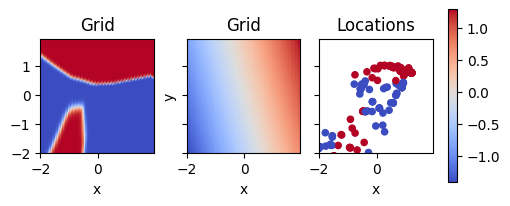

w: [-0.06815743 -0.09451466] b: 0.31781309843063354
w: [0.26639268 0.16562924] b: 0.43676862120628357
w: [-1.5582098e-22  1.2128288e-13] b: -1.4709308970850543e-06
w: [0.25274122 0.85057133] b: -0.16672174632549286
w: [0.31719846 0.7196434 ] b: 0.8086512088775635
w: [-0.49229524  0.01806956] b: -0.4322020709514618
w: [ 0.2871535 -0.3497466] b: 0.18160560727119446
w: [ 0.36533043 -0.32086003] b: 0.30143266916275024
w: [0.20420958 0.47300938] b: -0.0515398234128952
w: [ 0.4065901 -0.742221 ] b: -0.4134449362754822
w: [-0.4581863   0.31816706] b: 0.5063424110412598
w: [0.29030567 0.80454165] b: -0.09168773889541626
w: [ 0.02506324 -0.57533735] b: -0.05574518442153931
w: [-0.39036688 -0.6633805 ] b: 0.03162766247987747
w: [0.39354965 0.6639915 ] b: 0.5966846346855164
w: [-0.6937762   0.40713343] b: -0.11712821573019028
w: [7.625341e-39 2.416909e-38] b: -5.289782620820915e-07
w: [-0.14585668 -0.74974394] b: 0.7628633975982666
w: [-0.10976801 -0.48374003] b: 0.12906624376773834
w: [-0.383094

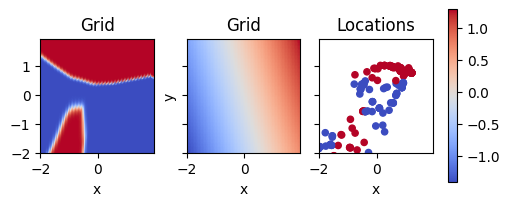

w: [-0.06783364 -0.09465206] b: 0.3179035186767578
w: [0.26709583 0.16570589] b: 0.43685707449913025
w: [-1.3914842e-23  3.4422579e-14] b: -8.88508907337382e-07
w: [0.25317407 0.85124403] b: -0.16676679253578186
w: [0.31752375 0.7190685 ] b: 0.8090419769287109
w: [-0.4929311   0.01784054] b: -0.4326971471309662
w: [ 0.28765684 -0.3496608 ] b: 0.18207289278507233
w: [ 0.36594844 -0.32086605] b: 0.301621675491333
w: [0.2046382  0.47374642] b: -0.05155579373240471
w: [ 0.40687656 -0.74247694] b: -0.41227105259895325
w: [-0.45847747  0.3181392 ] b: 0.5062547922134399
w: [0.29073292 0.80521035] b: -0.09172879904508591
w: [ 0.02479878 -0.5752975 ] b: -0.05567898601293564
w: [-0.39075065 -0.6633698 ] b: 0.03158938139677048
w: [0.39392102 0.6634741 ] b: 0.5970790982246399
w: [-0.69423366  0.4070143 ] b: -0.1175130158662796
w: [7.625341e-39 2.416909e-38] b: -3.055179718103318e-07
w: [-0.14568497 -0.7499841 ] b: 0.7628608345985413
w: [-0.11002668 -0.4837385 ] b: 0.1290542483329773
w: [-0.3834353

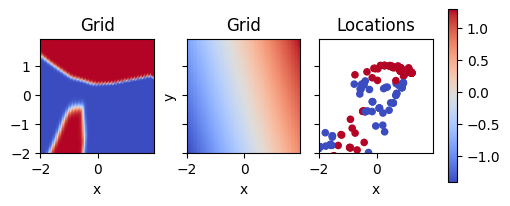

w: [-0.06742662 -0.09468827] b: 0.3179502785205841
w: [0.26791632 0.16588967] b: 0.4368423819541931
w: [-1.0529978e-24  9.1821463e-15] b: -5.250703907222487e-07
w: [0.253614  0.8518066] b: -0.16691310703754425
w: [0.31800047 0.71864146] b: 0.8092893362045288
w: [-0.4934968   0.01768101] b: -0.43325066566467285
w: [ 0.28809053 -0.34964195] b: 0.1826159656047821
w: [ 0.36647248 -0.32099724] b: 0.3019309341907501
w: [0.20507808 0.47436884] b: -0.05167606845498085
w: [ 0.4070973  -0.74278927] b: -0.41104477643966675
w: [-0.45883706  0.3180408 ] b: 0.5062121748924255
w: [0.2911671 0.8057677] b: -0.09187197685241699
w: [ 0.02439167 -0.5753873 ] b: -0.05547710880637169
w: [-0.39125866 -0.66346955] b: 0.03166273981332779
w: [0.3944411 0.6630858] b: 0.5973151326179504
w: [-0.6946287   0.40697333] b: -0.1179322600364685
w: [7.625341e-39 2.416909e-38] b: -1.7227060311597597e-07
w: [-0.14542888 -0.7500676 ] b: 0.7628244161605835
w: [-0.11042836 -0.48386592] b: 0.12917499244213104
w: [-0.3839041  -

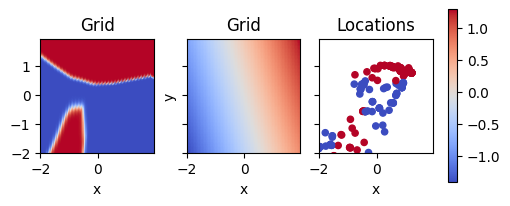

w: [-0.06721484 -0.09480207] b: 0.3181937038898468
w: [0.26854172 0.16591236] b: 0.4370117485523224
w: [-6.589002e-26  2.293071e-15] b: -3.0326049227369367e-07
w: [0.25420207 0.85220885] b: -0.16723164916038513
w: [0.3183215  0.71808904] b: 0.8096858859062195
w: [-0.49406093  0.01751143] b: -0.433834046125412
w: [ 0.2885168  -0.34963924] b: 0.18328429758548737
w: [ 0.36705947 -0.32109597] b: 0.3021840751171112
w: [0.20566238 0.47483537] b: -0.05196348950266838
w: [ 0.4073895  -0.74303055] b: -0.40989333391189575
w: [-0.45897874  0.31803563] b: 0.5059830546379089
w: [0.29174933 0.80616456] b: -0.0921870768070221
w: [ 0.02413861 -0.57532054] b: -0.055433813482522964
w: [-0.39159083 -0.66339976] b: 0.03157006949186325
w: [0.39484203 0.6625582 ] b: 0.5976709127426147
w: [-0.69511527  0.40688518] b: -0.11821432411670685
w: [7.625341e-39 2.416909e-38] b: -9.472577744418231e-08
w: [-0.14540382 -0.7502094 ] b: 0.7630228400230408
w: [-0.11067007 -0.48383176] b: 0.12913694977760315
w: [-0.384205

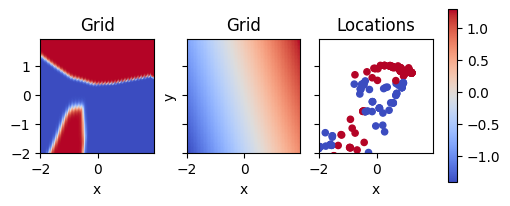

w: [-0.06678196 -0.09491146] b: 0.31823429465293884
w: [0.26931205 0.16603985] b: 0.4370395541191101
w: [-3.294167e-27  5.338461e-16] b: -1.709975236963146e-07
w: [0.25450227 0.8529019 ] b: -0.16726121306419373
w: [0.31873766 0.7175825 ] b: 0.8099880218505859
w: [-0.49460497  0.0173663 ] b: -0.4344130754470825
w: [ 0.28899592 -0.34957322] b: 0.18377627432346344
w: [ 0.367632  -0.3211626] b: 0.3024168014526367
w: [0.20596422 0.4755881 ] b: -0.051968201994895935
w: [ 0.40762305 -0.7433493 ] b: -0.408668577671051
w: [-0.4593189   0.31797916] b: 0.5059173107147217
w: [0.29204324 0.8068536 ] b: -0.09221305698156357
w: [ 0.02379774 -0.57535225] b: -0.05530332028865814
w: [-0.3920375  -0.66344935] b: 0.03158637881278992
w: [0.395276  0.6621017] b: 0.5979779958724976
w: [-0.6955244  0.4067917] b: -0.11861646175384521
w: [7.625341e-39 2.416909e-38] b: -5.0732690937138614e-08
w: [-0.14508988 -0.75039244] b: 0.7629594206809998
w: [-0.11100616 -0.48390248] b: 0.12919117510318756
w: [-0.38460174 -0

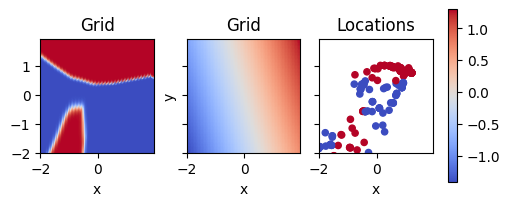

w: [-0.06648996 -0.09507613] b: 0.3184193968772888
w: [0.26994187 0.16604295] b: 0.4372021555900574
w: [-1.2480481e-28  1.1532040e-16] b: -9.402577205719354e-08
w: [0.2549428  0.85347253] b: -0.16741971671581268
w: [0.31905463 0.7169839 ] b: 0.8103958964347839
w: [-0.49498612  0.01737284] b: -0.43515560030937195
w: [ 0.28927726 -0.3497014 ] b: 0.18450897932052612
w: [ 0.368054   -0.32140407] b: 0.30278417468070984
w: [0.20640413 0.47622117] b: -0.05209798365831375
w: [ 0.40770832 -0.74380434] b: -0.40729382634162903
w: [-0.45952633  0.31801304] b: 0.5057123303413391
w: [0.29247832 0.80741966] b: -0.09236788749694824
w: [ 0.02344063 -0.5753635 ] b: -0.055244289338588715
w: [-0.39244795 -0.6634338 ] b: 0.03150735795497894
w: [0.39563772 0.661537  ] b: 0.5983749032020569
w: [-0.69580203  0.40685362] b: -0.11910766363143921
w: [7.625341e-39 2.416909e-38] b: -2.6431488109324164e-08
w: [-0.14493838 -0.75059456] b: 0.7630612850189209
w: [-0.11134903 -0.4839419 ] b: 0.12917077541351318
w: [-0.

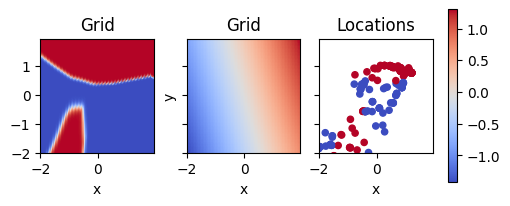

w: [-0.06614098 -0.09517001] b: 0.3185047209262848
w: [0.2706488  0.16613138] b: 0.4372637867927551
w: [-3.2544184e-30  2.2994996e-17] b: -5.0357837011461015e-08
w: [0.25541112 0.8540648 ] b: -0.16754508018493652
w: [0.31943426 0.71646446] b: 0.8107215166091919
w: [-0.49559614  0.01716408] b: -0.43565991520881653
w: [ 0.28979042 -0.34959316] b: 0.18497534096240997
w: [ 0.36868805 -0.32143176] b: 0.3029317855834961
w: [0.20687176 0.47687584] b: -0.05219528079032898
w: [ 0.40797427 -0.744087  ] b: -0.40608152747154236
w: [-0.45978925  0.3179825 ] b: 0.5056142807006836
w: [0.29294115 0.808008  ] b: -0.09248905628919601
w: [ 0.02315226 -0.57533664] b: -0.05515415221452713
w: [-0.3928518  -0.66343874] b: 0.03149501606822014
w: [0.3960617  0.66104734] b: 0.5986972451210022
w: [-0.6962706   0.40673366] b: -0.11942768841981888
w: [7.625341e-39 2.416909e-38] b: -1.3377926322277744e-08
w: [-0.14476867 -0.7507567 ] b: 0.7630754709243774
w: [-0.11163523 -0.48395494] b: 0.12918882071971893
w: [-0.3

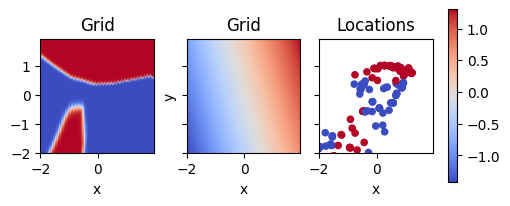

w: [-0.06576298 -0.09524363] b: 0.3185569643974304
w: [0.27136055 0.16626209] b: 0.4372991621494293
w: [-4.5506898e-32  4.2080663e-18] b: -2.6236220307396252e-08
w: [0.2557947 0.8547194] b: -0.16759435832500458
w: [0.31986132 0.71600366] b: 0.8109827637672424
w: [-0.4960748   0.01708108] b: -0.4362936317920685
w: [ 0.29014507 -0.34963354] b: 0.1856382191181183
w: [ 0.3691781  -0.32164857] b: 0.30325576663017273
w: [0.20725165 0.4775953 ] b: -0.0522158220410347
w: [ 0.4081224 -0.7445177] b: -0.4047302305698395
w: [-0.46006435  0.31786296] b: 0.5055336952209473
w: [0.29331884 0.8086588 ] b: -0.09253425151109695
w: [ 0.02277115 -0.5754181 ] b: -0.05499971657991409
w: [-0.39330614 -0.66351783] b: 0.0315188392996788
w: [0.39653215 0.66063803] b: 0.5989493727684021
w: [-0.69661784  0.40670982] b: -0.11987455189228058
w: [7.625341e-39 2.416909e-38] b: -6.568635857462368e-09
w: [-0.14452557 -0.7509054 ] b: 0.7630298137664795
w: [-0.11201055 -0.4840734 ] b: 0.1292698234319687
w: [-0.3857291 -0.

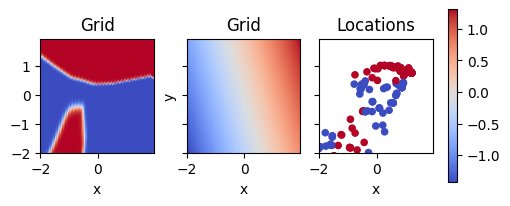

w: [-0.06550638 -0.09534697] b: 0.3186965882778168
w: [0.27199003 0.1663233 ] b: 0.4374120831489563
w: [6.4456471e-35 7.0213965e-19] b: -1.3279112032194007e-08
w: [0.25636375 0.85526437] b: -0.16773982346057892
w: [0.32019293 0.7154613 ] b: 0.8113393783569336
w: [-0.4966402   0.01691337] b: -0.43685397505760193
w: [ 0.29059577 -0.3495853 ] b: 0.18621879816055298
w: [ 0.36975417 -0.32170904] b: 0.3035375773906708
w: [0.20781638 0.47820625] b: -0.05233056843280792
w: [ 0.40835056 -0.74487543] b: -0.4034353196620941
w: [-0.4602322   0.31787664] b: 0.5053661465644836
w: [0.29388276 0.8092006 ] b: -0.09267452359199524
w: [ 0.02249512 -0.5753887 ] b: -0.054939426481723785
w: [-0.39367184 -0.66350144] b: 0.031462859362363815
w: [0.3969251  0.66012394] b: 0.5992987155914307
w: [-0.69707334  0.40661594] b: -0.12020549923181534
w: [7.625341e-39 2.416909e-38] b: -3.124139391630365e-09
w: [-0.14445539 -0.7510567 ] b: 0.7630940675735474
w: [-0.11228114 -0.48408216] b: 0.12925875186920166
w: [-0.386

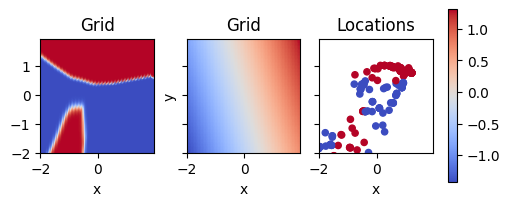

w: [-0.06514167 -0.09540629] b: 0.31882569193840027
w: [0.2726559  0.16642685] b: 0.4374881684780121
w: [9.23899817e-36 1.06033026e-19] b: -6.5201319898733345e-09
w: [0.2567193 0.8558109] b: -0.16794860363006592
w: [0.32059556 0.7150046 ] b: 0.811613917350769
w: [-0.49719995  0.0167411 ] b: -0.4374379813671112
w: [ 0.2910232  -0.34954652] b: 0.18689493834972382
w: [ 0.37032515 -0.32184526] b: 0.3038318455219269
w: [0.20816863 0.4788189 ] b: -0.05250728502869606
w: [ 0.4085746  -0.74522597] b: -0.4021157920360565
w: [-0.46043763  0.31785497] b: 0.5052075982093811
w: [0.29423136 0.8097427 ] b: -0.092880018055439
w: [ 0.02218561 -0.5754015 ] b: -0.054819006472826004
w: [-0.39405635 -0.66352373] b: 0.03145495057106018
w: [0.39736035 0.6596979 ] b: 0.599545955657959
w: [-0.6975143   0.40650526] b: -0.12054948508739471
w: [7.625341e-39 2.416909e-38] b: -1.4370268308638856e-09
w: [-0.14422636 -0.7511798 ] b: 0.7631577253341675
w: [-0.11258219 -0.48413077] b: 0.1293053925037384
w: [-0.38638484

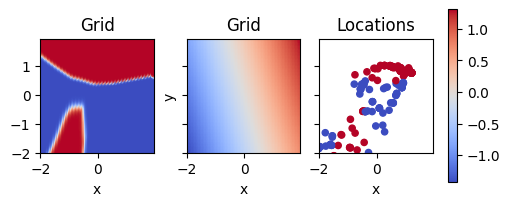

w: [-0.06485404 -0.09563351] b: 0.31900206208229065
w: [0.27319038 0.1663556 ] b: 0.4376986622810364
w: [-3.517689e-38  1.436940e-20] b: -3.101078727141271e-09
w: [0.25710964 0.85644746] b: -0.167991504073143
w: [0.3208038 0.7143206] b: 0.8120836019515991
w: [-0.49763435  0.01668652] b: -0.4380866587162018
w: [ 0.29136825 -0.34959123] b: 0.18753232061862946
w: [ 0.37081152 -0.32198396] b: 0.30407607555389404
w: [0.20856163 0.47951385] b: -0.052527014166116714
w: [ 0.40864947 -0.7457142 ] b: -0.4006858170032501
w: [-0.4606196   0.31782836] b: 0.5050064921379089
w: [0.29461566 0.81037563] b: -0.09291838854551315
w: [ 0.02191598 -0.5753242 ] b: -0.05485907942056656
w: [-0.39438355 -0.6634381 ] b: 0.03130562603473663
w: [0.39758512 0.65903705] b: 0.6000286936759949
w: [-0.6978077   0.40651944] b: -0.12103156745433807
w: [7.625341e-39 2.416909e-38] b: -6.381846162639704e-10
w: [-0.1440846 -0.7514477] b: 0.7632468938827515
w: [-0.11283816 -0.4840842 ] b: 0.1291968822479248
w: [-0.38668332 -0

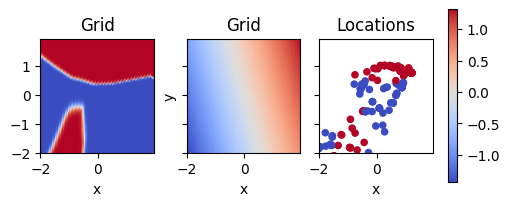

w: [-0.06457453 -0.09569481] b: 0.31911906599998474
w: [0.273831   0.16643895] b: 0.437774121761322
w: [-3.5176891e-38  1.7302349e-21] b: -1.4264247560902277e-09
w: [0.25767305 0.8569504 ] b: -0.16814394295215607
w: [0.32115966 0.71383774] b: 0.8123886585235596
w: [-0.4982771  0.0164274] b: -0.4385254681110382
w: [ 0.29190198 -0.3494483 ] b: 0.18801020085811615
w: [ 0.3714448  -0.32194453] b: 0.30429354310035706
w: [0.20911382 0.48008838] b: -0.05264618620276451
w: [ 0.40892977 -0.7460013 ] b: -0.39945876598358154
w: [-0.4608272   0.31782037] b: 0.5048788785934448
w: [0.29517385 0.81087464] b: -0.09306663274765015
w: [ 0.02164782 -0.5752673 ] b: -0.05479496344923973
w: [-0.39475214 -0.66341007] b: 0.03127017617225647
w: [0.39799693 0.65857375] b: 0.6003201603889465
w: [-0.6983255   0.40634727] b: -0.12126875668764114
w: [7.625341e-39 2.416909e-38] b: -2.731471437922295e-10
w: [-0.14397219 -0.75156045] b: 0.7632848024368286
w: [-0.11310562 -0.48406944] b: 0.12919797003269196
w: [-0.3870

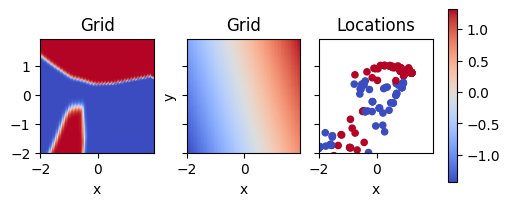

w: [-0.0641943  -0.09571259] b: 0.319187730550766
w: [0.27450368 0.16657636] b: 0.43781501054763794
w: [-3.5176891e-38  1.8294517e-22] b: -6.33478769440643e-10
w: [0.25806955 0.85747904] b: -0.16825933754444122
w: [0.3215908 0.7134163] b: 0.8126115202903748
w: [-0.4987238   0.01635818] b: -0.4391751289367676
w: [ 0.29226047 -0.34946936] b: 0.18872679769992828
w: [ 0.37193778 -0.32218266] b: 0.3046112060546875
w: [0.20950335 0.48068377] b: -0.05273354426026344
w: [ 0.40904728 -0.7464919 ] b: -0.3980378210544586
w: [-0.46105832  0.31776786] b: 0.504740297794342
w: [0.29556215 0.8113993 ] b: -0.09317809343338013
w: [ 0.02126575 -0.57535106] b: -0.05464722216129303
w: [-0.3951894 -0.6634883] b: 0.031289149075746536
w: [0.3984651  0.65818244] b: 0.6005229353904724
w: [-0.69869804  0.40630072] b: -0.12167157977819443
w: [7.625341e-39 2.416909e-38] b: -1.1245706449392046e-10
w: [-0.14372922 -0.75162095] b: 0.7632779479026794
w: [-0.11347704 -0.48418507] b: 0.1292753964662552
w: [-0.3873972  -

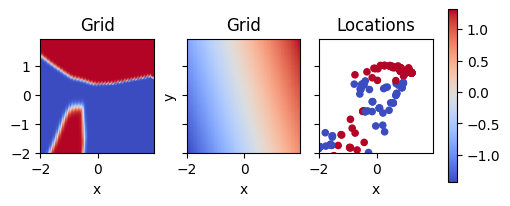

w: [-0.06379013 -0.09574607] b: 0.3192252814769745
w: [0.27520624 0.16670738] b: 0.43781551718711853
w: [-3.5176891e-38  1.6744275e-23] b: -2.7113428169300846e-10
w: [0.2584584  0.85803086] b: -0.1683773398399353
w: [0.3220408  0.71302587] b: 0.8128052353858948
w: [-0.49932814  0.01611739] b: -0.4396814703941345
w: [ 0.29283434 -0.34927127] b: 0.18919315934181213
w: [ 0.37259743 -0.32215208] b: 0.3047957420349121
w: [0.20988798 0.48130032] b: -0.05282425135374069
w: [ 0.40934822 -0.7467418 ] b: -0.3968275785446167
w: [-0.46132198  0.31771427] b: 0.5046629905700684
w: [0.29594415 0.8119461 ] b: -0.0932929590344429
w: [ 0.02096856 -0.5753317 ] b: -0.05451851338148117
w: [-0.39558613 -0.6635063 ] b: 0.03132058307528496
w: [0.39894363 0.6578151 ] b: 0.6007032990455627
w: [-0.6992313   0.40607908] b: -0.12191563844680786
w: [7.625341e-39 2.416909e-38] b: -4.444606488407388e-11
w: [-0.1434713 -0.7517088] b: 0.7632431983947754
w: [-0.11377133 -0.48420504] b: 0.12934167683124542
w: [-0.3877531

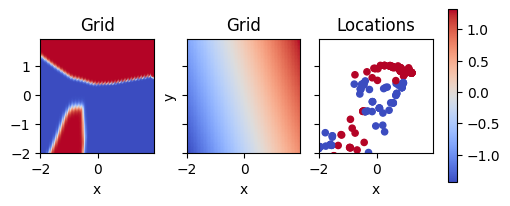

w: [-0.0635663  -0.09598202] b: 0.31942564249038696
w: [0.27568042 0.16661277] b: 0.4380227029323578
w: [-3.5176891e-38  1.3030292e-24] b: -1.1162898383432207e-10
w: [0.2589059  0.85860485] b: -0.1684591919183731
w: [0.32228804 0.7124393 ] b: 0.8131887316703796
w: [-0.4996828   0.01612639] b: -0.44040530920028687
w: [ 0.29308072 -0.34941372] b: 0.18999458849430084
w: [ 0.37302658 -0.32241532] b: 0.30511996150016785
w: [0.21033508 0.4819353 ] b: -0.05288171023130417
w: [ 0.40939122 -0.74723005] b: -0.3953954577445984
w: [-0.46140325  0.3178    ] b: 0.5043985843658447
w: [0.29638627 0.8125158 ] b: -0.09337092190980911
w: [ 0.02068188 -0.5752634 ] b: -0.05453335493803024
w: [-0.3958854 -0.6633974] b: 0.0311740655452013
w: [0.39922598 0.6572494 ] b: 0.6010818481445312
w: [-0.6995108   0.40611437] b: -0.122380830347538
w: [7.625341e-39 2.416909e-38] b: -1.682645515976855e-11
w: [-0.14338076 -0.751954  ] b: 0.7633581161499023
w: [-0.11403587 -0.48415998] b: 0.1292574256658554
w: [-0.3880123 

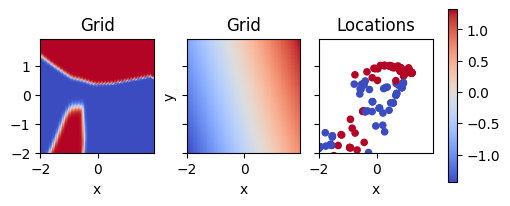

w: [-0.06313626 -0.09591512] b: 0.31944188475608826
w: [0.27637848 0.16681686] b: 0.43800538778305054
w: [-3.517689e-38  8.422181e-26] b: -4.411909032553396e-11
w: [0.259332 0.859104] b: -0.1686123013496399
w: [0.3226695 0.712013 ] b: 0.8134260773658752
w: [-0.5001609   0.01602633] b: -0.44099125266075134
w: [ 0.29357713 -0.34927896] b: 0.19039776921272278
w: [ 0.37356457 -0.3224649 ] b: 0.3053518235683441
w: [0.21075292 0.48250344] b: -0.053004417568445206
w: [ 0.40947184 -0.74780077] b: -0.39389267563819885
w: [-0.46177065  0.31755123] b: 0.5044081211090088
w: [0.29680443 0.81301135] b: -0.09352008253335953
w: [ 0.02029395 -0.5753664 ] b: -0.05438423901796341
w: [-0.39636153 -0.6635292 ] b: 0.03123866394162178
w: [0.39962608 0.656829  ] b: 0.6013138890266418
w: [-0.69987845  0.40607086] b: -0.12275980412960052
w: [7.625341e-39 2.416909e-38] b: -6.08772494220533e-12
w: [-0.14308774 -0.7519104 ] b: 0.7633059024810791
w: [-0.11442059 -0.48430327] b: 0.12934939563274384
w: [-0.38846153 -

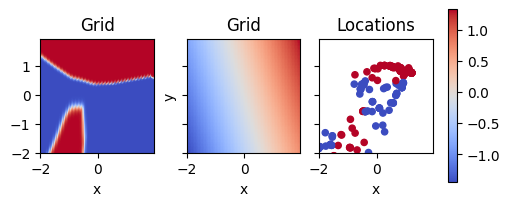

w: [-0.0627915  -0.09591813] b: 0.31944483518600464
w: [0.2770204  0.16696367] b: 0.4379890263080597
w: [-3.5176891e-38  4.3774974e-27] b: -1.6702804070400923e-11
w: [0.2598389 0.8596652] b: -0.16866721212863922
w: [0.32310042 0.71166235] b: 0.8135801553726196
w: [-0.50072896  0.01582631] b: -0.4414997696876526
w: [ 0.29405096 -0.34916276] b: 0.1909404993057251
w: [ 0.37413883 -0.32252622] b: 0.3056592643260956
w: [0.21125266 0.48313105] b: -0.05303315818309784
w: [ 0.4096688 -0.7481882] b: -0.3925396502017975
w: [-0.46198723  0.3174747 ] b: 0.504341185092926
w: [0.29730535 0.81356955] b: -0.09357058256864548
w: [ 0.01995427 -0.57541156] b: -0.05422841012477875
w: [-0.39676875 -0.663593  ] b: 0.03128759562969208
w: [0.4001014 0.6565055] b: 0.6014589071273804
w: [-0.7003527   0.40591863] b: -0.12305693328380585
w: [7.625341e-39 2.416909e-38] b: -2.0996036940307272e-12
w: [-0.14290236 -0.7519573 ] b: 0.7632281184196472
w: [-0.11475364 -0.4843865 ] b: 0.12944406270980835
w: [-0.388829 -0.

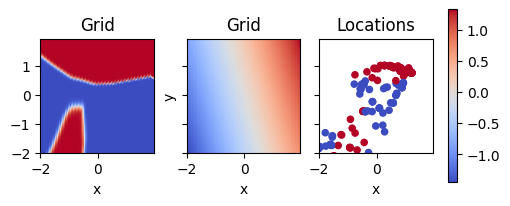

w: [-0.06247785 -0.09599847] b: 0.31954529881477356
w: [0.27758336 0.16700952] b: 0.4380793571472168
w: [-3.5176891e-38  1.7422476e-28] b: -6.043041067549382e-12
w: [0.26024756 0.86021566] b: -0.1687520146369934
w: [0.32342485 0.7111943 ] b: 0.8138561248779297
w: [-0.5013472   0.01558143] b: -0.4419497549533844
w: [ 0.2946044 -0.348997 ] b: 0.1914297491312027
w: [ 0.3747773  -0.32246298] b: 0.30589547753334045
w: [0.21165246 0.48375154] b: -0.05308813601732254
w: [ 0.40993503 -0.7485197 ] b: -0.39126676321029663
w: [-0.46215248  0.31749767] b: 0.5041850209236145
w: [0.2977063 0.8141173] b: -0.09365089982748032
w: [ 0.01972624 -0.5753313 ] b: -0.0541975237429142
w: [-0.3970742  -0.66353816] b: 0.031225815415382385
w: [0.40045175 0.65605617] b: 0.6017280220985413
w: [-0.70088404  0.4057022 ] b: -0.12327181547880173
w: [7.625341e-39 2.416909e-38] b: -6.884543391101616e-13
w: [-0.14271744 -0.7520847 ] b: 0.7632468938827515
w: [-0.11497489 -0.48434517] b: 0.12941646575927734
w: [-0.38909438

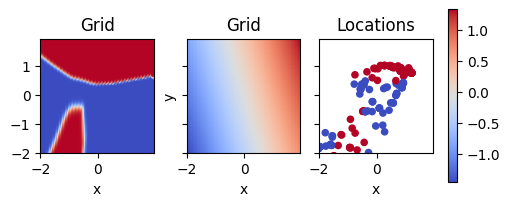

w: [-0.06216848 -0.09609535] b: 0.31965503096580505
w: [0.2781339  0.16702472] b: 0.4381782114505768
w: [-3.517689e-38  4.872089e-30] b: -2.0842121431496885e-12
w: [0.2607275  0.86068827] b: -0.1688956320285797
w: [0.32373336 0.71071297] b: 0.8141412138938904
w: [-0.501715    0.01558681] b: -0.44264113903045654
w: [ 0.29494724 -0.34903923] b: 0.19204601645469666
w: [ 0.37523845 -0.32267004] b: 0.3061567544937134
w: [0.21212812 0.48428908] b: -0.053206201642751694
w: [ 0.4099589  -0.74905217] b: -0.3897889256477356
w: [-0.46234465  0.31749183] b: 0.5040314793586731
w: [0.2981797  0.81458586] b: -0.09379108250141144
w: [ 0.01937821 -0.5753334 ] b: -0.05413781479001045
w: [-0.3974587 -0.6635272] b: 0.03118198923766613
w: [0.40078697 0.65558004] b: 0.6020072102546692
w: [-0.7011818   0.40574342] b: -0.12369798123836517
w: [7.625341e-39 2.416909e-38] b: -2.1400008230320483e-13
w: [-0.1425519 -0.7521672] b: 0.763289749622345
w: [-0.11530817 -0.4843769 ] b: 0.12941640615463257
w: [-0.3894528 

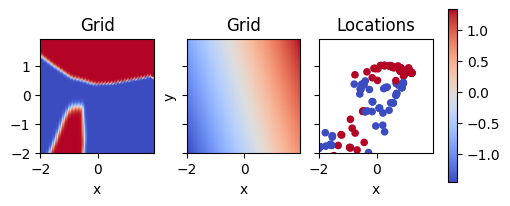

w: [-0.06196291 -0.09629314] b: 0.31982940435409546
w: [0.27855524 0.16694963] b: 0.4383820593357086
w: [-3.5176891e-38  7.7945543e-32] b: -6.834144795214714e-13
w: [0.26118815 0.8613082 ] b: -0.168899804353714
w: [0.32391787 0.7101079 ] b: 0.8145382404327393
w: [-0.5021275   0.01555364] b: -0.4432605504989624
w: [ 0.29524237 -0.34912005] b: 0.1927568018436432
w: [ 0.37569413 -0.32285663] b: 0.30647167563438416
w: [0.21258366 0.48497382] b: -0.05318441241979599
w: [ 0.4099725 -0.7496561] b: -0.3882597088813782
w: [-0.4624166   0.31753296] b: 0.5037931203842163
w: [0.29863483 0.81520355] b: -0.09378976374864578
w: [ 0.01912789 -0.5752663 ] b: -0.05418620631098747
w: [-0.3977266 -0.6634365] b: 0.031023917719721794
w: [0.40099677 0.6549903 ] b: 0.6024124622344971
w: [-0.7014778   0.40575433] b: -0.12412803620100021
w: [7.625341e-39 2.416909e-38] b: -6.286334300331653e-14
w: [-0.14247133 -0.7523906 ] b: 0.7633695006370544
w: [-0.1155385  -0.48433545] b: 0.12930740416049957
w: [-0.38968518 

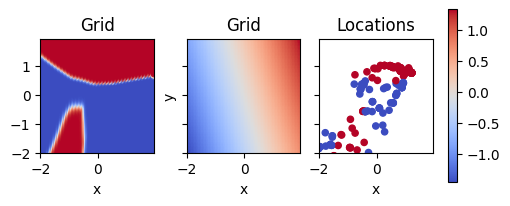

w: [-0.06156617 -0.09630927] b: 0.31986555457115173
w: [0.27918795 0.16705537] b: 0.4383963644504547
w: [-3.5176891e-38  1.3395323e-34] b: -2.1243582251379706e-13
w: [0.26158845 0.8618155 ] b: -0.1690165251493454
w: [0.324304  0.7097073] b: 0.8147424459457397
w: [-0.50267476  0.01537891] b: -0.4437546133995056
w: [ 0.29577383 -0.34896693] b: 0.1931997388601303
w: [ 0.37629184 -0.3228717 ] b: 0.3066571056842804
w: [0.21297629 0.48554936] b: -0.05327295511960983
w: [ 0.41013473 -0.75007343] b: -0.38689547777175903
w: [-0.46269238  0.31744352] b: 0.5037313103675842
w: [0.299027  0.8157072] b: -0.09390286356210709
w: [ 0.01880068 -0.57526827] b: -0.05408259853720665
w: [-0.398129   -0.66346174] b: 0.03104333020746708
w: [0.40140098 0.6545973 ] b: 0.6026094555854797
w: [-0.70191985  0.40562576] b: -0.12441300600767136
w: [7.625341e-39 2.416909e-38] b: -1.739222576179443e-14
w: [-0.1422054 -0.7524253] b: 0.7633336186408997
w: [-0.1158604 -0.4843758] b: 0.12935727834701538
w: [-0.39005738 -0.

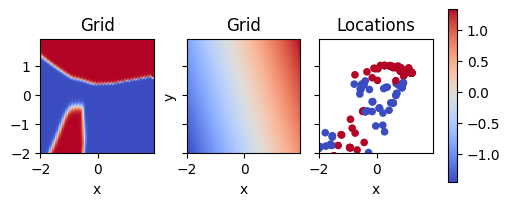

w: [-0.06119767 -0.09634463] b: 0.3199108839035034
w: [0.27980384 0.16713755] b: 0.4384213387966156
w: [-3.5176891e-38 -1.4514428e-35] b: -6.24045899590836e-14
w: [0.26201054 0.86234224] b: -0.16910962760448456
w: [0.3247101 0.7093252] b: 0.8149240612983704
w: [-0.50325805  0.01517393] b: -0.44422754645347595
w: [ 0.29629192 -0.3488294 ] b: 0.1937258094549179
w: [ 0.37689692 -0.3228945 ] b: 0.30691802501678467
w: [0.21338741 0.48614538] b: -0.05333744361996651
w: [ 0.4103391  -0.75043774] b: -0.38557299971580505
w: [-0.4629247  0.3174083] b: 0.5036334991455078
w: [0.29944122 0.81623054] b: -0.09399218112230301
w: [ 0.01848481 -0.5752483 ] b: -0.0539812333881855
w: [-0.398512   -0.66346097] b: 0.031050905585289
w: [0.40183157 0.6542283 ] b: 0.6027826070785522
w: [-0.70240104  0.40545997] b: -0.1246839314699173
w: [7.625341e-39 2.416909e-38] b: -4.515294625554497e-15
w: [-0.14196932 -0.75250113] b: 0.7633033394813538
w: [-0.11616999 -0.48439273] b: 0.12940329313278198
w: [-0.39040068 -0.

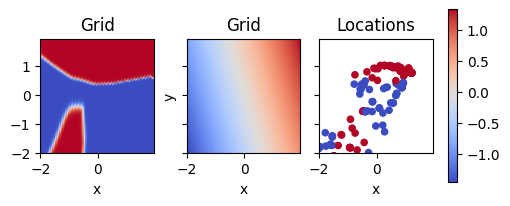

w: [-0.06091158 -0.09638263] b: 0.32000312209129333
w: [0.2803619  0.16719358] b: 0.43848419189453125
w: [-3.517689e-38 -3.045093e-39] b: -1.7265528267610027e-14
w: [0.2625927 0.8627567] b: -0.16927282512187958
w: [0.32507384 0.70892406] b: 0.8151375651359558
w: [-0.50378746  0.01501614] b: -0.4447574019432068
w: [ 0.29674023 -0.348763  ] b: 0.1943143755197525
w: [ 0.37745887 -0.32298806] b: 0.3072032332420349
w: [0.21395554 0.48663285] b: -0.053469665348529816
w: [ 0.41048455 -0.7508725 ] b: -0.3841731548309326
w: [-0.4630926  0.317378 ] b: 0.5034977197647095
w: [0.30001742 0.81664145] b: -0.09415184706449509
w: [ 0.01816543 -0.5752267 ] b: -0.053900230675935745
w: [-0.3988769 -0.6634404] b: 0.031027479097247124
w: [0.40224066 0.6538346 ] b: 0.6029792428016663
w: [-0.70285803  0.40535107] b: -0.12494469434022903
w: [7.625341e-39 2.416909e-38] b: -1.0955721074947357e-15
w: [-0.14183876 -0.7525366 ] b: 0.763328492641449
w: [-0.11647727 -0.48440486] b: 0.12942630052566528
w: [-0.39072868

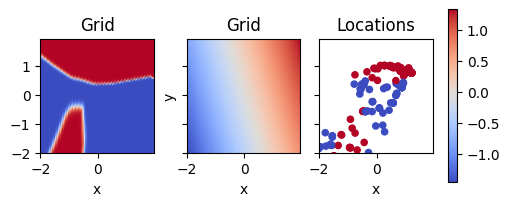

w: [-0.06064255 -0.09652813] b: 0.3201633393764496
w: [0.2808229  0.16715117] b: 0.43865036964416504
w: [-3.517689e-38  2.753286e-38] b: -4.4824653225848145e-15
w: [0.26298535 0.8632974 ] b: -0.16935954988002777
w: [0.3253049 0.7083737] b: 0.8154821991920471
w: [-0.50421685  0.01495329] b: -0.4453732669353485
w: [ 0.29712996 -0.34874424] b: 0.1949351578950882
w: [ 0.37798887 -0.32311094] b: 0.30741921067237854
w: [0.214338   0.48724276] b: -0.053526896983385086
w: [ 0.41051582 -0.7514472 ] b: -0.3826464116573334
w: [-0.46322677  0.31742144] b: 0.5032881498336792
w: [0.30040058 0.81718016] b: -0.09423317760229111
w: [ 0.01789924 -0.5751552 ] b: -0.05392257496714592
w: [-0.3991758 -0.6633634] b: 0.030910324305295944
w: [0.40248176 0.65329033] b: 0.6033257246017456
w: [-0.7031954  0.405308 ] b: -0.1253357082605362
w: [7.625341e-39 2.416909e-38] b: -2.4734222327662625e-16
w: [-0.1416653 -0.7526844] b: 0.763400137424469
w: [-0.11672844 -0.48436478] b: 0.12934932112693787
w: [-0.3909955 -0.6

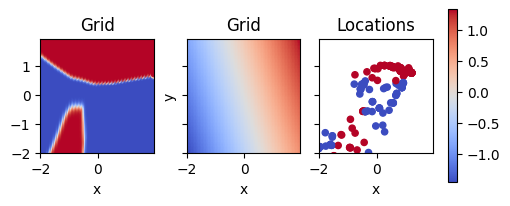

w: [-0.06026535 -0.09661876] b: 0.3202003836631775
w: [0.2813772  0.16719416] b: 0.4387151002883911
w: [-3.517689e-38  2.753286e-38] b: -1.0876231268012277e-15
w: [0.2633618  0.86392015] b: -0.1693565845489502
w: [0.32559434 0.707875  ] b: 0.8157621026039124
w: [-0.5046113   0.01493453] b: -0.4460417330265045
w: [ 0.29754165 -0.34869882] b: 0.19543807208538055
w: [ 0.378489   -0.32323793] b: 0.30765411257743835
w: [0.21471503 0.4879264 ] b: -0.05350237339735031
w: [ 0.41048926 -0.752101  ] b: -0.3810224235057831
w: [-0.4634694   0.31733447] b: 0.5032044649124146
w: [0.3007717 0.8178001] b: -0.09422625601291656
w: [ 0.01755393 -0.57517415] b: -0.05386338010430336
w: [-0.39956394 -0.66338575] b: 0.03088347055017948
w: [0.40277848 0.6527958 ] b: 0.6036161780357361
w: [-0.7034845  0.4053183] b: -0.1257825493812561
w: [7.625341e-39 2.416909e-38] b: -5.170545536030141e-17
w: [-0.14141005 -0.75277996] b: 0.7633501887321472
w: [-0.11705967 -0.48441634] b: 0.1293542981147766
w: [-0.3913632 -0.6

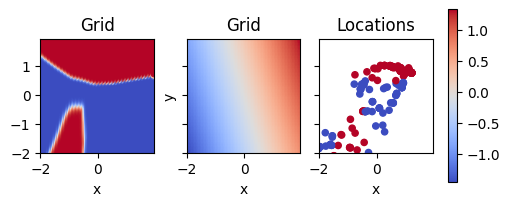

w: [-0.05985187 -0.09652521] b: 0.3201734721660614
w: [0.28204986 0.1673977 ] b: 0.43864673376083374
w: [-3.517689e-38  2.753286e-38] b: -2.4555180738436747e-16
w: [0.26382256 0.8643882 ] b: -0.16947194933891296
w: [0.32608646 0.7076124 ] b: 0.815829873085022
w: [-0.505265    0.01464589] b: -0.4464397132396698
w: [ 0.29812294 -0.3484668 ] b: 0.19591550529003143
w: [ 0.37912285 -0.3232113 ] b: 0.30798444151878357
w: [0.2151593  0.48846972] b: -0.053586095571517944
w: [ 0.41071802 -0.75250125] b: -0.37964531779289246
w: [-0.46373102  0.3172085 ] b: 0.5031725168228149
w: [0.301224  0.8182657] b: -0.09433770179748535
w: [ 0.01718831 -0.5752334 ] b: -0.053674787282943726
w: [-0.3999972 -0.6634775] b: 0.030975934118032455
w: [0.4033064  0.65255165] b: 0.6036623120307922
w: [-0.7040463   0.40506423] b: -0.1259578913450241
w: [7.625341e-39 2.416909e-38] b: -9.95401107723548e-18
w: [-0.14113322 -0.7527231 ] b: 0.7632521390914917
w: [-0.11741979 -0.48451626] b: 0.12948881089687347
w: [-0.3917520

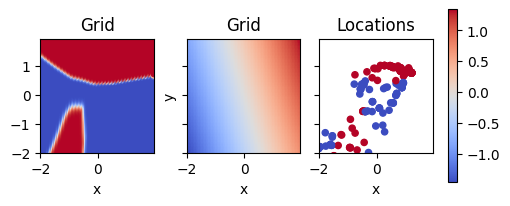

w: [-0.05958825 -0.09672892] b: 0.3203214704990387
w: [0.28248426 0.1673121 ] b: 0.43881410360336304
w: [-3.517689e-38  2.753286e-38] b: -5.1332152058578676e-17
w: [0.26418954 0.8649736 ] b: -0.16948935389518738
w: [0.3263481 0.707095 ] b: 0.8161291480064392
w: [-0.5056613   0.01461064] b: -0.44710180163383484
w: [ 0.29842034 -0.3485432 ] b: 0.19667460024356842
w: [ 0.37960654 -0.3234568 ] b: 0.3082658052444458
w: [0.21552406 0.4891178 ] b: -0.05358094349503517
w: [ 0.41072604 -0.75305885] b: -0.37810221314430237
w: [-0.46380708  0.31728682] b: 0.5029348134994507
w: [0.30158344 0.8188491 ] b: -0.09435051679611206
w: [ 0.01691158 -0.5751532 ] b: -0.05368669331073761
w: [-0.4002749 -0.6633715] b: 0.03084954246878624
w: [0.4035816 0.6520456] b: 0.6039620041847229
w: [-0.70435846  0.40503618] b: -0.12637223303318024
w: [7.625341e-39 2.416909e-38] b: -1.754057375229162e-18
w: [-0.1409738 -0.752922 ] b: 0.7633097171783447
w: [-0.11767578 -0.484464  ] b: 0.12941968441009521
w: [-0.39199665 -0

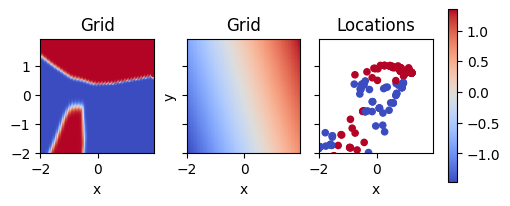

w: [-0.05923653 -0.09674751] b: 0.32032665610313416
w: [0.28304315 0.16740562] b: 0.4388411343097687
w: [-3.517689e-38  2.753286e-38] b: -9.88234580332511e-18
w: [0.26468042 0.86557865] b: -0.16947032511234283
w: [0.3266558  0.70664626] b: 0.8163682818412781
w: [-0.506157    0.01448351] b: -0.4476487636566162
w: [ 0.29896027 -0.3483539 ] b: 0.197038471698761
w: [ 0.38018373 -0.32340628] b: 0.3085084855556488
w: [0.21600595 0.489791  ] b: -0.05353594198822975
w: [ 0.41077706 -0.75368017] b: -0.37651512026786804
w: [-0.46405306  0.31716293] b: 0.502888560295105
w: [0.302069  0.8194536] b: -0.0943257063627243
w: [ 0.01659116 -0.57516134] b: -0.05362141132354736
w: [-0.40065858 -0.6634102 ] b: 0.03084395080804825
w: [0.403903  0.6516017] b: 0.6042137742042542
w: [-0.7047645   0.40492633] b: -0.12668676674365997
w: [7.625341e-39 2.416909e-38] b: -2.809906949942434e-19
w: [-0.14075573 -0.75296414] b: 0.7632246613502502
w: [-0.1179878 -0.4845107] b: 0.12943711876869202
w: [-0.3923615  -0.6132

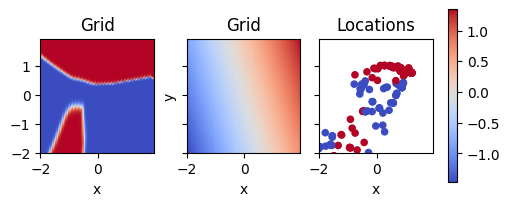

w: [-0.05895392 -0.09683932] b: 0.3204529583454132
w: [0.2835205 0.1674012] b: 0.4389471113681793
w: [-3.517689e-38  2.753286e-38] b: -1.7414683066915645e-18
w: [0.2651046  0.86603814] b: -0.16961264610290527
w: [0.32698274 0.7062382 ] b: 0.8165819644927979
w: [-0.50666744  0.01434341] b: -0.44818633794784546
w: [ 0.2993622  -0.34832916] b: 0.19772663712501526
w: [ 0.3807732  -0.32359886] b: 0.30869928002357483
w: [0.21641703 0.49032292] b: -0.05364779382944107
w: [ 0.41088444 -0.7541619 ] b: -0.3750472366809845
w: [-0.46416804  0.317165  ] b: 0.5027027130126953
w: [0.3024841 0.8199106] b: -0.0944644883275032
w: [ 0.01630779 -0.57510644] b: -0.0535782091319561
w: [-0.40095925 -0.6633469 ] b: 0.030778100714087486
w: [0.40425456 0.6512023 ] b: 0.6044096946716309
w: [-0.70520157  0.4048044 ] b: -0.12695665657520294
w: [7.625341e-39 2.416909e-38] b: -4.0601326724204275e-20
w: [-0.14058577 -0.7530594 ] b: 0.7632811665534973
w: [-0.11825342 -0.48448595] b: 0.12942473590373993
w: [-0.39262238

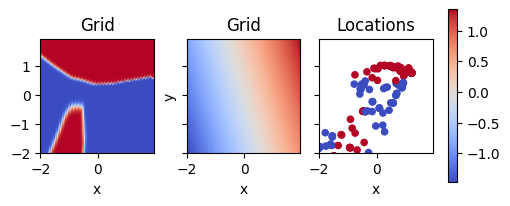

w: [-0.05866145 -0.09688695] b: 0.32050856947898865
w: [0.2840207  0.16745561] b: 0.4390147626399994
w: [-3.517689e-38  2.753286e-38] b: -2.7898095629846927e-19
w: [0.2656271 0.8665666] b: -0.16963842511177063
w: [0.32724425 0.7057719 ] b: 0.8168436288833618
w: [-0.5070972   0.01428161] b: -0.448782354593277
w: [ 0.29982442 -0.34822243] b: 0.1981787085533142
w: [ 0.38127494 -0.32360873] b: 0.30904388427734375
w: [0.21692613 0.4909216 ] b: -0.053647175431251526
w: [ 0.4108796 -0.7548394] b: -0.373413622379303
w: [-0.464362    0.31709555] b: 0.502602219581604
w: [0.30299988 0.82043755] b: -0.09448560327291489
w: [ 0.01600185 -0.57510304] b: -0.053539857268333435
w: [-0.40130705 -0.66335607] b: 0.03073953278362751
w: [0.40453005 0.6507349 ] b: 0.6046795845031738
w: [-0.7055607   0.40475816] b: -0.12730218470096588
w: [7.625341e-39 2.416909e-38] b: -5.243893721821446e-21
w: [-0.14041586 -0.7530963 ] b: 0.7632472515106201
w: [-0.11854931 -0.48452008] b: 0.12941737473011017
w: [-0.39295214 -

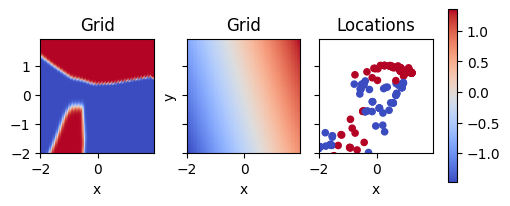

w: [-0.05832381 -0.09689596] b: 0.32054510712623596
w: [0.2845664 0.167531 ] b: 0.4390294849872589
w: [-3.517689e-38  2.753286e-38] b: -4.0312017073789586e-20
w: [0.26613307 0.8669996 ] b: -0.1697782427072525
w: [0.3276165 0.7054346] b: 0.8169897198677063
w: [-0.5076482   0.01409222] b: -0.4492383897304535
w: [ 0.30034158 -0.34806985] b: 0.19864855706691742
w: [ 0.38188076 -0.3236353 ] b: 0.3092571794986725
w: [0.21741736 0.49142787] b: -0.05375683307647705
w: [ 0.41102436 -0.7552769 ] b: -0.3720090687274933
w: [-0.46455535  0.31704882] b: 0.5025141835212708
w: [0.30349812 0.82086813] b: -0.09462188184261322
w: [ 0.01568993 -0.5750849 ] b: -0.053445037454366684
w: [-0.4016641 -0.6633542] b: 0.03074934519827366
w: [0.4049264 0.650401 ] b: 0.6048129200935364
w: [-0.70603704  0.40459907] b: -0.127499520778656
w: [7.625341e-39 2.416909e-38] b: -5.989814542455901e-22
w: [-0.14021899 -0.753103  ] b: 0.7632235288619995
w: [-0.11884955 -0.48453644] b: 0.1294626146554947
w: [-0.3932826 -0.61316

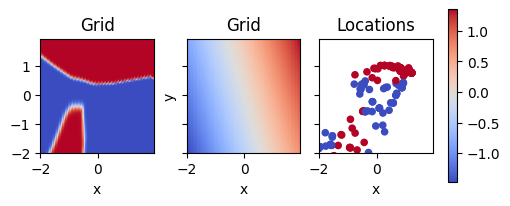

w: [-0.05801124 -0.09698244] b: 0.32063883543014526
w: [0.28506353 0.16753492] b: 0.4391084313392639
w: [-3.517689e-38  2.753286e-38] b: -5.2066891735086e-21
w: [0.26651105 0.8674781 ] b: -0.169871985912323
w: [0.3279719 0.7050575] b: 0.8171665668487549
w: [-0.50811046  0.01398565] b: -0.44980213046073914
w: [ 0.30071595 -0.34806368] b: 0.19933345913887024
w: [ 0.38238448 -0.3238181 ] b: 0.3096030652523041
w: [0.21778193 0.49197918] b: -0.0538216196000576
w: [ 0.41108248 -0.75578475] b: -0.37050557136535645
w: [-0.46470085  0.31708148] b: 0.5023460984230042
w: [0.30386567 0.821344  ] b: -0.0947122648358345
w: [ 0.01536963 -0.57504994] b: -0.05338134244084358
w: [-0.4019965 -0.6633087] b: 0.03070797398686409
w: [0.40529826 0.6500343 ] b: 0.6049767732620239
w: [-0.706421    0.40450242] b: -0.12781701982021332
w: [7.625341e-39 2.416909e-38] b: -5.974247476896632e-23
w: [-0.1399988  -0.75319004] b: 0.7632396221160889
w: [-0.11915357 -0.48453134] b: 0.12947408854961395
w: [-0.39357793 -0.61

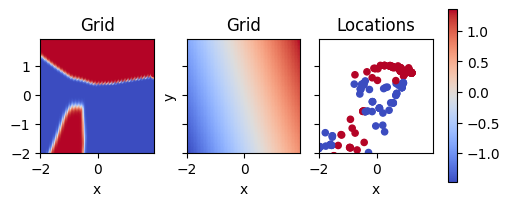

w: [-0.05768291 -0.09703407] b: 0.32066062092781067
w: [0.2856057  0.16759536] b: 0.4391236901283264
w: [-3.517689e-38  2.753286e-38] b: -5.947516956677654e-22
w: [0.26702604 0.8680215 ] b: -0.16993291676044464
w: [0.32833114 0.7046943 ] b: 0.8173271417617798
w: [-0.50861967  0.01383141] b: -0.45032623410224915
w: [ 0.30123764 -0.3478994 ] b: 0.19978395104408264
w: [ 0.383009  -0.3238556] b: 0.30976176261901855
w: [0.21828423 0.49259353] b: -0.053852733224630356
w: [ 0.4111888 -0.7562697] b: -0.369020015001297
w: [-0.46490738  0.31703424] b: 0.5022739768028259
w: [0.3043748  0.82188666] b: -0.09476850181818008
w: [ 0.01505342 -0.5750229 ] b: -0.0532967746257782
w: [-0.40235978 -0.66330224] b: 0.030713127925992012
w: [0.40568247 0.64967597] b: 0.6051329970359802
w: [-0.70686847  0.4043532 ] b: -0.12804634869098663
w: [7.625341e-39 2.416909e-38] b: -5.122243857125105e-24
w: [-0.13979962 -0.7532425 ] b: 0.7631855607032776
w: [-0.11946169 -0.4845429 ] b: 0.1295124739408493
w: [-0.39391837 

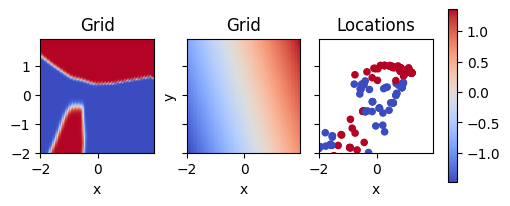

w: [-0.05737739 -0.09707628] b: 0.32071542739868164
w: [0.28611156 0.16764034] b: 0.43916457891464233
w: [-3.517689e-38  2.753286e-38] b: -5.93228260109377e-23
w: [0.26754197 0.8684577 ] b: -0.1700620949268341
w: [0.3286374  0.70430744] b: 0.8175206184387207
w: [-0.5090899   0.01371487] b: -0.45086705684661865
w: [ 0.30172914 -0.34776244] b: 0.20021961629390717
w: [ 0.38356298 -0.32386708] b: 0.31001782417297363
w: [0.21878527 0.49310395] b: -0.053950827568769455
w: [ 0.4112337 -0.7568026] b: -0.36749354004859924
w: [-0.46510407  0.31698442] b: 0.5021881461143494
w: [0.30488276 0.82232136] b: -0.09489350020885468
w: [ 0.01474188 -0.5749952 ] b: -0.05322965979576111
w: [-0.4027103 -0.663288 ] b: 0.030703214928507805
w: [0.40600199 0.6492838 ] b: 0.6053249835968018
w: [-0.7072665   0.40426046] b: -0.1283140480518341
w: [7.625341e-39 2.416909e-38] b: -3.7007730573829845e-25
w: [-0.13961422 -0.7532532 ] b: 0.7631683349609375
w: [-0.11976186 -0.4845525 ] b: 0.12953349947929382
w: [-0.394251

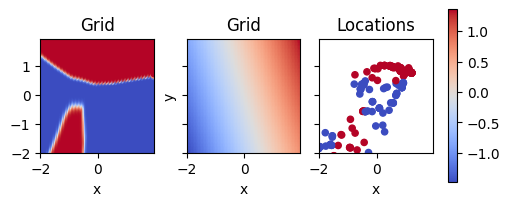

w: [-0.05711074 -0.09729142] b: 0.3208545744419098
w: [0.2865037  0.16752179] b: 0.4393405020236969
w: [-3.517689e-38  2.753286e-38] b: -5.086478086973742e-24
w: [0.26784593 0.8690776 ] b: -0.17002706229686737
w: [0.32884717 0.70377517] b: 0.8178327679634094
w: [-0.5096227   0.01354468] b: -0.4513454735279083
w: [ 0.30220872 -0.34766567] b: 0.20078706741333008
w: [ 0.38417748 -0.3238659 ] b: 0.31021422147750854
w: [0.21908334 0.49378914] b: -0.05389311537146568
w: [ 0.41135317 -0.7572628 ] b: -0.3660501539707184
w: [-0.46518534  0.3170526 ] b: 0.501971960067749
w: [0.3051778 0.8229403] b: -0.09485432505607605
w: [ 0.0145631  -0.57481974] b: -0.05330326408147812
w: [-0.40292078 -0.66312003] b: 0.03054841049015522
w: [0.40621004 0.6487564 ] b: 0.6056429147720337
w: [-0.70769924  0.4040879 ] b: -0.12858235836029053
w: [7.625341e-39 2.416909e-38] b: -2.1940477423347205e-26
w: [-0.13943744 -0.7534806 ] b: 0.7632182836532593
w: [-0.11992674 -0.48441163] b: 0.12941284477710724
w: [-0.39443958

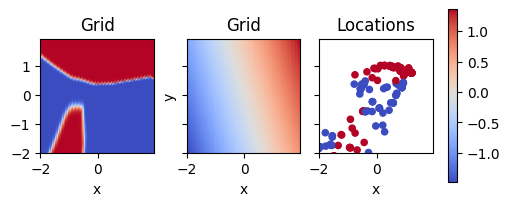

w: [-0.05675671 -0.09731987] b: 0.32086634635925293
w: [0.28705528 0.16759951] b: 0.43935200572013855
w: [-3.517689e-38  2.753286e-38] b: -3.6751151099216382e-25
w: [0.26833016 0.8695817 ] b: -0.17006652057170868
w: [0.32921198 0.7034074 ] b: 0.8179908990859985
w: [-0.5100799   0.01344403] b: -0.45187103748321533
w: [ 0.30268583 -0.3475469 ] b: 0.2012399584054947
w: [ 0.3847003  -0.32391596] b: 0.31051838397979736
w: [0.21955368 0.49436522] b: -0.05390522629022598
w: [ 0.41137043 -0.7578794 ] b: -0.3644755184650421
w: [-0.46542332  0.3169367 ] b: 0.5019134283065796
w: [0.30565444 0.8234434 ] b: -0.09488936513662338
w: [ 0.01420445 -0.57483184] b: -0.05321235954761505
w: [-0.40331227 -0.66314113] b: 0.030557511374354362
w: [0.40659076 0.64838773] b: 0.6058006286621094
w: [-0.70808417  0.40400055] b: -0.1288478523492813
w: [7.625341e-39 2.416909e-38] b: -1.027648099747841e-27
w: [-0.1392009  -0.75348705] b: 0.7631486058235168
w: [-0.12027257 -0.4844609 ] b: 0.12945641577243805
w: [-0.394

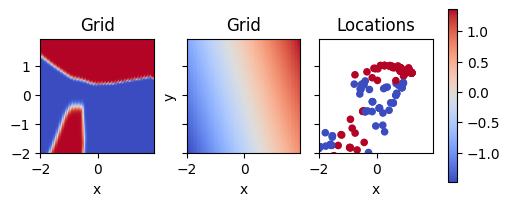

w: [-0.05641546 -0.09732227] b: 0.32088568806648254
w: [0.28761235 0.16768423] b: 0.4393525719642639
w: [-3.517689e-38  2.753286e-38] b: -2.1789652456798396e-26
w: [0.26888594 0.86998373] b: -0.17019452154636383
w: [0.3295926 0.7030734] b: 0.8181254267692566
w: [-0.5105493   0.01333263] b: -0.4524030387401581
w: [ 0.30318448 -0.34741077] b: 0.20169100165367126
w: [ 0.38528386 -0.3240043 ] b: 0.310695081949234
w: [0.22009046 0.49484324] b: -0.054002564400434494
w: [ 0.4114276  -0.75843173] b: -0.3629496097564697
w: [-0.46565706  0.3168546 ] b: 0.5018517374992371
w: [0.30620232 0.8238436 ] b: -0.09501367807388306
w: [ 0.0138433  -0.57483906] b: -0.05310610681772232
w: [-0.40371013 -0.6631602 ] b: 0.030583461746573448
w: [0.40699324 0.64805174] b: 0.6059268712997437
w: [-0.7085026   0.40390265] b: -0.1290881633758545
w: [7.625341e-39 2.416909e-38] b: -3.5795460335533766e-29
w: [-0.13899207 -0.75345457] b: 0.76310133934021
w: [-0.12062131 -0.48450646] b: 0.12951551377773285
w: [-0.3951844 

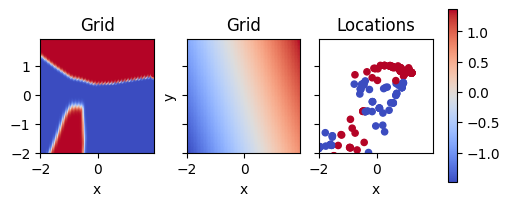

w: [-0.05610516 -0.09743614] b: 0.32095110416412354
w: [0.28807253 0.16767764] b: 0.4394518733024597
w: [-3.517689e-38  2.753286e-38] b: -1.0206562999742348e-27
w: [0.26930603 0.8705694 ] b: -0.17015224695205688
w: [0.3298341  0.70257723] b: 0.8183972835540771
w: [-0.5109928   0.01325463] b: -0.45294493436813354
w: [ 0.30365473 -0.3473022 ] b: 0.20216397941112518
w: [ 0.38583565 -0.32404134] b: 0.3109240233898163
w: [0.22050217 0.4954941 ] b: -0.05393918603658676
w: [ 0.4113915 -0.7591624] b: -0.3612552285194397
w: [-0.46581995  0.31683388] b: 0.5017085671424866
w: [0.3066149 0.8244297] b: -0.09496620297431946
w: [ 0.01356089 -0.5747873 ] b: -0.05311325937509537
w: [-0.40402085 -0.66311705] b: 0.03050224296748638
w: [0.40723443 0.6475531 ] b: 0.6062107682228088
w: [-0.7088609  0.4038257] b: -0.1293972283601761
w: [7.625341e-39 2.416909e-38] b: -8.24624051310881e-31
w: [-0.13879038 -0.7535492 ] b: 0.7630810737609863
w: [-0.12088814 -0.48449108] b: 0.12946252524852753
w: [-0.39548072 -0.

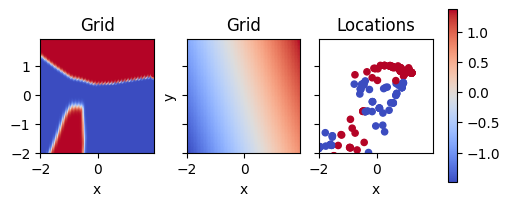

w: [-0.05580164 -0.09752523] b: 0.3210088610649109
w: [0.2885584  0.16768049] b: 0.4395040273666382
w: [-3.517689e-38  2.753286e-38] b: -3.5555188537909306e-29
w: [0.26971978 0.87106794] b: -0.17016880214214325
w: [0.3302029 0.7022389] b: 0.8185267448425293
w: [-0.5115835   0.01302931] b: -0.4533475339412689
w: [ 0.30415142 -0.34718397] b: 0.20274312794208527
w: [ 0.38644445 -0.32408905] b: 0.31124526262283325
w: [0.22089717 0.49606717] b: -0.05392897501587868
w: [ 0.41156498 -0.75956315] b: -0.35986411571502686
w: [-0.46594766  0.31687477] b: 0.5015570521354675
w: [0.307019  0.8249282] b: -0.09497854858636856
w: [ 0.01328501 -0.57470566] b: -0.053058624267578125
w: [-0.40432158 -0.66304314] b: 0.030465004965662956
w: [0.40762264 0.6472236 ] b: 0.6063275933265686
w: [-0.70937514  0.40359998] b: -0.12956583499908447
w: [7.625341e-39 2.416909e-38] b: -8.759080075085132e-33
w: [-0.13858277 -0.7536425 ] b: 0.7630531787872314
w: [-0.12115064 -0.48444653] b: 0.12946930527687073
w: [-0.395743

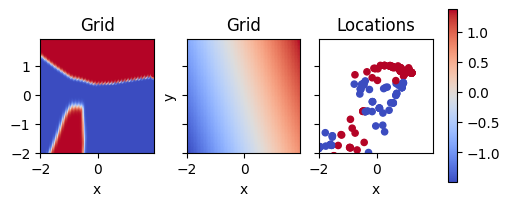

w: [-0.05547658 -0.09754631] b: 0.3210197687149048
w: [0.28907698 0.16774623] b: 0.43950504064559937
w: [-3.517689e-38  2.753286e-38] b: -8.1920455215585e-31
w: [0.2702708 0.8715167] b: -0.17025627195835114
w: [0.33055508 0.7019124 ] b: 0.8186550140380859
w: [-0.51195973  0.01300883] b: -0.45394259691238403
w: [ 0.30457202 -0.34711975] b: 0.20319952070713043
w: [ 0.38694006 -0.3242398 ] b: 0.31151244044303894
w: [0.22142832 0.49659112] b: -0.05398637056350708
w: [ 0.41151434 -0.7602041 ] b: -0.35825902223587036
w: [-0.4661814  0.3167799] b: 0.5015047192573547
w: [0.3075637  0.82537735] b: -0.09506122767925262
w: [ 0.01290223 -0.57472986] b: -0.05295754596590996
w: [-0.404718  -0.6630675] b: 0.030487436801195145
w: [0.40799063 0.6468967 ] b: 0.6064497232437134
w: [-0.709699   0.4035847] b: -0.12985028326511383
w: [1.0058746e-31 3.8390562e-33] b: -4.873930186295373e-32
w: [-0.13837364 -0.7536314 ] b: 0.7629959583282471
w: [-0.12151627 -0.48450607] b: 0.12952472269535065
w: [-0.39611918 -

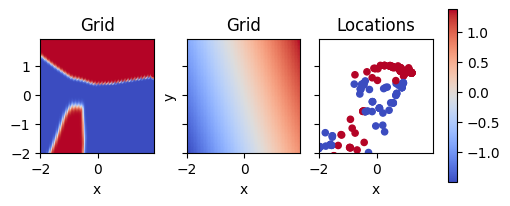

w: [-0.05522845 -0.09768246] b: 0.3211231231689453
w: [0.28948215 0.16771182] b: 0.4396110773086548
w: [-3.517689e-38  2.753286e-38] b: -8.70454448404667e-33
w: [0.27067566 0.8720626 ] b: -0.17026539146900177
w: [0.33083355 0.70150536] b: 0.8188519477844238
w: [-0.5124578   0.01287322] b: -0.454446405172348
w: [ 0.3049836  -0.34707117] b: 0.20383916795253754
w: [ 0.38750434 -0.3243572 ] b: 0.3118686079978943
w: [0.22181994 0.4972055 ] b: -0.05397094041109085
w: [ 0.411591  -0.7607804] b: -0.35670995712280273
w: [-0.466242   0.3168411] b: 0.5013023018836975
w: [0.30796003 0.8259241 ] b: -0.09506556391716003
w: [ 0.01265672 -0.57464737] b: -0.05295281112194061
w: [-0.40496626 -0.662979  ] b: 0.030397308990359306
w: [0.40828046 0.64649636] b: 0.6066389083862305
w: [-0.71014154  0.40342048] b: -0.130059152841568
w: [ 2.3477955e-28 -1.3313662e-28] b: -3.2358602238588286e-29
w: [-0.13821155 -0.7537515 ] b: 0.7630156874656677
w: [-0.12174308 -0.48445725] b: 0.1294817328453064
w: [-0.39633256 

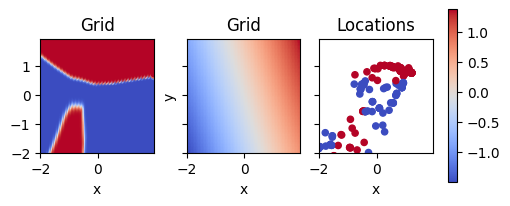

w: [-0.0548244  -0.09762596] b: 0.321101576089859
w: [0.29004556 0.16784966] b: 0.4395748972892761
w: [3.1059645e-31 3.8156415e-31] b: -4.030693956935691e-31
w: [0.2711102 0.8724923] b: -0.17038002610206604
w: [0.3311905 0.701187 ] b: 0.8189738988876343
w: [-0.51296544  0.01272951] b: -0.4549424350261688
w: [ 0.30559173 -0.3468176 ] b: 0.20413033664226532
w: [ 0.38812488 -0.32429975] b: 0.3120640814304352
w: [0.22223686 0.49771136] b: -0.05405404418706894
w: [ 0.4116198 -0.7614499] b: -0.35504892468452454
w: [-0.46654096  0.3166354 ] b: 0.5013125538825989
w: [0.30838555 0.82635397] b: -0.09517621994018555
w: [ 0.01230544 -0.574681  ] b: -0.05283912643790245
w: [-0.4053651 -0.6630425] b: 0.030450992286205292
w: [0.40863806 0.64617044] b: 0.6067583560943604
w: [-0.71058095  0.4032813 ] b: -0.1302582025527954
w: [ 6.369826e-19 -2.751393e-19] b: -9.456409542062907e-20
w: [-0.13790831 -0.75366884] b: 0.7629266977310181
w: [-0.12208545 -0.48453373] b: 0.12955501675605774
w: [-0.39671826 -0.6

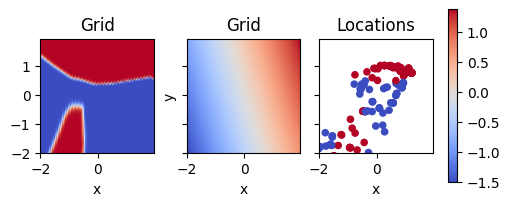

w: [-0.05455405 -0.09770636] b: 0.32116448879241943
w: [0.29048958 0.16784875] b: 0.43963950872421265
w: [ 6.8600550e-33 -6.1968095e-33] b: -3.9150388897745295e-32
w: [0.27162045 0.8729396 ] b: -0.17042453587055206
w: [0.33147764 0.7008051 ] b: 0.8191531300544739
w: [-0.51342624  0.01262631] b: -0.45549067854881287
w: [ 0.3060594  -0.34671712] b: 0.20464232563972473
w: [ 0.3887039  -0.32438162] b: 0.31231260299682617
w: [0.22272605 0.49823338] b: -0.05407106131315231
w: [ 0.41165298 -0.7620294 ] b: -0.3534645736217499
w: [-0.4666855   0.31663373] b: 0.501183807849884
w: [0.30888724 0.8268019 ] b: -0.09521636366844177
w: [ 0.01201859 -0.5746185 ] b: -0.05280547961592674
w: [-0.40566805 -0.66298515] b: 0.030405282974243164
w: [0.40893617 0.64578766] b: 0.6069347262382507
w: [-0.7109983  0.4031661] b: -0.13050732016563416
w: [3.6934036e-19 1.8516351e-19] b: -6.277342560537837e-18
w: [-0.13774464 -0.7537201 ] b: 0.7629145979881287
w: [-0.12235559 -0.48450688] b: 0.12954382598400116
w: [-0.

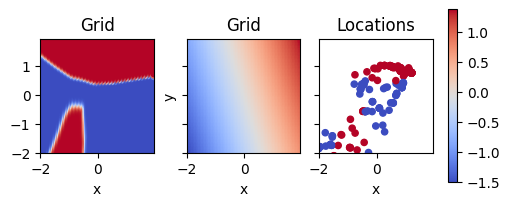

w: [-0.05425505 -0.09780747] b: 0.32122790813446045
w: [0.29094464 0.16783087] b: 0.43970203399658203
w: [1.5816594e-34 5.9192018e-34] b: -1.0924458586076852e-33
w: [0.27208063 0.8733959 ] b: -0.17048178613185883
w: [0.3317922  0.70043534] b: 0.8193164467811584
w: [-0.5138353   0.01257861] b: -0.4560774266719818
w: [ 0.30648568 -0.3466711 ] b: 0.20516708493232727
w: [ 0.38924223 -0.3245242 ] b: 0.3125765025615692
w: [0.22316988 0.49876136] b: -0.05410194396972656
w: [ 0.41165462 -0.7626123 ] b: -0.3518919348716736
w: [-0.46684328  0.31664294] b: 0.5010530352592468
w: [0.3093395 0.8272581] b: -0.09526953846216202
w: [ 0.01170248 -0.57456243] b: -0.052765678614377975
w: [-0.40599066 -0.66292495] b: 0.030362797901034355
w: [0.40925834 0.645416  ] b: 0.6070935130119324
w: [-0.7113653   0.40309766] b: -0.13076861202716827
w: [3.141461e-14 3.058474e-14] b: -4.087785662130463e-15
w: [-0.13753875 -0.7537802 ] b: 0.7629031538963318
w: [-0.12265395 -0.48448548] b: 0.12953919172286987
w: [-0.3972

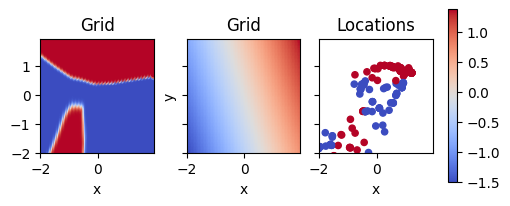

w: [-0.05388875 -0.09792003] b: 0.32125526666641235
w: [0.29141116 0.16780102] b: 0.4397639036178589
w: [-2.4102940e-36  2.3355212e-36] b: -3.2091208147033314e-35
w: [0.2724065 0.8739629] b: -0.1704331487417221
w: [0.33206636 0.70001066] b: 0.819520115852356
w: [-0.51435304  0.01241885] b: -0.45654675364494324
w: [ 0.30708337 -0.34645647] b: 0.2055014818906784
w: [ 0.38989252 -0.32441324] b: 0.3127277195453644
w: [0.22348663 0.4993932 ] b: -0.05403323099017143
w: [ 0.4117302  -0.76312506] b: -0.3503647446632385
w: [-0.46703953  0.31663784] b: 0.500953197479248
w: [0.30965585 0.82782596] b: -0.09521617740392685
w: [ 0.01144175 -0.57445115] b: -0.05276405066251755
w: [-0.40629396 -0.6628401 ] b: 0.03030841052532196
w: [0.40951973 0.6449855 ] b: 0.607307493686676
w: [-0.7117945  0.4029212] b: -0.13100308179855347
w: [-1.2423029e-09 -2.4467495e-10] b: -2.610226479404787e-09
w: [-0.1372631  -0.75387394] b: 0.7628505229949951
w: [-0.12290186 -0.48441422] b: 0.1295005977153778
w: [-0.3975923 

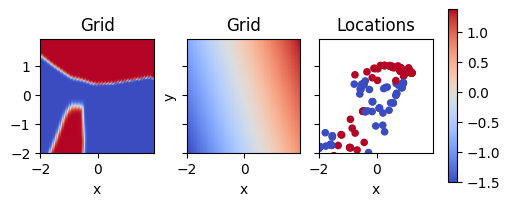

w: [-0.05362876 -0.0979717 ] b: 0.32131877541542053
w: [0.29187298 0.16782966] b: 0.4397984743118286
w: [-3.9915685e-36  1.4075153e-36] b: -1.4778853938105876e-35
w: [0.27297214 0.8743689 ] b: -0.17054259777069092
w: [0.33242717 0.6997113 ] b: 0.8196240067481995
w: [-0.51479864  0.01232951] b: -0.4570966958999634
w: [ 0.30745745 -0.34644365] b: 0.20612794160842896
w: [ 0.39041087 -0.32463923] b: 0.3131038546562195
w: [0.22402541 0.49987888] b: -0.0541095957159996
w: [ 0.41173306 -0.76372916] b: -0.34874528646469116
w: [-0.4671756   0.31663558] b: 0.500822901725769
w: [0.3102144  0.82823336] b: -0.09532106667757034
w: [ 0.01109282 -0.57443815] b: -0.05267570912837982
w: [-0.40663347 -0.6628149 ] b: 0.030298352241516113
w: [0.4099049 0.644691 ] b: 0.6073942184448242
w: [-0.7121941   0.40282935] b: -0.13121220469474792
w: [3.3822156e-10 4.1572360e-11] b: -5.339624575828594e-11
w: [-0.1370967 -0.7538897] b: 0.7628387212753296
w: [-0.12323056 -0.48443523] b: 0.12954135239124298
w: [-0.39789

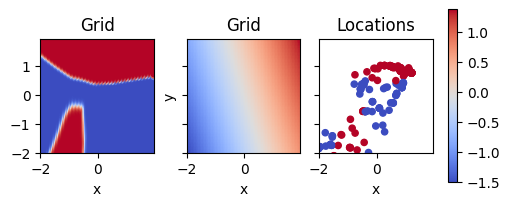

w: [-0.05330419 -0.09805518] b: 0.32132020592689514
w: [0.2923439  0.16783713] b: 0.4398250877857208
w: [-1.1173321e-38 -1.7608618e-38] b: -1.4756731089940582e-37
w: [0.27346563 0.87490624] b: -0.1704893857240677
w: [0.33273542 0.69934136] b: 0.8197757005691528
w: [-0.51531875  0.01217476] b: -0.45759379863739014
w: [ 0.30803996 -0.34624523] b: 0.20649835467338562
w: [ 0.39106753 -0.32458794] b: 0.31329694390296936
w: [0.22450393 0.50048447] b: -0.05403454601764679
w: [ 0.41181853 -0.7642638 ] b: -0.3471840023994446
w: [-0.46734968  0.31661034] b: 0.500742495059967
w: [0.31070155 0.828773  ] b: -0.09526196122169495
w: [ 0.01081147 -0.57436395] b: -0.05263438820838928
w: [-0.40694904 -0.6627623 ] b: 0.030274951830506325
w: [0.4102176 0.6443183] b: 0.6075509786605835
w: [-0.7126584   0.40265307] b: -0.13140885531902313
w: [6.0776212e-05 1.0278469e-04] b: -0.00016787124332040548
w: [-0.13688684 -0.7539427 ] b: 0.762760579586029
w: [-0.12349904 -0.48440152] b: 0.12954173982143402
w: [-0.39

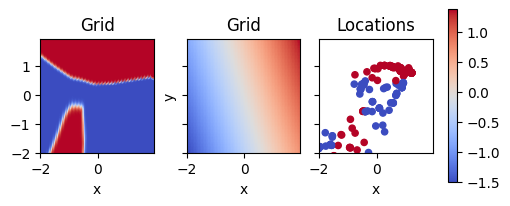

w: [-0.05300022 -0.0980803 ] b: 0.3213592767715454
w: [0.2928127  0.16787794] b: 0.4398564398288727
w: [8.900793e-37 7.319833e-37] b: -6.149205274496186e-37
w: [0.27400395 0.8752946 ] b: -0.17058221995830536
w: [0.3330488  0.69899446] b: 0.8199217915534973
w: [-0.51579595  0.01206573] b: -0.45810696482658386
w: [ 0.3085397 -0.3461176] b: 0.2069544494152069
w: [ 0.39165065 -0.32465693] b: 0.31356504559516907
w: [0.22501884 0.5009503 ] b: -0.05409735441207886
w: [ 0.4118179  -0.76493645] b: -0.3455062210559845
w: [-0.46753097  0.31652647] b: 0.5006541609764099
w: [0.31123212 0.829162  ] b: -0.09535104036331177
w: [ 0.01049223 -0.57433766] b: -0.05257483199238777
w: [-0.40728357 -0.6627451 ] b: 0.03026018850505352
w: [0.41054052 0.64396644] b: 0.6076908707618713
w: [-0.7130827   0.40254715] b: -0.1315985769033432
w: [1.1048896e-05 2.3713174e-06] b: -2.1914684111834504e-06
w: [-0.13669257 -0.75392544] b: 0.7627335786819458
w: [-0.12380226 -0.48441285] b: 0.1295587718486786
w: [-0.39850807 

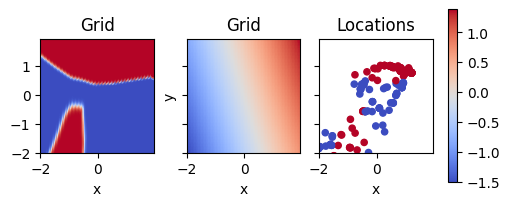

w: [-0.05268338 -0.09820018] b: 0.32140979170799255
w: [0.29326433 0.16784686] b: 0.43990060687065125
w: [-4.3217004e-37  9.1627494e-37] b: -1.5248161304600946e-36
w: [0.27431366 0.87581056] b: -0.17057879269123077
w: [0.33340716 0.6986867 ] b: 0.8200201988220215
w: [-0.51632303  0.01190117] b: -0.458563894033432
w: [ 0.30901992 -0.34603828] b: 0.20749793946743011
w: [ 0.39227027 -0.3247715 ] b: 0.31381261348724365
w: [0.22531267 0.5015389 ] b: -0.05406830459833145
w: [ 0.41195843 -0.76532996] b: -0.3441074788570404
w: [-0.46766067  0.31658223] b: 0.5005142688751221
w: [0.3115305 0.8296808] b: -0.0953429788351059
w: [ 0.01021135 -0.5742428 ] b: -0.05252593010663986
w: [-0.4075703  -0.66264856] b: 0.030223406851291656
w: [0.41090265 0.6436661 ] b: 0.6077792048454285
w: [-0.713551    0.40233818] b: -0.1317584365606308
w: [-1.147676e-05  2.236119e-05] b: -4.3674946937244385e-05
w: [-0.13643585 -0.7540263 ] b: 0.7626978158950806
w: [-0.1240661  -0.48435378] b: 0.12956376373767853
w: [-0.39

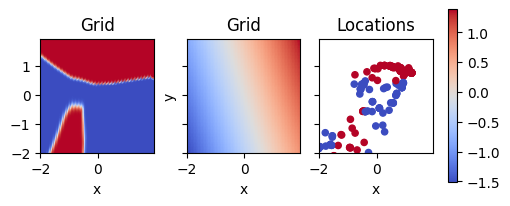

w: [-0.05238177 -0.09826247] b: 0.3214501738548279
w: [0.29369873 0.16785295] b: 0.43995052576065063
w: [-1.5830818e-35 -2.6127190e-35] b: -1.3315372080909893e-34
w: [0.2747411 0.8763247] b: -0.17056682705879211
w: [0.33370072 0.6983262 ] b: 0.8201718330383301
w: [-0.51683533  0.01174773] b: -0.4590311646461487
w: [ 0.30954    -0.34588313] b: 0.20795387029647827
w: [ 0.3928755 -0.3247596] b: 0.31413912773132324
w: [0.22572091 0.50212646] b: -0.054029807448387146
w: [ 0.41201898 -0.7659265 ] b: -0.34252262115478516
w: [-0.46780068  0.31654456] b: 0.5004008412361145
w: [0.31194893 0.83019906] b: -0.09532492607831955
w: [ 0.00993886 -0.5741745 ] b: -0.05249660834670067
w: [-0.407858  -0.6625944] b: 0.030179716646671295
w: [0.41119847 0.6433072 ] b: 0.6079288721084595
w: [-0.7140112  0.4021481] b: -0.13191302120685577
w: [-4.1321495e-05  3.2994163e-04] b: -0.0013941182987764478
w: [-0.13622262 -0.75407827] b: 0.7626596689224243
w: [-0.1243211 -0.4843228] b: 0.1295507252216339
w: [-0.399028

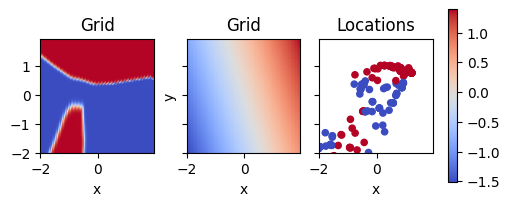

w: [-0.05194957 -0.09822394] b: 0.3213473856449127
w: [0.29427567 0.16798437] b: 0.43985188007354736
w: [ 7.105662e-36 -8.009786e-38] b: -6.984609644805189e-36
w: [0.27516901 0.8768312 ] b: -0.1705373078584671
w: [0.33413666 0.69811213] b: 0.820176899433136
w: [-0.51721334  0.01173064] b: -0.45963209867477417
w: [ 0.31003797 -0.34574598] b: 0.20828136801719666
w: [ 0.39340416 -0.3248868 ] b: 0.31439799070358276
w: [0.22613245 0.50270426] b: -0.053976502269506454
w: [ 0.41196868 -0.7665782 ] b: -0.34088563919067383
w: [-0.46810418  0.31639218] b: 0.5004396438598633
w: [0.31236827 0.8307081 ] b: -0.09529075771570206
w: [ 0.00949733 -0.5742564 ] b: -0.05232004448771477
w: [-0.40830877 -0.66268146] b: 0.030285904183983803
w: [0.41163883 0.64309484] b: 0.6079305410385132
w: [-0.7143471   0.40209326] b: -0.1321820318698883
w: [-2.3962253e-05 -3.5272467e-05] b: 6.543560630234424e-06
w: [-0.13587812 -0.75400233] b: 0.7624759078025818
w: [-0.12474563 -0.48444197] b: 0.1296863853931427
w: [-0.39

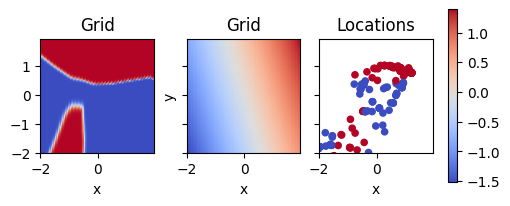

w: [-0.05179264 -0.09840018] b: 0.3214954733848572
w: [0.29457945 0.16785547] b: 0.4400068521499634
w: [-9.7610130e-32 -1.6488717e-31] b: -7.7105160156876575e-31
w: [0.27577946 0.87721646] b: -0.17063899338245392
w: [0.33430788 0.697663  ] b: 0.8204289674758911
w: [-0.5176793   0.01163051] b: -0.46015074849128723
w: [ 0.31051293 -0.3456711 ] b: 0.20877204835414886
w: [ 0.39403698 -0.3249123 ] b: 0.31459400057792664
w: [0.22671783 0.50316584] b: -0.054048169404268265
w: [ 0.4120292 -0.7670848] b: -0.3393845558166504
w: [-0.46813118  0.31650046] b: 0.5002246499061584
w: [0.3129725 0.8310958] b: -0.0953880324959755
w: [ 0.00931838 -0.57407135] b: -0.05239491164684296
w: [-0.40849417 -0.66250056] b: 0.030143331736326218
w: [0.41181457 0.6426351 ] b: 0.6081816554069519
w: [-0.71478796  0.40197524] b: -0.13231028616428375
w: [0.00470459 0.00304732] b: -4.2707437387434766e-05
w: [-0.13583678 -0.7541277 ] b: 0.7625657916069031
w: [-0.12490598 -0.48429257] b: 0.12957118451595306
w: [-0.3996327 

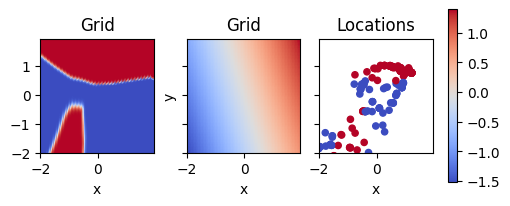

KeyboardInterrupt: 

In [23]:
ds = XYDataset(df_po_xy[['x', 'y']].values, df_po_xy[['label']].values)
loader = DataLoader(ds, batch_size=50, shuffle=True, drop_last=False)
n_input = 100
model = MLP(2, 1, (n_input,n_input))

model.to('cpu')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
model.train()



for e in range(10000): # epochs
    # print('Epoch: ',e)
    running_loss = 0.0 

    linear_layers = [m for m in model.net if isinstance(m, nn.Linear)]
    # e.g., first hidden linear:
    L0 = linear_layers[0]
    # output linear:
    Lout = linear_layers[-1]

    # neuron_idx = 3  # pick a neuron




    if e % 20 == 0:

        for ne in range(n_input):
            w = L0.weight[ne].detach().cpu()   # shape: [in_features_of_L0]
            b = L0.bias[ne].item()
            print("w:", w.numpy(), "b:", b)

        xy_grid_neuron = df_xy_grid[['x', 'y']].values @ w.numpy() + b


            # --- nicer "grid" plot of the decision surface (squares) ---
        with torch.no_grad():
            grid_logits = model(xy_grid)
            grid_prob = torch.sigmoid(grid_logits).cpu().numpy()

        df_xy_grid['prob'] = grid_prob  # store probability, not raw logits


        xmin, xmax = float(xy_range.min()), float(xy_range.max())
        ymin, ymax = xmin, xmax  # symmetric grid

        Z = grid_prob.reshape(len(xy_range), len(xy_range))
        Z_neuron = xy_grid_neuron.reshape(len(xy_range), len(xy_range))


        ### PLOT
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(5, 2), sharey=True, constrained_layout=True)

        # Shared color normalization
        vmin, vmax = 0, 1
        cmap = 'coolwarm'

#         #
#         dx = float(xy_range[1] - xy_range[0])
#         extent = [
#             xmin - dx / 2,
#             xmax + dx / 2,
#             ymin - dx / 2,
#             ymax + dx / 2
# ]

        ax1.scatter( 
            df_xy_grid['x'],
            df_xy_grid['y'],
            c = df_xy_grid['prob'],
            cmap=cmap,  
            vmin=vmin,
            vmax=vmax,
            s=20
        )
        ax1.set_title("Grid")
        ax1.set_xlabel("x")
        ax1.set_xlim(xmin, xmax)
        ax1.set_ylim(ymin, ymax)
        ax1.set_aspect('equal', adjustable='box')

        # im = ax1.imshow(
        #     Z,
        #     extent = extent,
        #     origin='lower',
        #     # extent=[xmin, xmax, ymin, ymax],
        #     cmap=cmap,
        #     vmin=vmin,
        #     vmax=vmax,
        #     aspect='equal',
        #     interpolation='nearest'
        # )
        # ax1.set_title("Grid")
        # ax1.set_xlabel("x")
        # ax1.set_ylabel("y")
        # ax1.set_xlim(xmin, xmax)
        # ax1.set_ylim(ymin, ymax)

        #
        # ax2.scatter([],[])
        im = ax2.imshow(
            Z_neuron,
            origin='lower',
            extent=[xmin, xmax, ymin, ymax],
            cmap=cmap,
            aspect='equal',
            interpolation='nearest'
        )
        ax2.set_title("Grid")
        ax2.set_xlabel("x")
        ax2.set_ylabel("y")
        # ax2.set_xlim(0, 0)
        # ax2.set_ylim(0, 0)

        # 
        ax3.scatter(
            df_po_xy['x'],
            df_po_xy['y'],
            c=df_po_xy['label'],   
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            s=20
        )
        ax3.set_title("Locations")
        ax3.set_xlabel("x")
        ax3.set_xlim(xmin, xmax)
        ax3.set_ylim(ymin, ymax)
        ax3.set_aspect('equal', adjustable='box')

        # Shared colorbar (matches both)
        cbar = fig.colorbar(im, ax=[ax1, ax2, ax3], fraction=0.046, pad=0.04)
        # cbar.set_label('P(y=1) / Label')

        plt.show()




    for xb, yb in loader:
        # set to cpu (?)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = nn.BCEWithLogitsLoss()(outputs, yb)
        # p_outputs = 1 / (1 + torch.exp(-outputs))
        # #exp_outputs = torch.exp(outputs)
        # #norm_outputs = exp_outputs / torch.sum(exp_outputs, axis = 1)
        # loss = torch.mean(-(yb * torch.log(p_outputs) + (1-yb) * torch.log(1-p_outputs)))
        loss.backward()
        optimizer.step()
        running_loss += loss
    
    # print(loss)






        
